In [674]:
from src.config import *

In [16]:
dfCreditData = pd.read_csv('synthetic_credit_panel.csv')

In [17]:
dfCreditData 

,firm_id,year,total_assets,debt_assets,roa,current_ratio,interest_coverage,revenue_growth,volatility,pd,default,lgd,ead
0,0,2023,5.372018e+06,0.170712,0.106484,1.536870,8.346899,0.098576,0.293682,0.002000,0,0.694730,1.117247e+06
1,1,2023,2.846884e+06,0.243033,0.031237,2.001361,28.622757,-0.171364,0.353789,0.002000,0,0.406691,9.565980e+05
2,2,2023,6.247479e+06,0.168680,0.116517,1.593253,2.039239,0.171956,0.147770,0.002000,0,0.856574,1.085660e+06
3,3,2023,1.499204e+07,0.119787,0.015174,1.613292,0.685379,0.174044,0.204635,0.027965,0,0.565919,2.890181e+06
4,4,2023,2.586579e+06,0.428164,0.107201,1.147336,2.984707,0.159817,0.257479,0.028811,0,0.724388,1.400520e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6995,3496,2024,2.049996e+06,0.531805,-0.002318,1.936896,1.692935,0.001751,0.286422,0.102831,1,0.579847,9.394455e+05
6996,3497,2024,3.812767e+06,0.279163,-0.008120,0.643033,2.226844,0.107820,0.292180,0.132484,1,0.609401,4.967475e+05
6997,3498,2024,2.024346e+06,0.301017,0.093835,1.249438,1.833409,0.174797,0.077611,0.002800,0,0.577279,7.034063e+05
6998,3499,2024,2.502618e+06,0.215155,0.074684,1.810960,1.827601,-0.042411,0.078914,0.002800,0,0.403698,4.097357e+05


In [22]:
print(dfCreditData.columns.tolist())

['firm_id', 'year', 'total_assets', 'debt_assets', 'roa', 'current_ratio', 'interest_coverage', 'revenue_growth', 'volatility', 'pd', 'default', 'lgd', 'ead']


In [24]:
dfCreditData.isnull().sum()

firm_id              0
year                 0
total_assets         0
debt_assets          0
roa                  0
current_ratio        0
interest_coverage    0
revenue_growth       0
volatility           0
pd                   0
default              0
lgd                  0
ead                  0
dtype: int64

In [32]:
dfCreditData.describe().T

,count,mean,std,min,25%,50%,75%,max
firm_id,7000.0,1.750000e+03,1.010435e+03,0.000000,8.750000e+02,1.750000e+03,2.625000e+03,3.500000e+03
year,7000.0,2.023500e+03,5.000357e-01,2023.000000,2.023000e+03,2.023500e+03,2.024000e+03,2.024000e+03
total_assets,7000.0,5.432598e+06,7.147033e+06,122008.167567,1.676476e+06,3.268843e+06,6.403986e+06,1.657909e+08
debt_assets,7000.0,2.860314e-01,1.573453e-01,0.050000,1.615368e-01,2.657976e-01,3.877684e-01,8.959512e-01
roa,7000.0,5.068163e-02,4.000345e-02,-0.104255,2.347010e-02,5.114683e-02,7.780387e-02,2.076932e-01
current_ratio,7000.0,1.496765e+00,4.924083e-01,0.200000,1.151949e+00,1.498806e+00,1.835588e+00,3.305675e+00
interest_coverage,7000.0,3.725201e+00,3.531405e+00,0.128268,1.598014e+00,2.722071e+00,4.546566e+00,5.000000e+01
revenue_growth,7000.0,3.894926e-02,1.003682e-01,-0.406297,-2.940023e-02,3.915145e-02,1.080421e-01,4.091625e-01
volatility,7000.0,2.508394e-01,1.001358e-01,0.050000,1.802696e-01,2.501477e-01,3.198993e-01,6.227833e-01
pd,7000.0,3.540437e-02,3.744576e-02,0.002000,2.800000e-03,2.421179e-02,5.766863e-02,2.363941e-01


In [28]:
dfCreditData.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   firm_id            7000 non-null   int64  
 1   year               7000 non-null   int64  
 2   total_assets       7000 non-null   float64
 3   debt_assets        7000 non-null   float64
 4   roa                7000 non-null   float64
 5   current_ratio      7000 non-null   float64
 6   interest_coverage  7000 non-null   float64
 7   revenue_growth     7000 non-null   float64
 8   volatility         7000 non-null   float64
 9   pd                 7000 non-null   float64
 10  default            7000 non-null   int64  
 11  lgd                7000 non-null   float64
 12  ead                7000 non-null   float64
dtypes: float64(10), int64(3)
memory usage: 711.1 KB


In [38]:
dfCreditData['default'].value_counts()

default
0    6757
1     243
Name: count, dtype: int64

In [743]:
df_2023 = dfCreditData[dfCreditData['year'] == 2023].copy()

In [699]:
df_2024 = dfCreditData[dfCreditData['year'] == 2024].copy()

In [90]:
print(f"2023: {len(df_2023)} , {df_2023['default'].mean():.3%}")

2023: 3500 , 3.086%


In [92]:
print(f"2024: {len(df_2024)} , {df_2024['default'].mean():.3%}")

2024: 3500 , 3.857%


In [102]:
features = ['total_assets', 'debt_assets', 'roa', 'current_ratio', 
            'interest_coverage', 'revenue_growth', 'volatility']

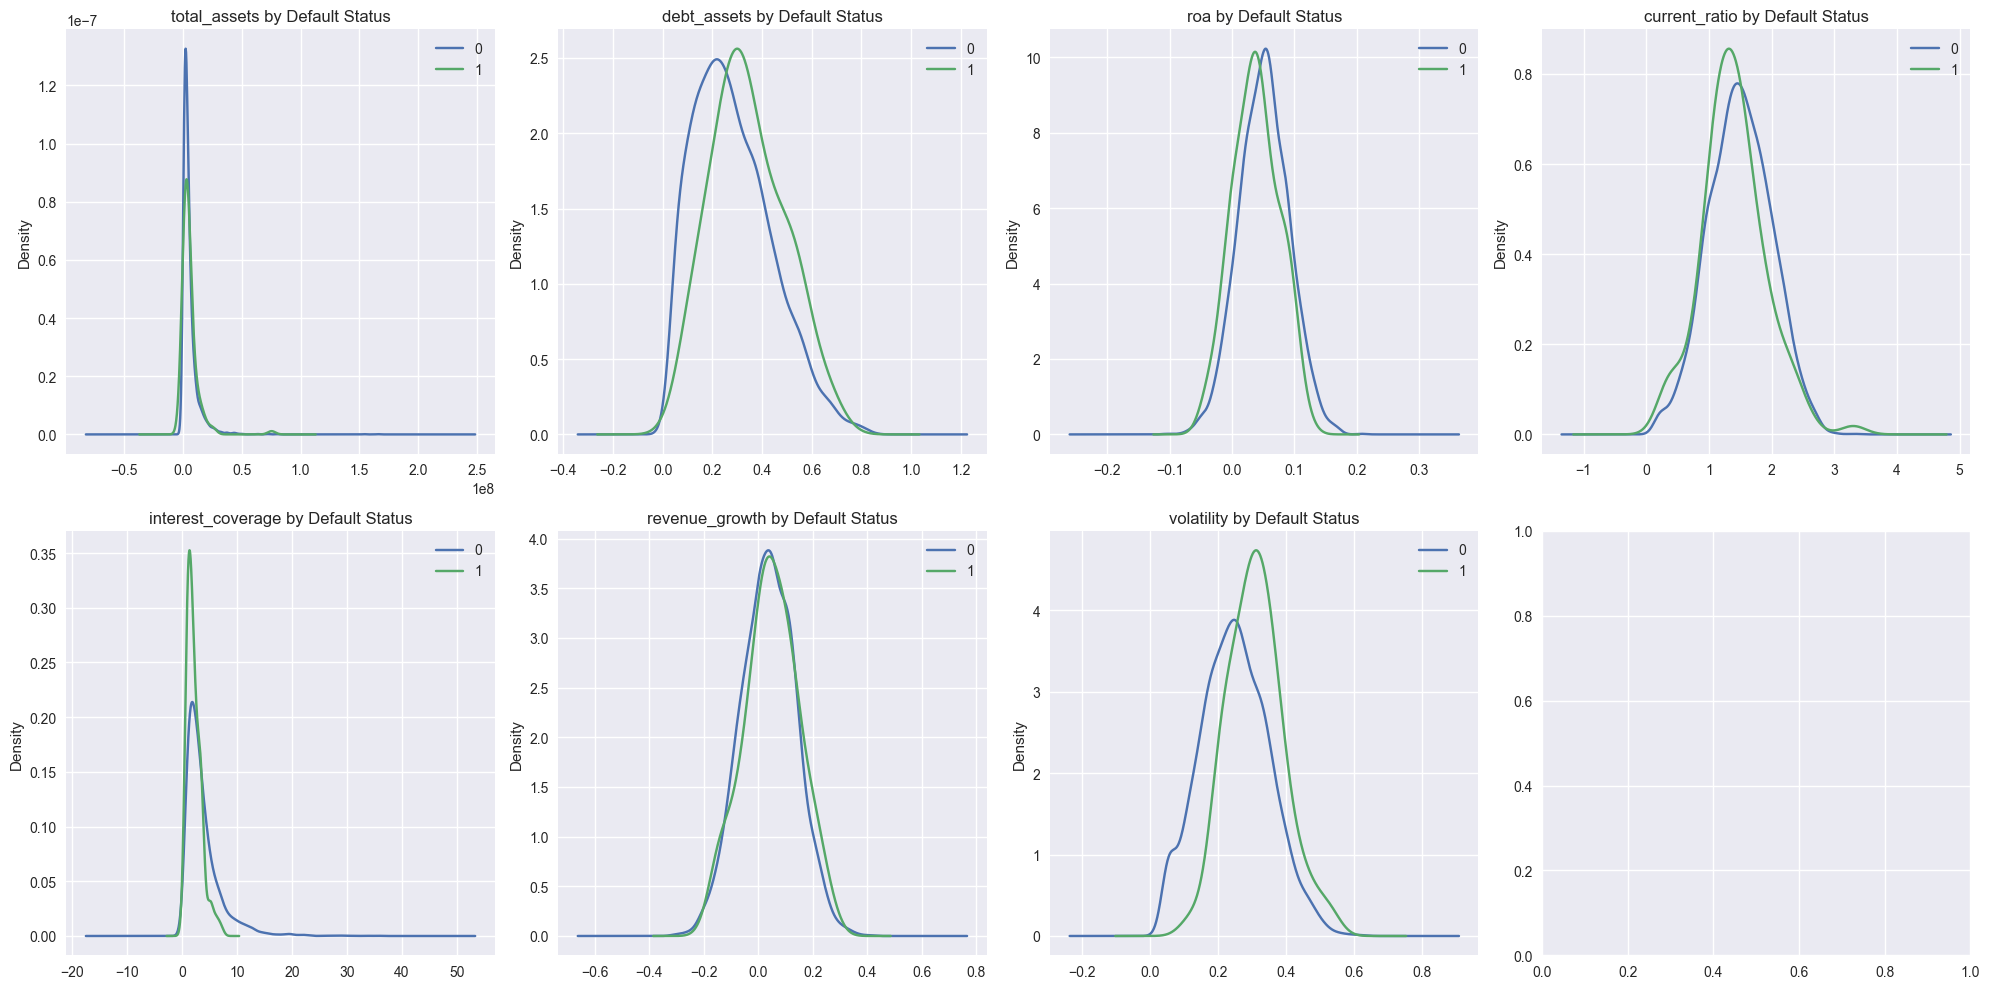

In [106]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, feature in enumerate(features):
    row, col = i // 4, i % 4
    df_2023.groupby('default')[feature].plot(kind='kde', ax=axes[row, col], legend=True)
    axes[row, col].set_title(f'{feature} by Default Status')
plt.tight_layout()
plt.show()

In [747]:
features_original_2023 = ['total_assets', 'debt_assets', 'roa', 'current_ratio', 
            'interest_coverage', 'revenue_growth', 'volatility']

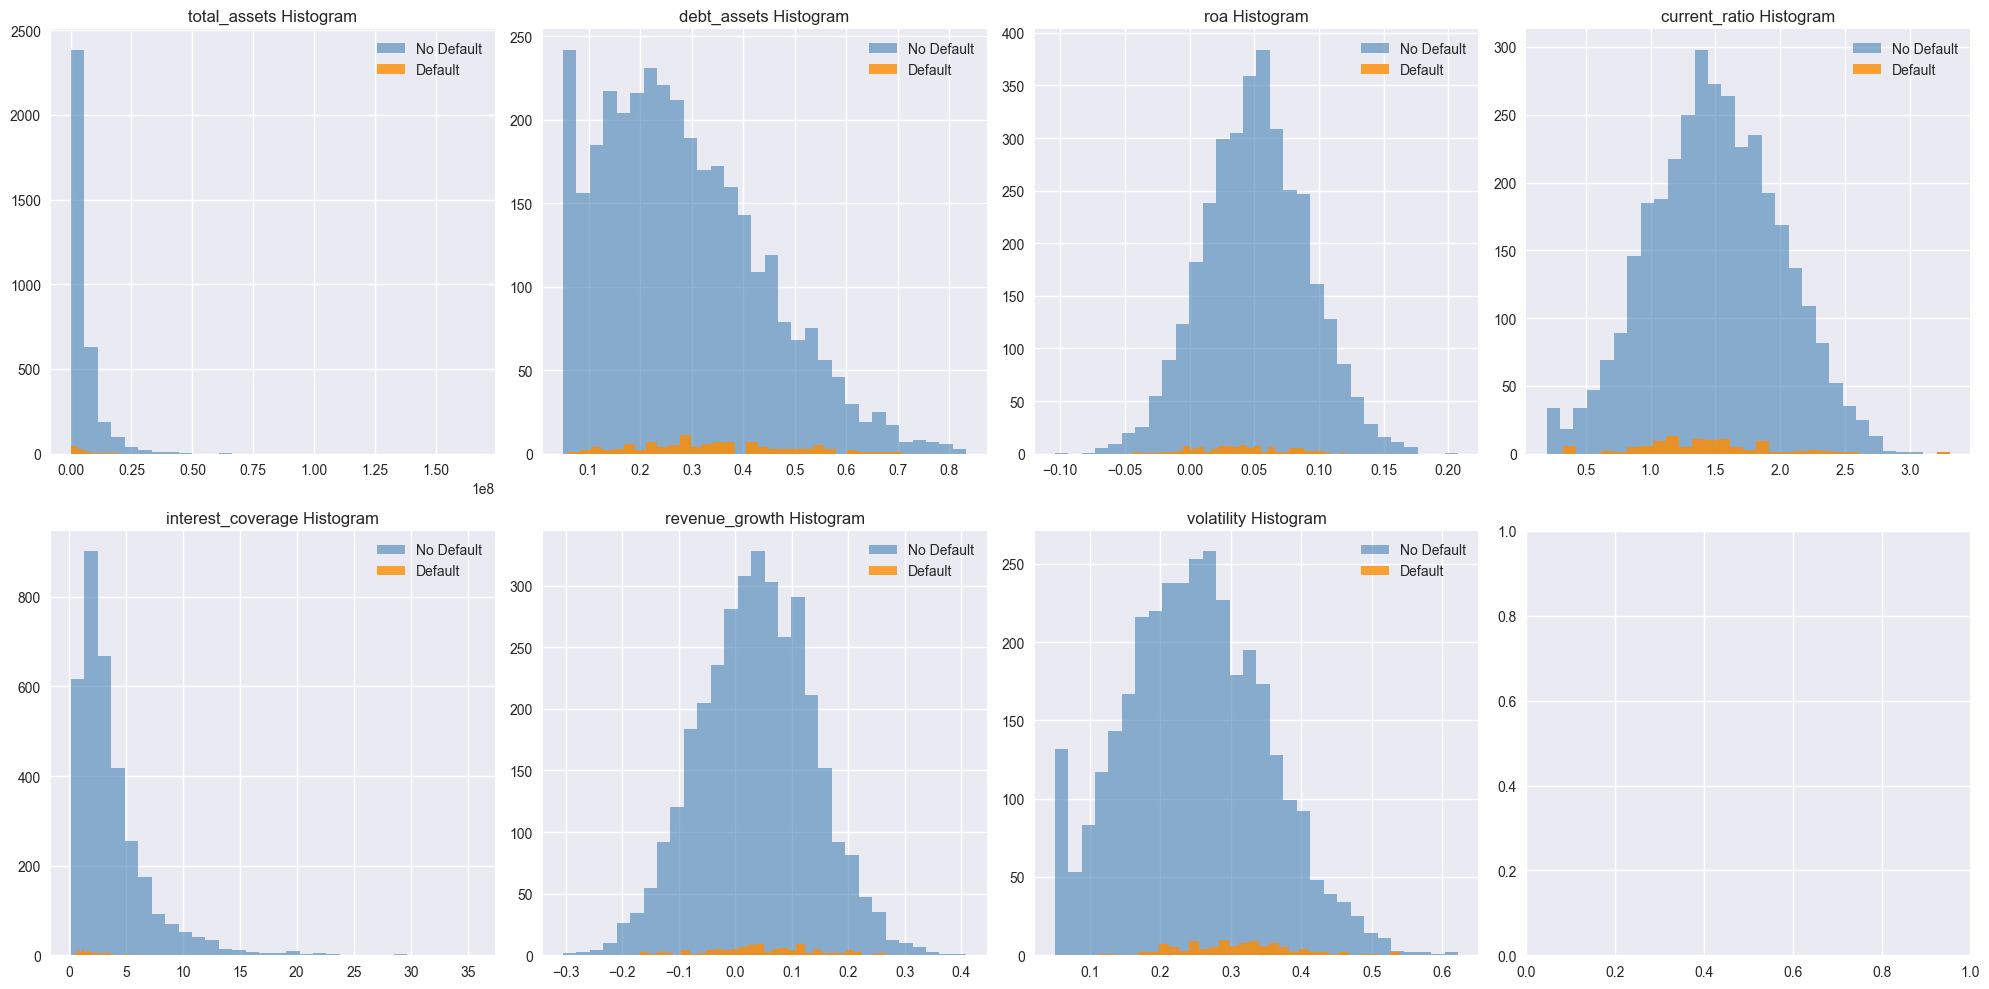

In [749]:
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
for i, feature_2023 in enumerate(features_original_2023):
    if feature not in df_2023.columns:
        continue

    row, col = divmod(i, 4)
    ax = axes[row, col]

    df_2023[df_2023['default'] == 0][feature_2023].hist(
        ax=ax, alpha=0.6, bins=30, label='No Default', color='steelblue'
    )
    df_2023[df_2023['default'] == 1][feature_2023].hist(
        ax=ax, alpha=0.8, bins=30, label='Default',color='darkorange'
    )

    ax.set_title(f'{feature_2023} Histogram')
    ax.legend()

plt.tight_layout()
plt.show()

In [157]:
#for feature in features:
#    if feature not in df_2023.columns:
#        continue

#    g = sns.FacetGrid(df_2023, col="default", height=4, aspect=1.2)
#    g.map(sns.histplot, feature, kde=True)
 #   g.fig.suptitle(f"{feature} Distribution by Default", y=1.05)
  #  plt.show()

In [127]:
comparison_results = []

for feature in features:
    default_0 = df_2023[df_2023['default'] == 0][feature].dropna()
    default_1 = df_2023[df_2023['default'] == 1][feature].dropna()
    
  
    t_stat, p_value = stats.ttest_ind(default_0, default_1, equal_var=False)

    d0_mean = default_0.mean()
    d1_mean = default_1.mean()
    difference = d0_mean - d1_mean

    pooled_std = np.sqrt((default_0.std()**2 + default_1.std()**2) / 2)
    cohens_d = difference / pooled_std if pooled_std != 0 else 0

    if p_value < 0.001:
        significant = '***'
    elif p_value < 0.01:
        significant = '**'
    elif p_value < 0.05:
        significant = '*'
    else:
        significant = ''
    
    comparison_results.append({
        'Feature': feature,
        'Default_0 Mean': d0_mean,
        'Default_1 Mean': d1_mean,
        'Difference': difference,
        'T-Statistic': t_stat,
        'P-Value': p_value,
        'Effect_Size_Cohens_d': cohens_d,
        'd0_Sample_Size': len(default_0),
        'd1_Sample_Size': len(default_1),
        'Significant': significant
    })

comparison_df = pd.DataFrame(comparison_results)
comparison_df = comparison_df.sort_values('P-Value')

In [131]:
print(comparison_df[['Feature', 'Default_0 Mean', 'Default_1 Mean', 'Difference', 'T-Statistic',
                     'P-Value', 'Effect_Size_Cohens_d', 'Significant']].round(4))

             Feature  Default_0 Mean  Default_1 Mean   Difference  \
4  interest_coverage    3.752100e+00    2.147100e+00       1.6050   
6         volatility    2.495000e-01    3.106000e-01      -0.0611   
1        debt_assets    2.835000e-01    3.438000e-01      -0.0603   
2                roa    5.120000e-02    3.820000e-02       0.0130   
3      current_ratio    1.495100e+00    1.396300e+00       0.0988   
5     revenue_growth    3.710000e-02    4.870000e-02      -0.0115   
0       total_assets    5.521622e+06    5.644533e+06 -122910.8332   

   T-Statistic  P-Value  Effect_Size_Cohens_d Significant  
4      11.4633   0.0000                0.6312         ***  
6      -7.5683   0.0000               -0.6679         ***  
1      -4.1806   0.0001               -0.3972         ***  
2       3.6304   0.0004                0.3397         ***  
3       1.9967   0.0483                0.1966           *  
5      -1.1862   0.2380               -0.1155              
0      -0.1504   0.8807    

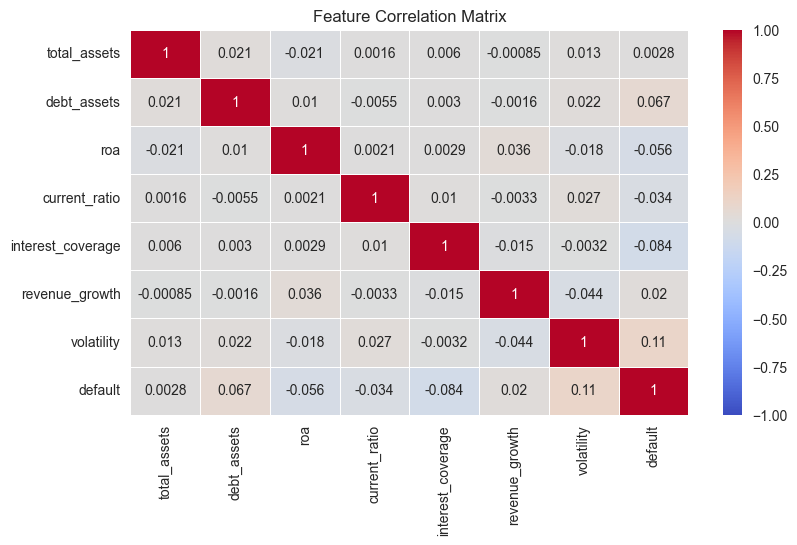

In [244]:
plt.figure(figsize=(9, 5))
corr_matrix = df_2023[features + ['default']].corr()
sns.heatmap(
        corr_matrix, 
        annot=True, 
        cmap='coolwarm',
        #cmap="RdBu_r",     
        vmin=-1, vmax=1,     
        linewidths=0.5,      
        ##linecolor='lightgray',
        cbar=True,
        center=0)

plt.title('Feature Correlation Matrix')
plt.show()

In [159]:
X_train = df_2023[features]
y_train = df_2023['default']
X_test = df_2024[features]
y_test = df_2024['default']

In [161]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [214]:
param_grid = {
    'C': [0.01, 0.1, 1, 5, 10],
    #'class_weight': [None, 'balanced']
}

In [216]:
base_model = LogisticRegression(
    max_iter = 1000, 
    random_state = 42,
    penalty = 'l2',
    solver = 'lbfgs'
)


In [218]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [220]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [222]:
grid_search = GridSearchCV(
            base_model,
            param_grid=param_grid,
            cv=cv_strategy,
            scoring='roc_auc', 
            n_jobs=-1,
            verbose=0,
            return_train_score=True
        )     

In [224]:
grid_search.fit(X_train_scaled, y_train)

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=LogisticRegression(max_iter=1000, random_state=42),
             n_jobs=-1, param_grid={'C': [0.01, 0.1, 1, 5, 10]},
             return_train_score=True, scoring='roc_auc')

In [225]:
results_df = pd.DataFrame(grid_search.cv_results_)
results_df = results_df.sort_values('rank_test_score')

In [226]:
top_results = results_df[['param_C', 
                            'mean_train_score', 'mean_test_score', 
                            'std_test_score']].head(5)

In [227]:
top_results.columns = ['C', 'Train_AUC', 'CV_AUC', 'CV_Std']

In [232]:
print(top_results.to_string(index=False))

    C  Train_AUC   CV_AUC   CV_Std
 1.00   0.794716 0.777159 0.024894
10.00   0.794521 0.776883 0.025340
 5.00   0.794539 0.776870 0.025331
 0.10   0.794158 0.776684 0.022580
 0.01   0.786660 0.770762 0.025595


In [234]:
lr_model = grid_search.best_estimator_

In [238]:
test_auc = roc_auc_score(y_test, lr_model.predict_proba(X_test_scaled)[:, 1])
print(f"\nBest parameters: {grid_search.best_params_}")
print(f"CV AUC: {grid_search.best_score_:.4f}")
print(f"Test AUC: {test_auc:.4f}")


Best parameters: {'C': 1}
CV AUC: 0.7772
Test AUC: 0.7719


In [246]:
df_2023['debt_assets_roa'] = df_2023['debt_assets'] * df_2023['roa']
df_2024['debt_assets_roa'] = df_2024['debt_assets'] * df_2024['roa']

In [248]:
features.append('debt_assets_roa')  

In [250]:
def plot_pd_vs_deciles(df, features, target='default', q=10):
    for feature in features:
        try:
           
            df['_decile'] = pd.qcut(df[feature], q=q, duplicates='drop')
            
           
            pd_profile = df.groupby('_decile', observed=True)[target].agg(['mean', 'count']).reset_index()
            pd_profile = pd_profile.sort_values('_decile').reset_index(drop=True)
            
           
            plt.figure(figsize=(8, 5))
            x_positions = range(len(pd_profile))
            plt.plot(x_positions, pd_profile['mean'], marker='o', linewidth=2, markersize=8)
            
          
            for i, (x, y, n) in enumerate(zip(x_positions, pd_profile['mean'], pd_profile['count'])):
                plt.text(x, y, f'n={n}', fontsize=8, ha='center', va='bottom')
            
            plt.title(f'PD vs {feature} (Quantile Bins)', fontsize=12, fontweight='bold')
            plt.xlabel(f'{feature} bins', fontsize=10)
            plt.ylabel('Observed PD', fontsize=10)
            plt.xticks(x_positions, [f'Q{i+1}' for i in x_positions], rotation=45)
            plt.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.show()
            
            
            df.drop('_decile', axis=1, inplace=True)
            
        except Exception as e:
            print(f"Skipping feature {feature}: {str(e)}")
            if '_decile' in df.columns:
                df.drop('_decile', axis=1, inplace=True)

# zip: combine three lists, and creates tuples pairing elements from each list
# enumerate: add index i
# ha: horizontal alignment
# va: vertical alignment

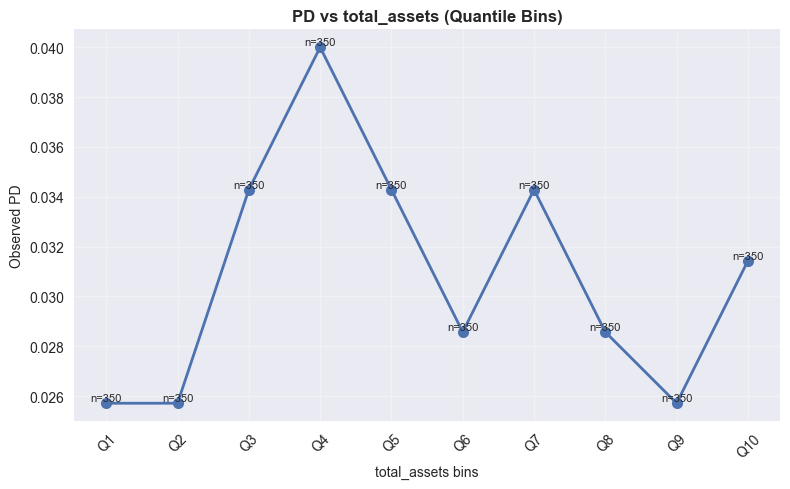

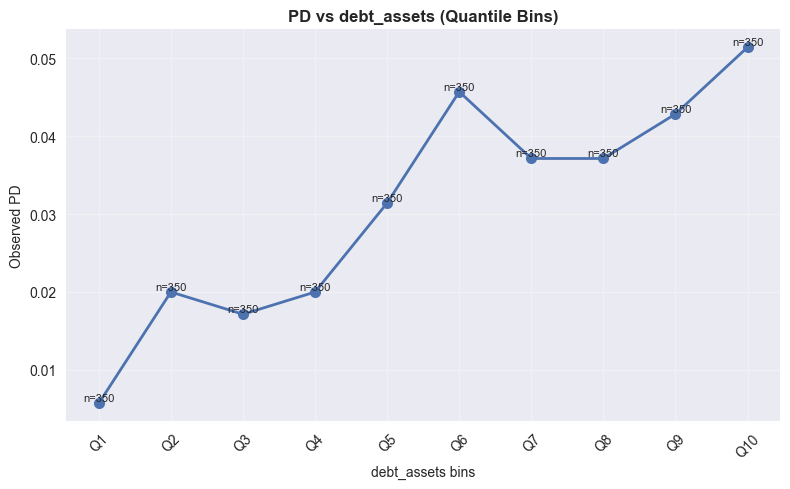

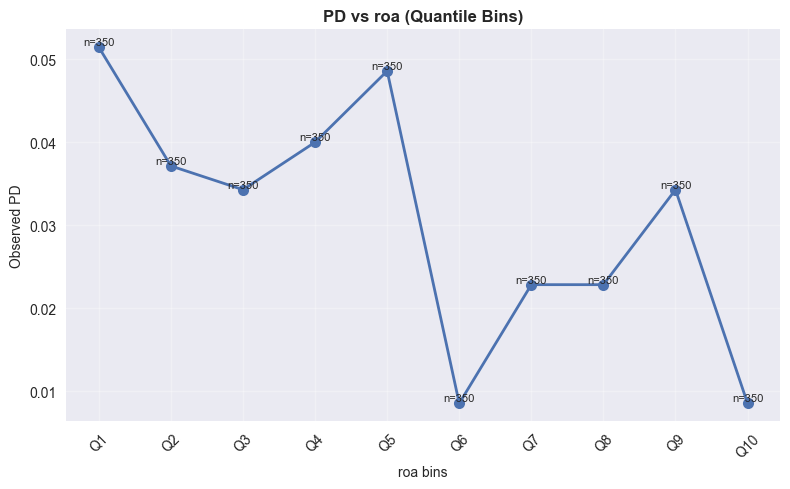

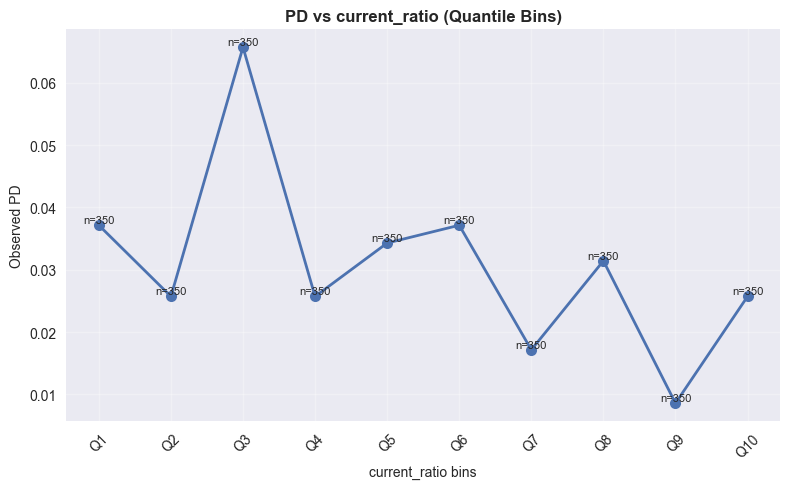

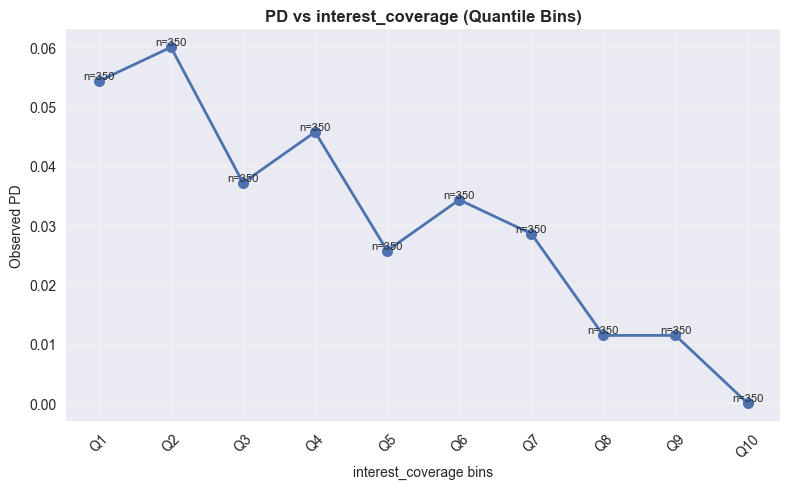

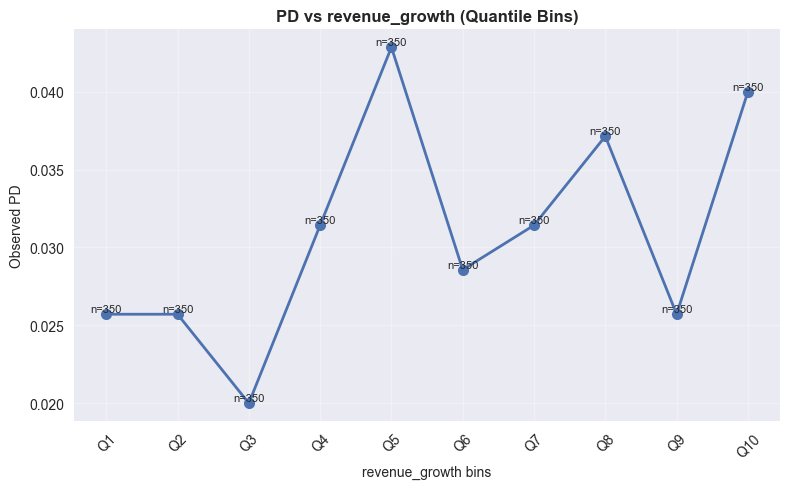

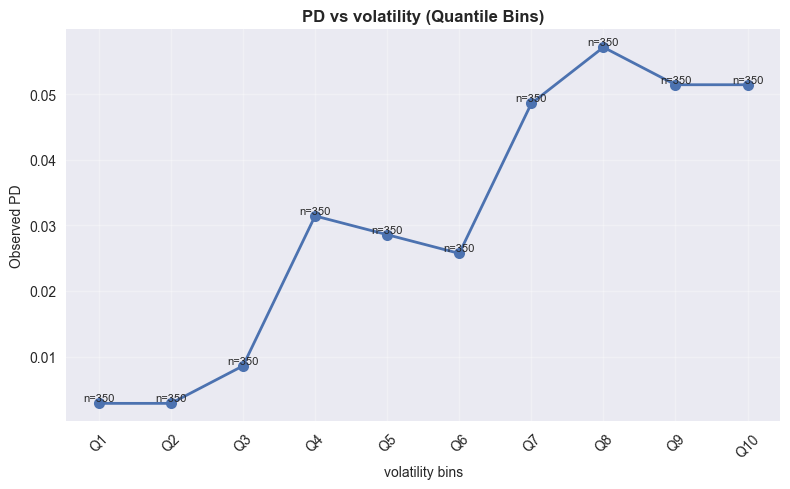

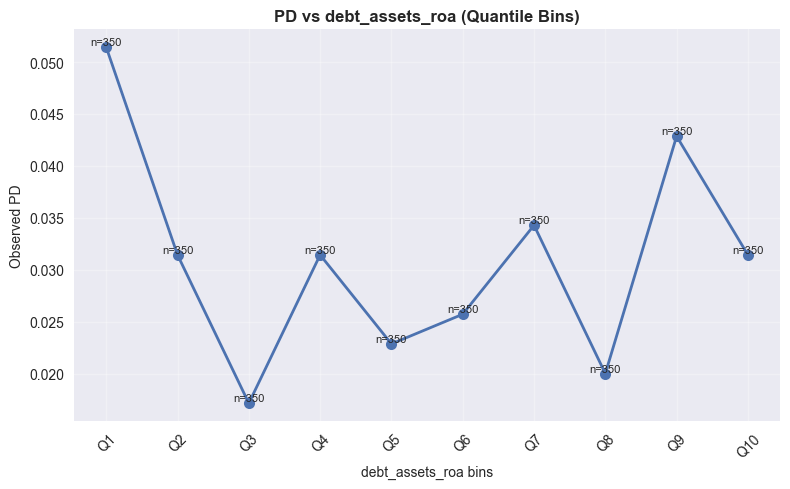

In [252]:
plot_pd_vs_deciles(df_2023, features=features)

In [47]:
def woe_iv(data, feature, target='default', q=10):
    
    df = data.copy()
    
   
    df['_bin'] = pd.qcut(df[feature], q=q, duplicates='drop')
    
  
    grouped = df.groupby('_bin', observed=True)[target].agg(['count', 'sum'])
    grouped.columns = ['total', 'defaults']
    grouped['non_defaults'] = grouped['total'] - grouped['defaults']
    
  
    grouped['default_rate'] = grouped['defaults'] / grouped['total']
    
  
    total_defaults = grouped['defaults'].sum()
    total_non_defaults = grouped['non_defaults'].sum()
    
   
    grouped['dist_default'] = grouped['defaults'] / total_defaults
    grouped['dist_non_default'] = grouped['non_defaults'] / total_non_defaults
    
   
    epsilon = 1e-10
    grouped['WoE'] = np.log(
        (grouped['dist_default'] + epsilon) / (grouped['dist_non_default'] + epsilon)
    )
    
  
    grouped['IV'] = (grouped['dist_default'] - grouped['dist_non_default']) * grouped['WoE']
    
    grouped = grouped.sort_index()
    total_iv = grouped['IV'].sum()
    
   
    woe_table = grouped[['total', 'defaults', 'non_defaults', 'default_rate', 
                         'dist_default', 'dist_non_default', 'WoE', 'IV']]
    
    return woe_table, total_iv


# high default bin : positive WoE

In [49]:
def woe_iv_report(data, features, target='default', q=10):
    report = {}
    for feature in features:
        woe_table, iv = woe_iv(data, feature, target, q)
        report[feature] = {'IV': iv, 'WoE': woe_table}
        print(f"{feature:20} IV = {iv:.4f}")
        print(woe_table.round(4))
    return report

In [51]:
features_woe = ['total_assets', 'roa', 'current_ratio', 'revenue_growth']
report = woe_iv_report(df_2023, features_woe, 'default', q=10)

total_assets         IV = 0.0229
                                  total  defaults  non_defaults  default_rate  \
_bin                                                                            
(127865.30099999999, 942279.903]    350         9           341        0.0257   
(942279.903, 1444153.275]           350         9           341        0.0257   
(1444153.275, 1963286.475]          350        12           338        0.0343   
(1963286.475, 2598255.879]          350        14           336        0.0400   
(2598255.879, 3338852.417]          350        12           338        0.0343   
(3338852.417, 4322741.968]          350        10           340        0.0286   
(4322741.968, 5593669.3]            350        12           338        0.0343   
(5593669.3, 7646251.279]            350        10           340        0.0286   
(7646251.279, 12177916.336]         350         9           341        0.0257   
(12177916.336, 165790865.628]       350        11           339        0.031

In [ ]:
# for features: 'total_assets', 'roa', 'current_ratio', 'revenue_growth',
# the increases lead to the decrease of PD, therefore WoE should decrease
# stop condition: WoE is monotonic
# safety conditions: maximum iterations, minimum # of bins
# merge criteria: violation of monotonicity, smallest chi-square
# all calculations and merging are based on dataframe woe_table

In [245]:
def chimerge_monotonic(data, feature, target='default',
                       initial_bins=30,
                       min_bins=3,
                       max_iterations=50,
                       direction='decreasing'):
    
    df = data.copy()

    df['_bin'] = pd.qcut(df[feature], q=initial_bins, duplicates='drop')
    df['_bin'] = df['_bin'].astype(object) 

    def calculate_woe_from_bins(df):
   
   
        grouped = df.groupby('_bin')[target].agg(['count', 'sum'])
        grouped.columns = ['total', 'defaults']
        grouped['non_defaults'] = grouped['total'] - grouped['defaults']
    
  
        grouped['default_rate'] = grouped['defaults'] / grouped['total']
    
  
        total_defaults = grouped['defaults'].sum()
        total_non_defaults = grouped['non_defaults'].sum()

        if total_defaults == 0 or total_non_defaults == 0:
            return None, None
    
   
        grouped['dist_default'] = grouped['defaults'] / total_defaults
        grouped['dist_non_default'] = grouped['non_defaults'] / total_non_defaults
    
   
        epsilon = 1e-10
        grouped['WoE'] = np.log(
            (grouped['dist_default'] + epsilon) / (grouped['dist_non_default'] + epsilon)
        )
    
  
        grouped['IV'] = (grouped['dist_default'] - grouped['dist_non_default']) * grouped['WoE']
    
        grouped = grouped.sort_index()
        total_iv = grouped['IV'].sum()
    
   
        woe_table = grouped[['total', 'defaults', 'non_defaults', 'default_rate', 
                         'dist_default', 'dist_non_default', 'WoE', 'IV']]
    
        return woe_table, total_iv

    def check_monotonicity(woe_values):
        woe_values = np.array(woe_values)
         
        if len(woe_values) < 2:
            return True
            
        diffs = np.diff(woe_values)
        
        return np.all(diffs >= -1e-6) or np.all(diffs <= 1e-6)

    def calculate_chi_square(bin1_counts, bin2_counts):
         
        a, b = bin1_counts
        c, d = bin2_counts
        observed = np.array([[a, c], [b, d]])
        
        if observed.sum() == 0:
            return np.inf
        if (observed.sum(axis=0) == 0).any() or (observed.sum(axis=1) == 0).any():
            return 0
        
        try:
            chi2, _, _, _ = chi2_contingency(observed)
            return chi2
        except:
            return 0

    woe_table, total_iv = calculate_woe_from_bins(df)
    if woe_table is None:
        return None, None, None
    
    print(f"Initial IV: {total_iv:.4f}")

    iteration = 0
    
    while iteration < max_iterations:
        
       

        woe_table, total_iv = calculate_woe_from_bins(df)
        woe_values = woe_table['WoE'].values
        is_monotonic = check_monotonicity(woe_values)

        current_bins = woe_table.index.tolist()
        n_bins = len(current_bins)

        if n_bins <= min_bins:
        
            if is_monotonic:
                print("Reached minimum bins - monotonic WoE")
            
            else:
                print("Reached minimum bins - WoE NOT monotonic!")
           
            break

        if is_monotonic:
            
            print("Achieved monotonic WoE")
            
            break

        if direction == 'decreasing':
            overall_direction = -1
            
        elif direction == 'increasing':
            overall_direction = 1

        else:
            raise ValueError("direction must be 'increasing', or 'decreasing'")
        

        chi_squares = []
        violations = []
        
        for i in range(len(current_bins) - 1):
            bin1 = current_bins[i]
            bin2 = current_bins[i + 1]

            bin1_defaults = woe_table.loc[bin1, 'defaults']
            bin1_non_defaults = woe_table.loc[bin1, 'non_defaults']
            bin2_defaults = woe_table.loc[bin2, 'defaults']
            bin2_non_defaults = woe_table.loc[bin2, 'non_defaults']
       
            chi2_stat = calculate_chi_square(
                (bin1_non_defaults, bin1_defaults),
                (bin2_non_defaults, bin2_defaults)
            )
            
            chi_squares.append((i, chi2_stat, bin1, bin2))

            woe1 = woe_table.loc[bin1, 'WoE']
            woe2 = woe_table.loc[bin2, 'WoE']
            diff = woe2 - woe1

            if overall_direction * diff < -1e-6:
                violations.append((i, chi2_stat, bin1, bin2))
        
        if not chi_squares:
            break
            
        if violations:
            merge_candidate = min(violations, key=lambda x: x[1])
            print("Merging violation")
        else:
            merge_candidate = min(chi_squares, key=lambda x: x[1])
            print("Merging smallest chi square")

        merge_idx, chi2_val, bin1, bin2 = merge_candidate
        new_left = min(bin1.left, bin2.left)
        new_right = max(bin1.right, bin2.right)
        merged_bin = pd.Interval(new_left, new_right, closed='right')
        
        df.loc[df['_bin'] == bin1, '_bin'] = merged_bin
        df.loc[df['_bin'] == bin2, '_bin'] = merged_bin
                
        iteration += 1


    if iteration == max_iterations:
        print("Reached maximum iterations")
        print("WoE may not be monotonic!")
    

    
    woe_table, total_iv = calculate_woe_from_bins(df)
    woe_values = woe_table['WoE'].values
    is_monotonic = check_monotonicity(woe_values)

  
    final_bins = sorted(df['_bin'].unique(), key=lambda x: x.left)
    bin_edges = [final_bins[0].left] + [b.right for b in final_bins]
    
    return woe_table, total_iv, bin_edges

    
   
   
   
    

In [248]:
def woe_iv_report(data, features, target='default',
                    initial_bins=30,
                    min_bins=3,
                    max_iterations=50,
                    direction='decreasing'):
    
    report = {}
    for feature in features:
        woe_table, total_iv, edges = chimerge_monotonic(data, feature, target, initial_bins, min_bins, max_iterations, direction)
        report[feature] = {'IV': total_iv, 'WoE': woe_table, 'bin_edge': edges}

        print(f"Final bins: {len(woe_table)}")
        print(f"{feature:20} IV = {total_iv:.4f}")
        print(woe_table.round(4))
    return report

In [250]:
features_woe = ['total_assets', 'roa', 'current_ratio', 'revenue_growth']
report = woe_iv_report(df_2023, features_woe, 'default', initial_bins=30, min_bins=3, max_iterations=50, direction='decreasing')

Initial IV: 0.8277
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Achieved monotonic WoE
Final bins: 4
total_assets         IV = 0.0041
                                   total  defaults  non_defaults  \
_bin                                                               
(127865.30099999999, 3637162.564]   1867        60          1807   
(3637162.564, 6111390.727]           699        22           677   
(6111390.727, 20794009.04]           817        23           794   
(20794009.04, 165790865.628]         117         3           114   

                                  

In [264]:
def plot_linearity(report, feature):
    table = report[feature]['WoE']
    eps = 1e-7
    df_rate = table['default_rate'].clip(eps, 1-eps)
    log_odds = np.log(df_rate / (1 - df_rate))

    plt.scatter(table['WoE'], log_odds)
    plt.xlabel("WoE")
    plt.ylabel("log-odds")
    plt.title(f"Linearity Check: {feature}")
    plt.grid(True)
    plt.show()

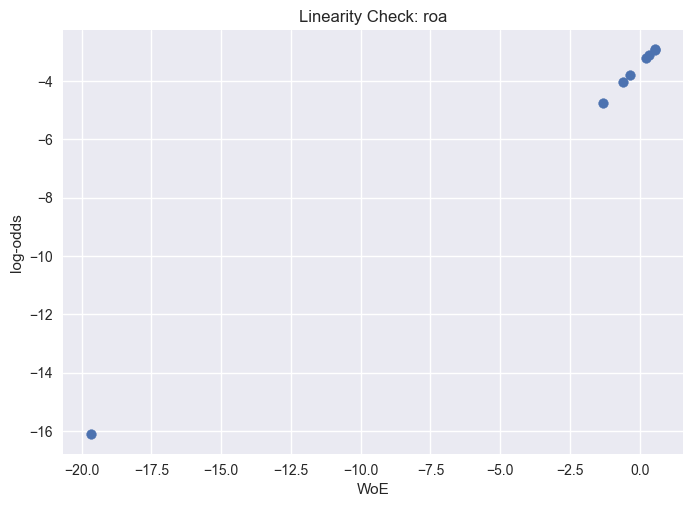

In [266]:
plot_linearity(report, 'roa')


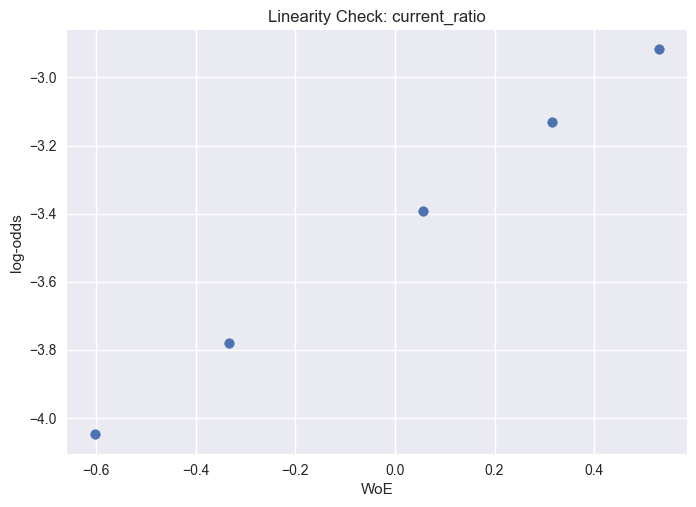

In [268]:
plot_linearity(report, 'current_ratio')

In [377]:
def chimerge_monotonic(data, feature, target='default',
                       initial_bins=30,
                       min_bins=3,
                       max_iterations=50,
                       direction='decreasing'):
    
    df = data.copy()

    df['_bin'] = pd.qcut(df[feature], q=initial_bins, duplicates='drop')
    df['_bin'] = df['_bin'].astype(object) 

    def calculate_woe_from_bins(df):
   
   
        grouped = df.groupby('_bin')[target].agg(['count', 'sum'])
        grouped.columns = ['total', 'defaults']
        grouped['non_defaults'] = grouped['total'] - grouped['defaults']
    
  
        grouped['default_rate'] = grouped['defaults'] / grouped['total']
    
  
        total_defaults = grouped['defaults'].sum()
        total_non_defaults = grouped['non_defaults'].sum()

        if total_defaults == 0 or total_non_defaults == 0:
            return None, None
    
   
        grouped['dist_default'] = grouped['defaults'] / total_defaults
        grouped['dist_non_default'] = grouped['non_defaults'] / total_non_defaults
    
   
        epsilon = 1e-10
        grouped['WoE'] = np.log(
            (grouped['dist_default'] + epsilon) / (grouped['dist_non_default'] + epsilon)
        )
    
  
        grouped['IV'] = (grouped['dist_default'] - grouped['dist_non_default']) * grouped['WoE']
    
        grouped = grouped.sort_index()
        total_iv = grouped['IV'].sum()
    
   
        woe_table = grouped[['total', 'defaults', 'non_defaults', 'default_rate', 
                         'dist_default', 'dist_non_default', 'WoE', 'IV']]
    
        return woe_table, total_iv

    def check_monotonicity(woe_values):
        woe_values = np.array(woe_values)
         
        if len(woe_values) < 2:
            return True
            
        diffs = np.diff(woe_values)
        
        return np.all(diffs >= -1e-6) or np.all(diffs <= 1e-6)

    def calculate_chi_square(bin1_counts, bin2_counts):
         
        a, b = bin1_counts
        c, d = bin2_counts
        observed = np.array([[a, c], [b, d]])
        
        if observed.sum() == 0:
            return np.inf
        if (observed.sum(axis=0) == 0).any() or (observed.sum(axis=1) == 0).any():
            return 0
        
        try:
            chi2, _, _, _ = chi2_contingency(observed)
            return chi2
        except:
            return 0

    woe_table, total_iv = calculate_woe_from_bins(df)
    if woe_table is None:
        return None, None, None
    
    print(f"Initial IV: {total_iv:.4f}")

    iteration = 0
    
    while iteration < max_iterations:
        
       

        woe_table, total_iv = calculate_woe_from_bins(df)
        woe_values = woe_table['WoE'].values
        is_monotonic = check_monotonicity(woe_values)

        current_bins = list(woe_table.index)
        n_bins = len(current_bins)

        if n_bins <= min_bins:
        
            if is_monotonic:
                print("Reached minimum bins - monotonic WoE")
            
            else:
                print("Reached minimum bins - WoE NOT monotonic!")
           
            break

        if is_monotonic:
            
            print("Achieved monotonic WoE")
            
            break

        
        overall_direction = -1 if direction == 'decreasing' else 1
            
        
        chi_squares = []
        violations = []
        
        for i in range(n_bins - 1):
            bin1 = current_bins[i]
            bin2 = current_bins[i + 1]

            bin1_defaults = woe_table.loc[bin1, 'defaults']
            bin1_non_defaults = woe_table.loc[bin1, 'non_defaults']
            bin2_defaults = woe_table.loc[bin2, 'defaults']
            bin2_non_defaults = woe_table.loc[bin2, 'non_defaults']
       
            chi2_stat = calculate_chi_square(
                (bin1_non_defaults, bin1_defaults),
                (bin2_non_defaults, bin2_defaults)
            )
            
            chi_squares.append((i, chi2_stat, bin1, bin2))

            woe1 = woe_table.loc[bin1, 'WoE']
            woe2 = woe_table.loc[bin2, 'WoE']
            diff = woe2 - woe1

            if overall_direction * diff < -1e-6:
                violations.append((i, chi2_stat, bin1, bin2))
        
        if not chi_squares:
            break
            
        if violations:
            merge_candidate = min(violations, key=lambda x: x[1])
            print("Merging violation")
        else:
            merge_candidate = min(chi_squares, key=lambda x: x[1])
            print("Merging smallest chi square")

        merge_idx, chi2_val, bin1, bin2 = merge_candidate
        new_left = min(bin1.left, bin2.left)
        new_right = max(bin1.right, bin2.right)
        merged_bin = pd.Interval(new_left, new_right, closed='right')
        
        df.loc[df['_bin'] == bin1, '_bin'] = merged_bin
        df.loc[df['_bin'] == bin2, '_bin'] = merged_bin
                
        iteration += 1


    if iteration == max_iterations:
        print("Reached maximum iterations")
        print("WoE may not be monotonic!")
    

    
    woe_table, total_iv = calculate_woe_from_bins(df)
    woe_values = woe_table['WoE'].values
    is_monotonic = check_monotonicity(woe_values)

  
    final_bins = sorted(df['_bin'].unique(), key=lambda x: x.left)
    bin_edges = [-np.inf] + [b.right for b in final_bins[:-1]] + [+np.inf]
    
    return woe_table, total_iv, bin_edges

    
   
   
   
    

In [383]:
def woe_iv_report(data, features, target='default',
                    initial_bins=30,
                    min_bins=3,
                    max_iterations=50,
                    direction='decreasing'):
    
    report = {}
    for feature in features:
        woe_table, total_iv, edges = chimerge_monotonic(
            data, feature, target, 
            initial_bins, min_bins, 
            max_iterations, direction
        )
        report[feature] = {
            'IV': total_iv, 
            'WoE': woe_table, 
            'bin_edge': edges
        }

        print(f"Final bins: {len(woe_table)}")
        print(f"{feature:20} IV = {total_iv:.4f}")
        print(woe_table[['WoE', 'IV']])
    return report

In [385]:
features_woe = ['total_assets', 'roa', 'current_ratio', 'revenue_growth']
report = woe_iv_report(df_2023, features_woe, 'default', initial_bins=30, min_bins=3, max_iterations=50, direction='decreasing')

Initial IV: 0.8277
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Achieved monotonic WoE
Final bins: 4
total_assets         IV = 0.0041
                                        WoE        IV
_bin                                                 
(127865.30099999999, 3637162.564]  0.041965  0.000958
(3637162.564, 6111390.727]         0.020415  0.000084
(6111390.727, 20794009.04]        -0.094545  0.001997
(20794009.04, 165790865.628]      -0.190542  0.001111
Initial IV: 1.7512
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging vi

In [405]:
class WoETransformer(BaseEstimator, TransformerMixin):
    def __init__(self, woe_report):
        self.woe_report = woe_report
    
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_transformed = X.copy()
        for feature in self.woe_report.keys():
            if feature in X.columns:
                woe_table = self.woe_report[feature]['WoE']
                #bin_edges = self.woe_report[feature]['bin_edge']
                
                
                woe_values = woe_table['WoE'].values
                bin_labels = woe_table.index

                woe_map = dict(zip(bin_labels, woe_values))

                bins = pd.cut(X[feature], bins=bin_labels)
             
                
                X_transformed[feature + '_woe'] = bins.map(woe_map)

                #fallback = woe_values.mean()
                #X_transformed[feature + '_woe'].fillna(fallback, inplace=True)
    
                    
        return X_transformed

    def get_params(self, deep=True):
        return {"woe_report": self.woe_report}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

In [407]:
woe_features = ['roa', 'current_ratio']
original_features = ['debt_assets', 'interest_coverage', 'volatility']

In [409]:
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WoETransformer(report), woe_features),
        ('scaler', StandardScaler(), original_features)
    ],
    remainder='drop' 
)

In [433]:
pipeline_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42, 
        max_iter=1000,
        penalty = 'l2',
        solver = 'lbfgs',
        class_weight='balanced'
    ))
])

In [375]:
#tmp = WoETransformer(report).fit_transform(X[woe_features])
#tmp.isna().sum()

In [435]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 5, 10],
    
}

In [437]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [439]:
grid_search = GridSearchCV(
            estimator=pipeline_base,
            param_grid=param_grid,
            cv=cv_strategy,
            scoring='roc_auc', 
            n_jobs=-1,
            verbose=2,
            return_train_score=True
        )   

In [441]:
X = df_2023[woe_features + original_features]
y = df_2023['default']


In [443]:
grid_search.fit(X, y)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('woe',
                                                                         WoETransformer(woe_report={'current_ratio': {'IV': 0.11496387616108558,
                                                                                                                      'WoE':                 total  defaults  non_defaults  default_rate  dist_default  \
_bin                                                                        
(0.199, 0.573]    117         6           111      0.051282      0.055556   
(0.573, 1.228]    933        39           894      0.041801      0....
                                                                                                                     'bin_edge': [-inf,
                                                                                                                                  3637162.564,
                                                                                                                                  6111390.727,
                                                                                                                                  20794009.04,
                                                                                                                                  inf]}}),
                                                                         ['roa',
                                                                          'current_ratio']),
                                                                        ('scaler',
                                                                         StandardScaler(),
                                                                         ['debt_assets',
                                                                          'interest_coverage',
                                                                          'volatility'])])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1, param_grid={'classifier__C': [0.01, 0.1, 1, 5, 10]},
             return_train_score=True, scoring='roc_auc', verbose=2)

In [444]:
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}")


Best Parameters: {'classifier__C': 5}
Best Cross-Validation ROC-AUC Score: 0.8062


In [447]:
best_model = grid_search.best_estimator_

In [449]:
y_pred = best_model.predict(X)
y_pred_proba = best_model.predict_proba(X)[:, 1]

In [451]:
print("\nClassification Report:")
print(classification_report(y, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.70      0.82      3392
           1       0.07      0.76      0.14       108

    accuracy                           0.70      3500
   macro avg       0.53      0.73      0.48      3500
weighted avg       0.96      0.70      0.80      3500



In [453]:
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))

print(f"\nROC-AUC Score: {roc_auc_score(y, y_pred_proba):.4f}")



Confusion Matrix:
[[2379 1013]
 [  26   82]]

ROC-AUC Score: 0.8183


In [455]:
precision, recall, thresholds = precision_recall_curve(y, y_pred_proba)

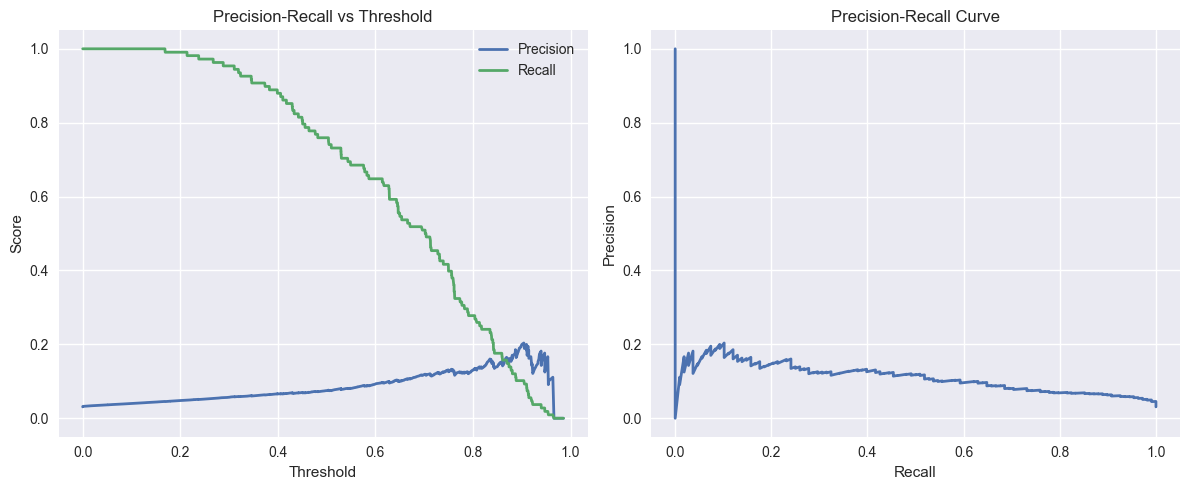

In [465]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(thresholds, precision[:-1], label='Precision', linewidth=2)
plt.plot(thresholds, recall[:-1], label='Recall', linewidth=2)
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(recall, precision, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)
plt.tight_layout()
plt.show()


In [467]:
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-10)
optimal_idx = np.argmax(f1_scores)
optimal_threshold_f1= thresholds[optimal_idx]

print(f"Optimal threshold(F1): {optimal_threshold_f1:.4f}")

Optimal threshold(F1): 0.7494


In [469]:
y_pred_optimal = (y_pred_proba >= optimal_threshold_f1).astype(int)

In [471]:
print(classification_report(y, y_pred_optimal))
print(f"Confusion Matrix:\n{confusion_matrix(y, y_pred_optimal)}")

              precision    recall  f1-score   support

           0       0.98      0.91      0.94      3392
           1       0.13      0.42      0.20       108

    accuracy                           0.90      3500
   macro avg       0.56      0.66      0.57      3500
weighted avg       0.95      0.90      0.92      3500

Confusion Matrix:
[[3093  299]
 [  63   45]]


In [493]:
threshold_setting = 0.56  

y_pred_customized = (y_pred_proba >= threshold_setting).astype(int)

print(classification_report(y, y_pred_customized))
print(confusion_matrix(y, y_pred_customized))

              precision    recall  f1-score   support

           0       0.99      0.76      0.86      3392
           1       0.08      0.69      0.15       108

    accuracy                           0.76      3500
   macro avg       0.54      0.72      0.50      3500
weighted avg       0.96      0.76      0.84      3500

[[2582  810]
 [  34   74]]


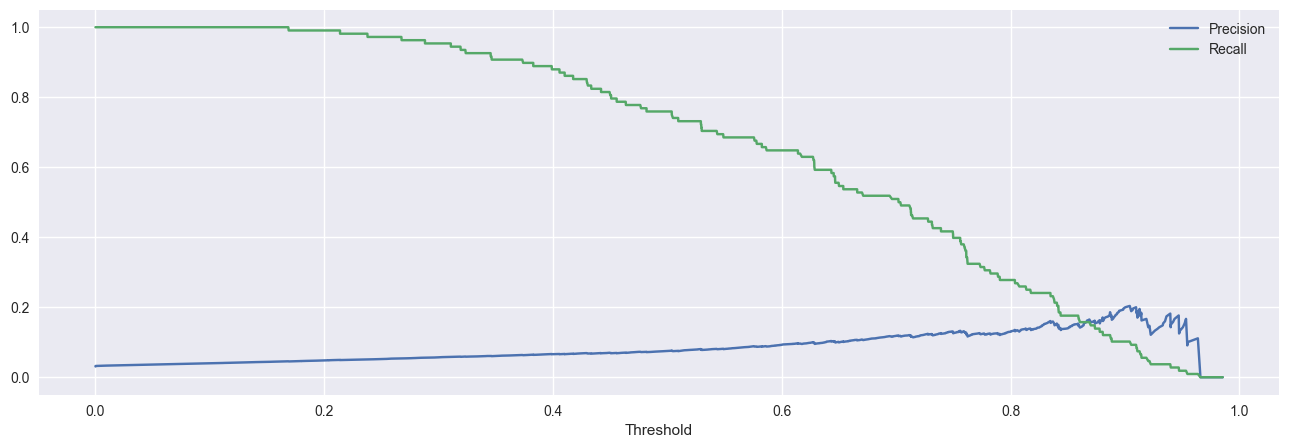

In [495]:
precision, recall, threshold_setting = precision_recall_curve(y, y_pred_proba)


plt.figure(figsize=(16, 5))
plt.plot(threshold_setting, precision[:-1], label="Precision")
plt.plot(threshold_setting, recall[:-1], label="Recall")
plt.legend()
plt.xlabel("Threshold")
plt.show()

In [ ]:
# it is crucial to have higher recall
# The F1-maximizing approach failed here 
# because it doesn't account for the asymmetric costs of different error types in credit risk

In [ ]:
# grouped = df.groupby('_bin')[target].agg(['count', 'sum'])
# woe_table = grouped[['total', 'defaults', 'non_defaults', 'default_rate', 
 #                        'dist_default', 'dist_non_default', 'WoE', 'IV']]

# report[feature] = {'IV': total_iv, 'WoE': woe_table, 'bin_edge': edges}
# grouped is dataframe with index, and its type (grouped.index) is Interval Index. 
# so woe_table is also dataframe with index, Interval Index type.
# bin_edges is the list of numeric values (floats).
# grouped.index: IntervalIndex object
# woe_table.index: IntervalIndex object
# bin_labels (dictionary key): IntervalIndex object
# type of bin_labels: InvervalIndex
# bins from pd.cut(): series with categoricalDtype, contains Interval objects
# bins = pd.cut(X[feature], bins=bin_edges, include_lowest=True)
# assign original data of features (each observation) to a bin based on bin_edges

In [ ]:
# woe_map = woe_table['WoE'].to_dict()  creating a dictionary mapping 

In [508]:
class WoETransformer(BaseEstimator, TransformerMixin):
    def __init__(self, woe_report):
        self.woe_report = woe_report
    
    def fit(self, X, y=None):
        return self
        
    def transform(self, X):
        X_transformed = X.copy()
        cols_to_drop = []
        
        for feature in self.woe_report.keys():
            if feature in X.columns:
                woe_table = self.woe_report[feature]['WoE']
                #bin_edges = self.woe_report[feature]['bin_edge']
                
                
                woe_values = woe_table['WoE'].values
                bin_labels = woe_table.index

                woe_map = dict(zip(bin_labels, woe_values))

                bins = pd.cut(X[feature], bins=bin_labels)
             
                
                X_transformed[feature + '_woe'] = bins.map(woe_map)
                
                cols_to_drop.append(feature)
                

                #fallback = woe_values.mean()
                #X_transformed[feature + '_woe'].fillna(fallback, inplace=True)

        X_transformed = X_transformed.drop(columns=cols_to_drop)
                    
        return X_transformed

    def get_params(self, deep=True):
        return {"woe_report": self.woe_report}

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

In [510]:
woe_features = ['roa', 'current_ratio']
original_features = ['debt_assets', 'interest_coverage', 'volatility']

In [512]:
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WoETransformer(report), woe_features),
        ('scaler', StandardScaler(), original_features)
    ],
    remainder='drop' 
)

In [514]:
pipeline_base = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        random_state=42, 
        max_iter=1000,
        penalty = 'l2',
        solver = 'lbfgs',
        class_weight='balanced'
    ))
])

In [516]:
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 5, 10],
    
}

In [518]:
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [520]:
grid_search = GridSearchCV(
            estimator=pipeline_base,
            param_grid=param_grid,
            cv=cv_strategy,
            scoring='roc_auc', 
            n_jobs=-1,
            verbose=2,
            return_train_score=True
        )  

In [522]:
X = df_2023[woe_features + original_features]
y = df_2023['default']

In [524]:
grid_search.fit(X, y)

Fitting 5 folds for each of 5 candidates, totalling 25 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('woe',
                                                                         WoETransformer(woe_report={'current_ratio': {'IV': 0.11496387616108558,
                                                                                                                      'WoE':                 total  defaults  non_defaults  default_rate  dist_default  \
_bin                                                                        
(0.199, 0.573]    117         6           111      0.051282      0.055556   
(0.573, 1.228]    933        39           894      0.041801      0....
                                                                                                                     'bin_edge': [-inf,
                                                                                                                                  3637162.564,
                                                                                                                                  6111390.727,
                                                                                                                                  20794009.04,
                                                                                                                                  inf]}}),
                                                                         ['roa',
                                                                          'current_ratio']),
                                                                        ('scaler',
                                                                         StandardScaler(),
                                                                         ['debt_assets',
                                                                          'interest_coverage',
                                                                          'volatility'])])),
                                       ('classifier',
                                        LogisticRegression(class_weight='balanced',
                                                           max_iter=1000,
                                                           random_state=42))]),
             n_jobs=-1, param_grid={'classifier__C': [0.01, 0.1, 1, 5, 10]},
             return_train_score=True, scoring='roc_auc', verbose=2)

In [525]:
print(f"\nBest Parameters: {grid_search.best_params_}")
print(f"Best Cross-Validation ROC-AUC Score: {grid_search.best_score_:.4f}")


Best Parameters: {'classifier__C': 1}
Best Cross-Validation ROC-AUC Score: 0.7969


In [528]:
best_model = grid_search.best_estimator_

In [530]:
y_pred = best_model.predict(X)
y_pred_proba = best_model.predict_proba(X)[:, 1]

In [532]:
print("\nClassification Report:")
print(classification_report(y, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.69      0.81      3392
           1       0.07      0.74      0.13       108

    accuracy                           0.69      3500
   macro avg       0.53      0.71      0.47      3500
weighted avg       0.96      0.69      0.79      3500



In [534]:
print("\nConfusion Matrix:")
print(confusion_matrix(y, y_pred))

print(f"\nROC-AUC Score: {roc_auc_score(y, y_pred_proba):.4f}")


Confusion Matrix:
[[2333 1059]
 [  28   80]]

ROC-AUC Score: 0.8060


In [564]:
best_model = grid_search.best_estimator_

In [536]:
def extract_feature_coeff(model, feature_names):
    Lg_model = model.named_steps['classifier']
    coefficients = Lg_model.coef_[0]
    intercept = Lg_model.intercept_[0]

    coef_df = pd.DataFrame({
        'Feature': feature_names + ['Intercept'],
        'Coefficient': np.append(coefficients, intercept),
        
    })
    return coef_df
    

In [538]:
feature_names = ['roa_woe', 'current_ratio_woe', 'debt_assets', 'interest_coverage', 'volatility']

In [540]:
coef_df = extract_feature_coeff(best_model, feature_names)

In [542]:
print(coef_df.to_string(index=False))

          Feature  Coefficient
          roa_woe     1.096936
current_ratio_woe     1.080471
      debt_assets     0.518344
interest_coverage    -1.430244
       volatility     0.786085
        Intercept    -0.768393


In [576]:
from sklearn.utils import resample
from sklearn.base import clone

In [594]:
def bootstrap_coeff(X, y, model, n_boot= 100, random_state=42):

    bootstrap_coeffs = []
    bootstrap_AUC = []

    for i in range(n_boot):
        X_boot,y_boot = resample(
            X, y,
            replace = True,
            n_samples = len(X),
            random_state = random_state + i,
            stratify = y
        )

        model_boot = clone(model)
        model_boot.fit(X_boot, y_boot)

        Lg_model = model_boot.named_steps['classifier']
        coefficients = Lg_model.coef_[0]
        intercept = Lg_model.intercept_[0]

        bootstrap_coeffs.append(np.append(coefficients, intercept))
        


        y_pred_proba = model_boot.predict_proba(X_boot)[:, 1]
        AUC = roc_auc_score(y_boot, y_pred_proba)
        bootstrap_AUC.append(AUC)

    bootstrap_coeffs = np.array(bootstrap_coeffs)
    bootstrap_AUC = np.array(bootstrap_AUC)
           

    return bootstrap_coeffs, bootstrap_AUC
        

In [560]:
# bootstrap_coeffs shape: n_boot, n features, axis = 0: across all bootstrap samples for a fixed feature


In [596]:
bootstrap_coeffs, bootstrap_AUC = bootstrap_coeff(X, y, best_model, n_boot= 100, random_state=42)

In [617]:
confidence_level = 0.95
alpha = (1 - confidence_level)/2

In [619]:
coeff_means = np.mean(bootstrap_coeffs, axis=0)
coeff_stds = np.std(bootstrap_coeffs, axis=0)
coeff_lower = np.percentile(bootstrap_coeffs, alpha * 100, axis=0)
coeff_upper = np.percentile(bootstrap_coeffs, (1 - alpha) * 100, axis=0)


In [621]:
bootstrap_coeffs.shape

(100, 6)

In [623]:
bootstrap_results = pd.DataFrame({
    'Feature': feature_names + ['Intercept'],
    'Bootstrap_Mean': coeff_means,
    'Bootstrap_Std': coeff_stds,
    'CI_Lower_95%': coeff_lower,
    'CI_Upper_95%': coeff_upper
})

In [625]:
print("\nCOEFFICIENT CONFIDENCE INTERVALS (95%)")
print(bootstrap_results.to_string(index=False))


COEFFICIENT CONFIDENCE INTERVALS (95%)
          Feature  Bootstrap_Mean  Bootstrap_Std  CI_Lower_95%  CI_Upper_95%
          roa_woe        1.098405       0.339646      0.399439      1.756203
current_ratio_woe        1.072122       0.392701      0.312374      1.775713
      debt_assets        0.523822       0.108693      0.367761      0.735072
interest_coverage       -1.459704       0.217520     -1.868428     -1.103071
       volatility        0.797776       0.103967      0.618921      1.029329
        Intercept       -0.813829       0.126235     -1.043604     -0.605666


In [627]:
bootstrap_coeffs, bootstrap_AUC = bootstrap_coeff(X, y, best_model, n_boot= 1000, random_state=42)

In [628]:
coeff_means = np.mean(bootstrap_coeffs, axis=0)
coeff_stds = np.std(bootstrap_coeffs, axis=0)
coeff_lower = np.percentile(bootstrap_coeffs, alpha * 100, axis=0)
coeff_upper = np.percentile(bootstrap_coeffs, (1 - alpha) * 100, axis=0)

In [629]:
bootstrap_results = pd.DataFrame({
    'Feature': feature_names + ['Intercept'],
    'Bootstrap_Mean': coeff_means,
    'Bootstrap_Std': coeff_stds,
    'CI_Lower_95%': coeff_lower,
    'CI_Upper_95%': coeff_upper
})

In [630]:
print("\nCOEFFICIENT CONFIDENCE INTERVALS (95%)")
print(bootstrap_results.to_string(index=False))


COEFFICIENT CONFIDENCE INTERVALS (95%)
          Feature  Bootstrap_Mean  Bootstrap_Std  CI_Lower_95%  CI_Upper_95%
          roa_woe        1.131259       0.312440      0.545217      1.771222
current_ratio_woe        1.106805       0.346509      0.465041      1.813268
      debt_assets        0.518005       0.106937      0.304184      0.726090
interest_coverage       -1.456988       0.220958     -1.920334     -1.064021
       volatility        0.795075       0.105753      0.602330      1.012870
        Intercept       -0.809821       0.130770     -1.084734     -0.582442


In [635]:
AUC_mean = np.mean(bootstrap_AUC)
AUC_std = np.std(bootstrap_AUC)
AUC_lower = np.percentile(bootstrap_AUC, 2.5)
AUC_higher = np.percentile(bootstrap_AUC, 97.5)

In [639]:
print(f"\nMODEL STABILITY (ROC-AUC)")

print(f"Mean AUC: {AUC_mean:.4f}")
print(f"Std AUC: {AUC_std:.4f}")
print(f"95% CI_lower: {AUC_lower:.4f}")
print(f"95% CI_higher:{AUC_higher:.4f}")


MODEL STABILITY (ROC-AUC)
Mean AUC: 0.8100
Std AUC: 0.0165
95% CI_lower: 0.7763
95% CI_higher:0.8422


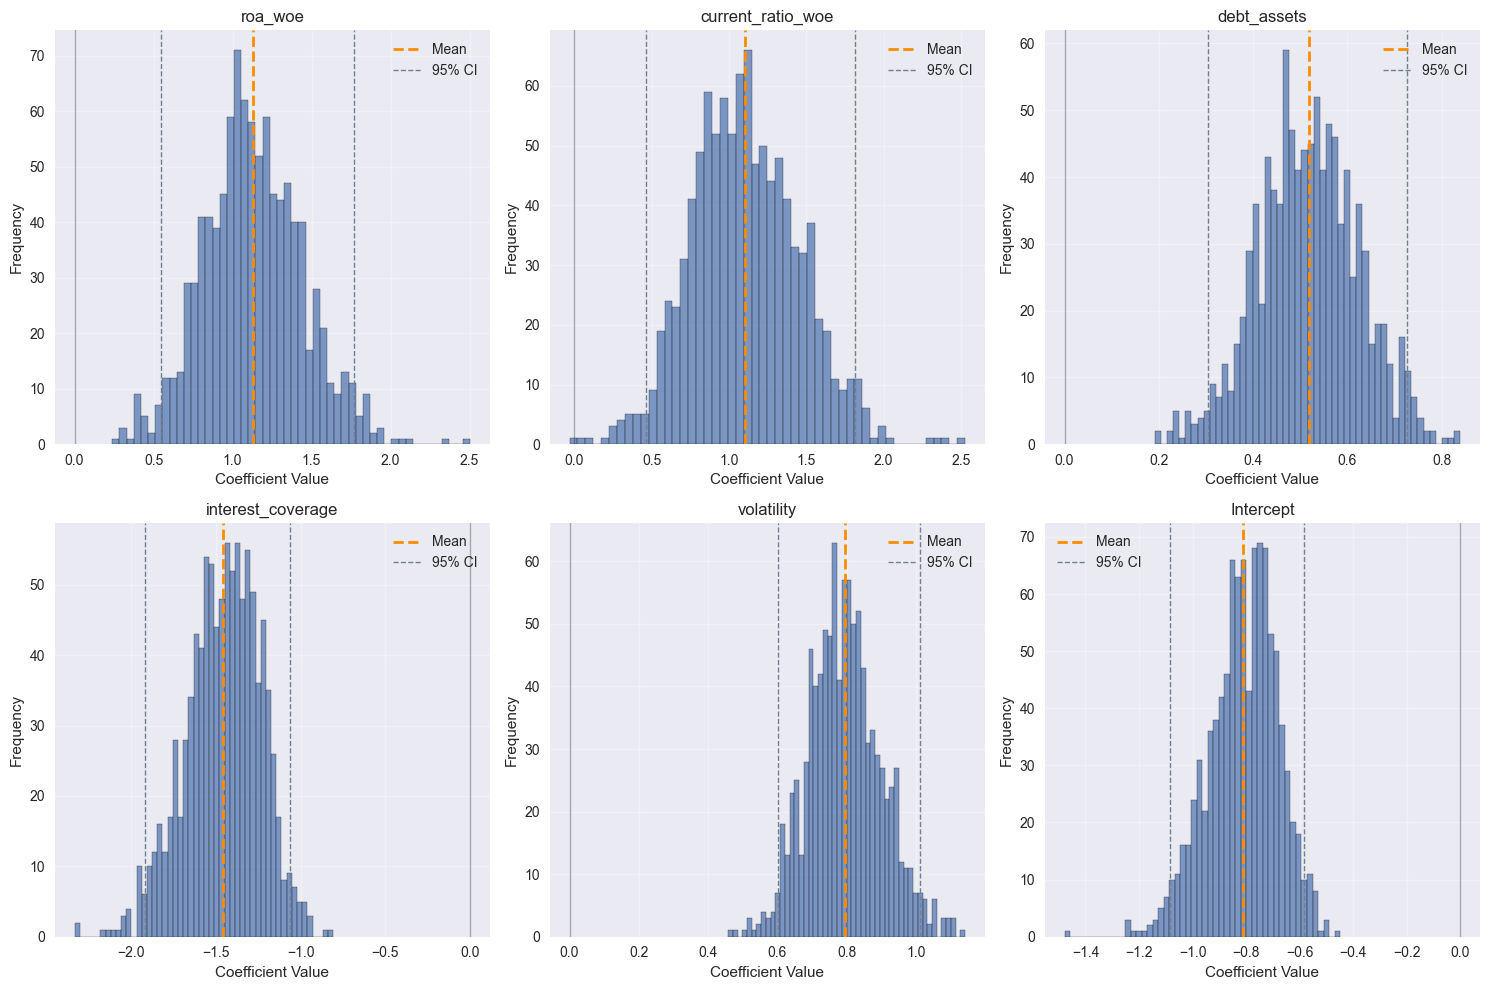

In [677]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, (feature, ax) in enumerate(zip(feature_names + ['Intercept'], axes)):
    ax.hist(bootstrap_coeffs[:, i], bins=50, alpha=0.7, edgecolor='black')
    ax.axvline(coeff_means[i], color='darkorange', linestyle='--', linewidth=2, label='Mean')
    ax.axvline(coeff_lower[i], color='slategray', linestyle='--', linewidth=1, label='95% CI')
    ax.axvline(coeff_upper[i], color='slategray', linestyle='--', linewidth=1)
    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.3)
    ax.set_xlabel('Coefficient Value')
    ax.set_ylabel('Frequency')
    ax.set_title(f'{feature}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('bootstrap_coefficients.png', dpi=300, bbox_inches='tight')
plt.show()

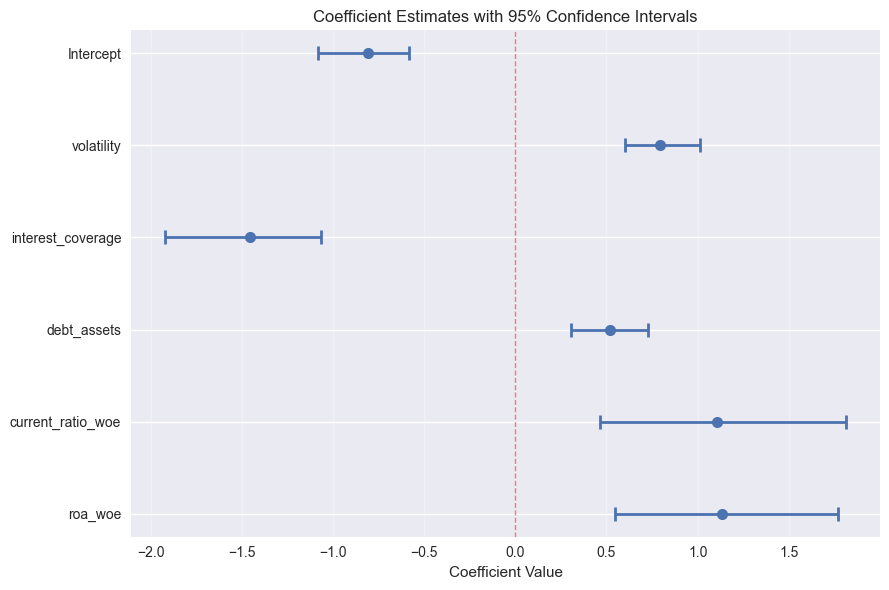

In [660]:
plt.figure(figsize=(9, 6))
y_pos = np.arange(len(feature_names) + 1)

plt.errorbar(coeff_means, y_pos, 
             xerr=[coeff_means - coeff_lower, coeff_upper - coeff_means],
             fmt='o', markersize=8, capsize=5, capthick=2, linewidth=2)
plt.axvline(0, color='red', linestyle='--', linewidth=1, alpha=0.5)
plt.yticks(y_pos, feature_names + ['Intercept'])
plt.xlabel('Coefficient Value')
plt.title('Coefficient Estimates with 95% Confidence Intervals')
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('coefficient_forest_plot.png', dpi=300, bbox_inches='tight')
plt.show()

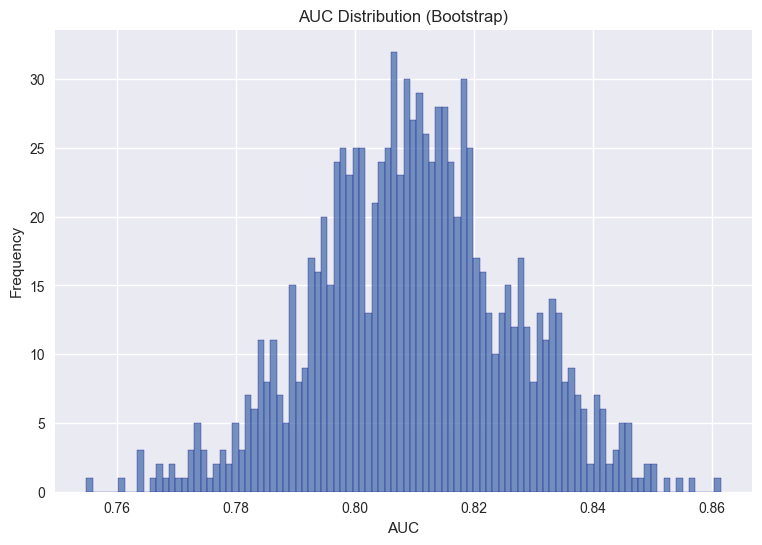

In [695]:
plt.figure(figsize=(9,6))
plt.hist(bootstrap_AUC, bins=100, alpha=0.76, edgecolor='navy')
plt.title("AUC Distribution (Bootstrap)")
plt.xlabel("AUC")
plt.ylabel("Frequency")
plt.show()

In [ ]:
#features_woe = ['total_assets', 'roa', 'current_ratio', 'revenue_growth']

In [701]:
report_2024 = woe_iv_report(df_2024, features_woe, 'default', initial_bins=30, min_bins=3, max_iterations=50, direction='decreasing')

Initial IV: 0.2084
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Achieved monotonic WoE
Final bins: 4
total_assets         IV = 0.0142
                                  WoE        IV
_bin                                           
(122008.167, 2252382.799]    0.110100  0.004676
(2252382.799, 2486126.807]   0.106848  0.000401
(2486126.807, 5503017.955]   0.012766  0.000049
(5503017.955, 78879656.874] -0.181360  0.009082
Initial IV: 1.7031
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging violation
Merging vi

In [703]:
woe_features_2024 = ['roa', 'current_ratio']
original_features_2024 = ['debt_assets', 'interest_coverage', 'volatility']

In [767]:
# report = woe_iv_report(df_2023, features_woe, 'default', initial_bins=30, min_bins=3, max_iterations=50, direction='decreasing')

In [769]:
preprocessor = ColumnTransformer(
    transformers=[
        ('woe', WoETransformer(report), woe_features_2024),
        ('scaler', StandardScaler(), original_features_2024)
    ],
    remainder='drop' 
)

In [771]:
X_2024 = df_2024[woe_features_2024 + original_features_2024]
y_2024 = df_2024['default']

In [ ]:
# y_pred = best_model.predict(X)
# y_pred_proba = best_model.predict_proba(X)[:, 1]

In [717]:
# y_pred_2024= best_model.predict(X_2024)

In [773]:
y_pred_prob_2024 =  best_model.predict_proba(X_2024)[:, 1]

In [775]:
prob_true, prob_pred = calibration_curve(
    y_2024, y_pred_prob_2024, n_bins=10, strategy='quantile'
)

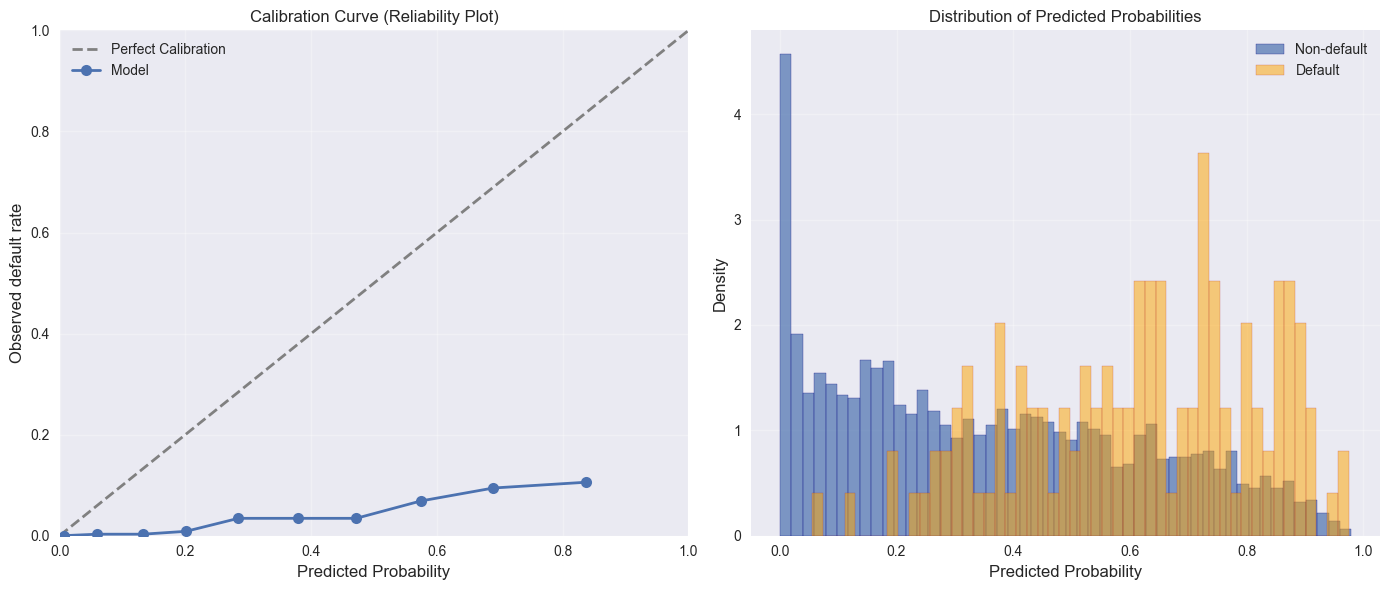

In [777]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.plot([0, 1], [0, 1], 'k--', color='gray', linewidth=2, label='Perfect Calibration')
ax1.plot(prob_pred, prob_true, marker='o', 
         linewidth=2, markersize=8, label='Model')
ax1.set_xlabel('Predicted Probability', fontsize=12)
ax1.set_ylabel('Observed default rate', fontsize=12)
ax1.set_title('Calibration Curve (Reliability Plot)', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

ax2.hist(y_pred_prob_2024[y_2024 == 0], bins=50, alpha=0.7, edgecolor='navy', label='Non-default', density=True)
ax2.hist(y_pred_prob_2024[y_2024 == 1], bins=50, alpha=0.5, color='orange', edgecolor='firebrick', label='Default', density=True)
ax2.set_xlabel('Predicted Probability', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Distribution of Predicted Probabilities', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

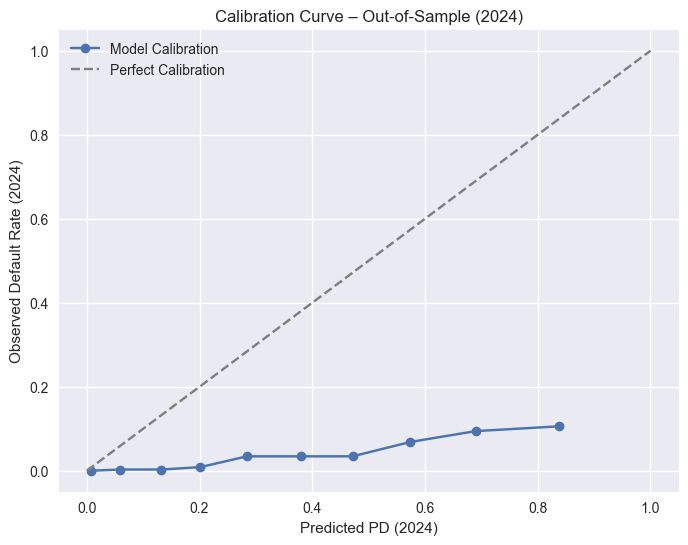

In [719]:
plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', label="Model Calibration")
plt.plot([0,1], [0,1], linestyle='--', color='gray', label="Perfect Calibration")
plt.xlabel("Predicted PD (2024)")
plt.ylabel("Observed Default Rate (2024)")
plt.title("Calibration Curve – Out-of-Sample (2024)")
plt.legend()
plt.grid(True)
plt.show()

In [729]:
from sklearn.metrics import brier_score_loss

In [779]:
brier_score = brier_score_loss(y_2024, y_pred_prob_2024)
print(f"\nBrier Score: {brier_score:.4f}")


Brier Score: 0.1935


In [781]:
ece = np.mean(np.abs(prob_true - prob_pred))
print(f"Expected Calibration Error (ECE): {ece:.4f}")

Expected Calibration Error (ECE): 0.3251


In [783]:
# ============================================================================
# VERIFY YOUR WORKFLOW
# ============================================================================

print("="*80)
print("WORKFLOW VERIFICATION")
print("="*80)

# 1. Check if best_model is from 2023 training
print("\n1. Model Source:")
print(f"   best_model is grid_search.best_estimator_: {best_model is grid_search.best_estimator_}")
print(f"   Model was trained on 2023: {True if best_model is grid_search.best_estimator_ else 'Unknown'}")

# 2. Check the preprocessor INSIDE best_model (the one that matters)
print("\n2. Preprocessor Inside best_model (the one actually used):")
fitted_preprocessor = best_model.named_steps['preprocessor']
fitted_woe_transformer = fitted_preprocessor.named_transformers_['woe']
print(f"   Type: {type(fitted_woe_transformer)}")
print(f"   Has woe_report: {hasattr(fitted_woe_transformer, 'woe_report')}")

# 3. Check your NEW preprocessor (the one you created but isn't used)
print("\n3. New Preprocessor You Created (NOT used by best_model):")
print(f"   Type: {type(preprocessor)}")
print(f"   This preprocessor is NEVER used in predictions!")

# 4. Verify predictions
print("\n4. When you call best_model.predict_proba(X_2024):")
print(f"   ✓ X_2024 is passed to best_model")
print(f"   ✓ best_model uses its INTERNAL fitted preprocessor (from 2023 training)")
print(f"   ✗ Your NEW preprocessor variable is ignored")

# 5. Test this
print("\n5. Verification Test:")
y_pred_test = best_model.predict_proba(X_2024)[:, 1]
print(f"   Predictions range: [{y_pred_test.min():.4f}, {y_pred_test.max():.4f}]")
print(f"   Mean prediction: {y_pred_test.mean():.4f}")
print(f"   These predictions use the 2023 WoE bins ✓")

print("="*80)

WORKFLOW VERIFICATION

1. Model Source:
   best_model is grid_search.best_estimator_: True
   Model was trained on 2023: True

2. Preprocessor Inside best_model (the one actually used):
   Type: <class '__main__.WoETransformer'>
   Has woe_report: True

3. New Preprocessor You Created (NOT used by best_model):
   Type: <class 'sklearn.compose._column_transformer.ColumnTransformer'>
   This preprocessor is NEVER used in predictions!

4. When you call best_model.predict_proba(X_2024):
   ✓ X_2024 is passed to best_model
   ✓ best_model uses its INTERNAL fitted preprocessor (from 2023 training)
   ✗ Your NEW preprocessor variable is ignored

5. Verification Test:
   Predictions range: [0.0000, 0.9794]
   Mean prediction: 0.3636
   These predictions use the 2023 WoE bins ✓


In [785]:
print("="*80)
print("PREDICTION vs REALITY CHECK")
print("="*80)

print(f"\n2024 Actual default rate: {y_2024.mean():.4%}")
print(f"2024 Mean predicted probability: {y_pred_prob_2024.mean():.4%}")
print(f"Difference: {abs(y_2024.mean() - y_pred_prob_2024.mean()):.4%}")

if y_pred_prob_2024.mean() > y_2024.mean() * 1.5:
    print("\n⚠️ WARNING: Model is OVER-PREDICTING defaults significantly!")
    print("   This is likely due to class_weight='balanced'")
elif y_pred_prob_2024.mean() < y_2024.mean() * 0.5:
    print("\n⚠️ WARNING: Model is UNDER-PREDICTING defaults significantly!")
else:
    print("\n✓ Mean prediction is reasonably close to actual rate")

print("\n" + "="*80)
print("PREDICTION DISTRIBUTION ANALYSIS")
print("="*80)

# Check distribution of predictions
print("\nPrediction percentiles:")
percentiles = [0, 10, 25, 50, 75, 90, 95, 99, 100]
for p in percentiles:
    value = np.percentile(y_pred_prob_2024, p)
    print(f"  {p:3d}th percentile: {value:.4f}")

print(f"\nActual defaults by prediction bins:")
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for i in range(len(bins)-1):
    mask = (y_pred_prob_2024 >= bins[i]) & (y_pred_prob_2024 < bins[i+1])
    count = mask.sum()
    if count > 0:
        actual_rate = y_2024[mask].mean()
        print(f"  Predicted [{bins[i]:.1f}, {bins[i+1]:.1f}): "
              f"{count:4d} samples, actual default rate: {actual_rate:.2%}")
    else:
        print(f"  Predicted [{bins[i]:.1f}, {bins[i+1]:.1f}): {count:4d} samples")

print("="*80)

PREDICTION vs REALITY CHECK

2024 Actual default rate: 3.8571%
2024 Mean predicted probability: 36.3629%
Difference: 32.5057%

⚠️ WARNING: Model is OVER-PREDICTING defaults significantly!
   This is likely due to class_weight='balanced'

PREDICTION DISTRIBUTION ANALYSIS

Prediction percentiles:
    0th percentile: 0.0000
   10th percentile: 0.0281
   25th percentile: 0.1345
   50th percentile: 0.3316
   75th percentile: 0.5706
   90th percentile: 0.7529
   95th percentile: 0.8342
   99th percentile: 0.9173
  100th percentile: 0.9794

Actual defaults by prediction bins:
  Predicted [0.0, 0.1):  724 samples, actual default rate: 0.14%
  Predicted [0.1, 0.2):  512 samples, actual default rate: 0.39%
  Predicted [0.2, 0.3):  400 samples, actual default rate: 1.75%
  Predicted [0.3, 0.4):  366 samples, actual default rate: 3.83%
  Predicted [0.4, 0.5):  373 samples, actual default rate: 4.29%
  Predicted [0.5, 0.6):  323 samples, actual default rate: 5.26%
  Predicted [0.6, 0.7):  301 sampl

In [787]:
from sklearn.metrics import roc_auc_score

print("\n" + "="*80)
print("DISCRIMINATION vs CALIBRATION")
print("="*80)

auc_2024 = roc_auc_score(y_2024, y_pred_prob_2024)

print(f"\nROC-AUC (discrimination): {auc_2024:.4f}")
print(f"ECE (calibration): {0.3251:.4f}")

print("\nInterpretation:")
print("  - ROC-AUC measures if model can RANK defaults correctly")
print("  - ECE measures if predicted probabilities MATCH actual rates")
print("  - You can have good AUC but poor calibration!")

if auc_2024 > 0.7 and 0.3251 > 0.1:
    print("\n✓ Model has good discrimination (AUC > 0.7)")
    print("✗ But poor calibration (ECE > 0.1)")
    print("→ Solution: Apply calibration (isotonic regression)")
elif auc_2024 < 0.65:
    print("\n✗ Model has poor discrimination (AUC < 0.65)")
    print("→ Problem: Model needs retraining or better features")

print("="*80)


DISCRIMINATION vs CALIBRATION

ROC-AUC (discrimination): 0.7755
ECE (calibration): 0.3251

Interpretation:
  - ROC-AUC measures if model can RANK defaults correctly
  - ECE measures if predicted probabilities MATCH actual rates
  - You can have good AUC but poor calibration!

✓ Model has good discrimination (AUC > 0.7)
✗ But poor calibration (ECE > 0.1)
→ Solution: Apply calibration (isotonic regression)


In [793]:
from sklearn.utils.class_weight import compute_class_weight

In [811]:
print("\n" + "="*80)
print("DEFAULT RATE COMPARISON")
print("="*80)

print(f"\n2023 (Training) default rate: {df_2023['default'].mean():.4%}")
print(f"2024 (Test) default rate: {y_2024.mean():.4%}")
print(f"Ratio (2024/2023): {y_2024.mean() / df_2023['default'].mean():.2f}x")

# Calculate expected prediction if model was perfect
expected_pred = df_2023['default'].mean()
print(f"\nIf 2024 had same characteristics as 2023:")
print(f"  Expected mean prediction: ~{expected_pred:.4%}")
print(f"  Actual mean prediction: {y_pred_prob_2024.mean():.4%}")

# Check if class_weight='balanced' is the culprit

class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=df_2023['default'])
print(f"\nClass weights used in training:")
print(f"  Non-default (0): {class_weights[0]:.4f}")
print(f"  Default (1): {class_weights[1]:.4f}")
print(f"  This amplifies default predictions by {class_weights[1]/class_weights[0]:.1f}x")

print("="*80)


DEFAULT RATE COMPARISON

2023 (Training) default rate: 3.0857%
2024 (Test) default rate: 3.8571%
Ratio (2024/2023): 1.25x

If 2024 had same characteristics as 2023:
  Expected mean prediction: ~3.0857%
  Actual mean prediction: 36.3629%

Class weights used in training:
  Non-default (0): 0.5159
  Default (1): 16.2037
  This amplifies default predictions by 31.4x


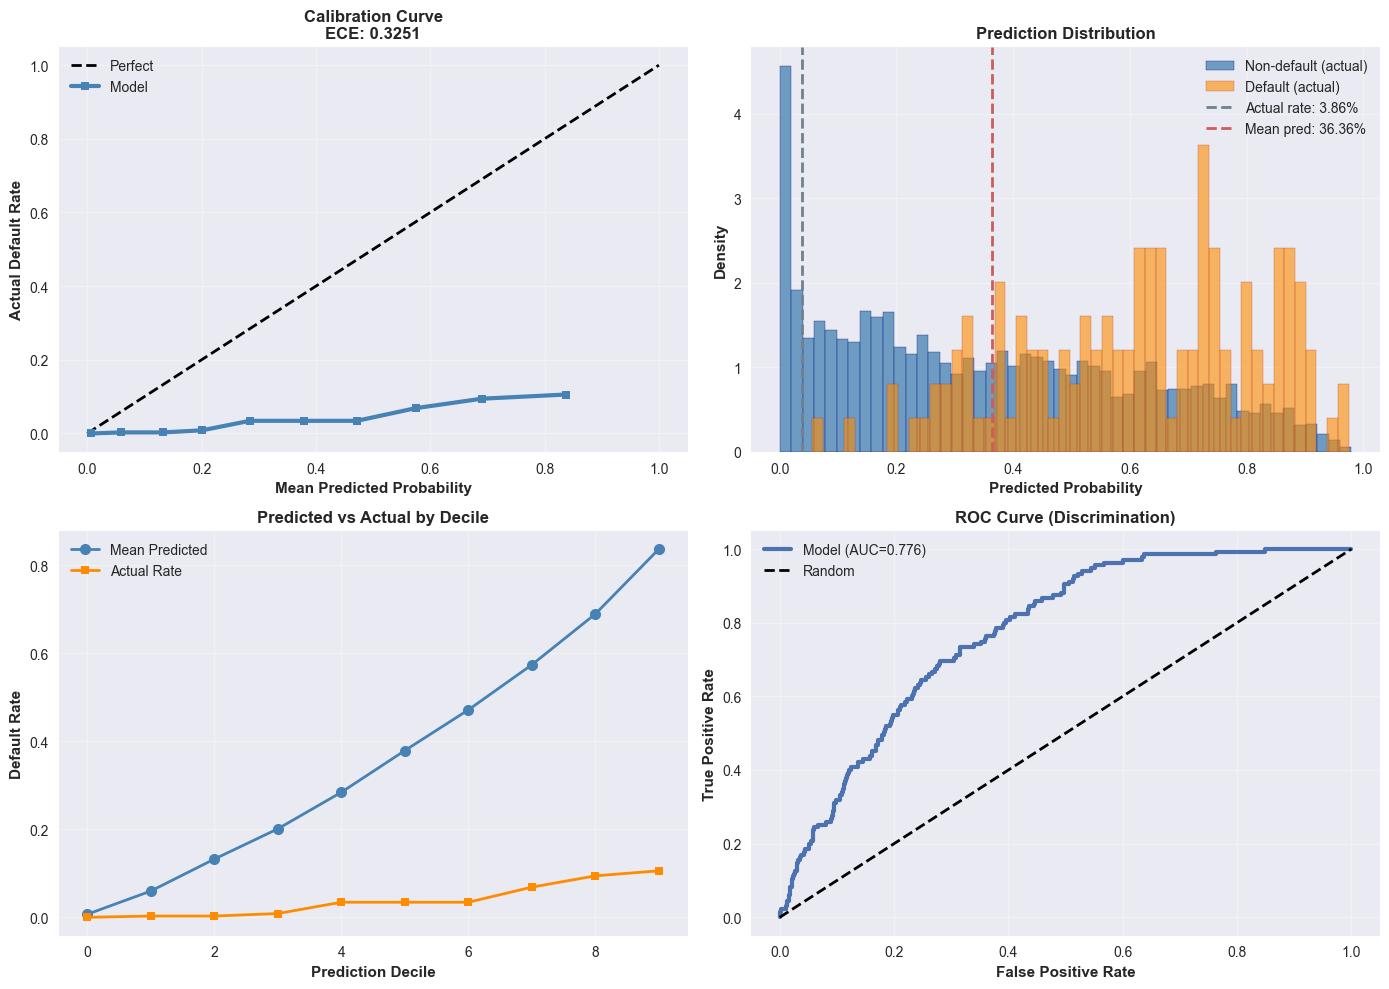


✓ Diagnostic plots saved!


In [809]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Calibration curve
ax1 = axes[0, 0]
ax1.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Perfect')
ax1.plot(prob_pred, prob_true, 's-', linewidth=3, markersize=6, 
         color='steelblue', label='Model')
ax1.set_xlabel('Mean Predicted Probability', fontsize=11, fontweight='bold')
ax1.set_ylabel('Actual Default Rate', fontsize=11, fontweight='bold')
ax1.set_title(f'Calibration Curve\nECE: {0.3251:.4f}', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: Prediction distribution by actual class
ax2 = axes[0, 1]
ax2.hist(y_pred_prob_2024[y_2024==0], bins=50, alpha=0.76, 
         label='Non-default (actual)', density=True, color='steelblue',edgecolor='navy')
ax2.hist(y_pred_prob_2024[y_2024==1], bins=50, alpha=0.6, 
         label='Default (actual)', density=True, color='darkorange',edgecolor='firebrick')
ax2.axvline(y_2024.mean(), color='slategray', linestyle='--', linewidth=2, 
            label=f'Actual rate: {y_2024.mean():.2%}')
ax2.axvline(y_pred_prob_2024.mean(), color='indianred', linestyle='--', linewidth=2,
            label=f'Mean pred: {y_pred_prob_2024.mean():.2%}')
ax2.set_xlabel('Predicted Probability', fontsize=11, fontweight='bold')
ax2.set_ylabel('Density', fontsize=11, fontweight='bold')
ax2.set_title('Prediction Distribution', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Plot 3: Actual default rate by prediction decile
ax3 = axes[1, 0]
deciles = pd.qcut(y_pred_prob_2024, q=10, duplicates='drop')
decile_stats = pd.DataFrame({
    'predicted': y_pred_prob_2024,
    'actual': y_2024,
    'decile': deciles
}).groupby('decile').agg({
    'predicted': 'mean',
    'actual': 'mean'
})

x_pos = range(len(decile_stats))
ax3.plot(x_pos, decile_stats['predicted'], 'o-', label='Mean Predicted', 
         markersize=8, linewidth=2, color='steelblue')
ax3.plot(x_pos, decile_stats['actual'], 's-', label='Actual Rate', 
         markersize=6, linewidth=2, color='darkorange')
ax3.set_xlabel('Prediction Decile', fontsize=11, fontweight='bold')
ax3.set_ylabel('Default Rate', fontsize=11, fontweight='bold')
ax3.set_title('Predicted vs Actual by Decile', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: ROC curve
ax4 = axes[1, 1]
from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_2024, y_pred_prob_2024)
auc_2024 = roc_auc_score(y_2024, y_pred_prob_2024)
ax4.plot(fpr, tpr, linewidth=3, label=f'Model (AUC={auc_2024:.3f})')
ax4.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random')
ax4.set_xlabel('False Positive Rate', fontsize=11, fontweight='bold')
ax4.set_ylabel('True Positive Rate', fontsize=11, fontweight='bold')
ax4.set_title('ROC Curve (Discrimination)', fontsize=12, fontweight='bold')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_diagnostics_detailed.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Diagnostic plots saved!")

In [ ]:
# y_pred_prob_2024 =  best_model.predict_proba(X_2024)[:, 1]

In [827]:
y_mean_2024 = y_2024.mean()

In [829]:
correction_factor = y_mean_2024 / (1 - y_mean_2024)

In [831]:
y_corrected_2024 = (y_pred_prob_2024 * correction_factor) / (1 - y_pred_prob_2024 + (y_pred_prob_2024 * correction_factor))

In [833]:
print(f"True pred: {y_mean_2024:.4%}")
print(f"Original pred: {y_pred_prob_2024.mean():.4%}")
print(f"Corrected pred: {y_corrected_2024.mean():.4%}")

True pred: 3.8571%
Original pred: 36.3629%
Corrected pred: 4.2221%


In [894]:
print(f"True pred: {y_mean_2024:.4%}")

True pred: 3.8571%


In [837]:
prob_true_02, prob_pred_corr= calibration_curve(
    y_2024, y_corrected_2024, n_bins=10, strategy='quantile'
)

In [859]:
brier = brier_score_loss(y_2024, y_corrected_2024)
print(f"  Brier: {brier:.4f}")

  Brier: 0.0367


In [839]:
ece = np.mean(np.abs(prob_true_02 - prob_pred_corr))
print(f"Expected Calibration Error (ECE): {ece:.4f}")

Expected Calibration Error (ECE): 0.0150


In [835]:
auc_2024 = roc_auc_score(y_2024, y_corrected_2024)

print(f"\nROC-AUC (discrimination): {auc_2024:.4f}")


ROC-AUC (discrimination): 0.7755


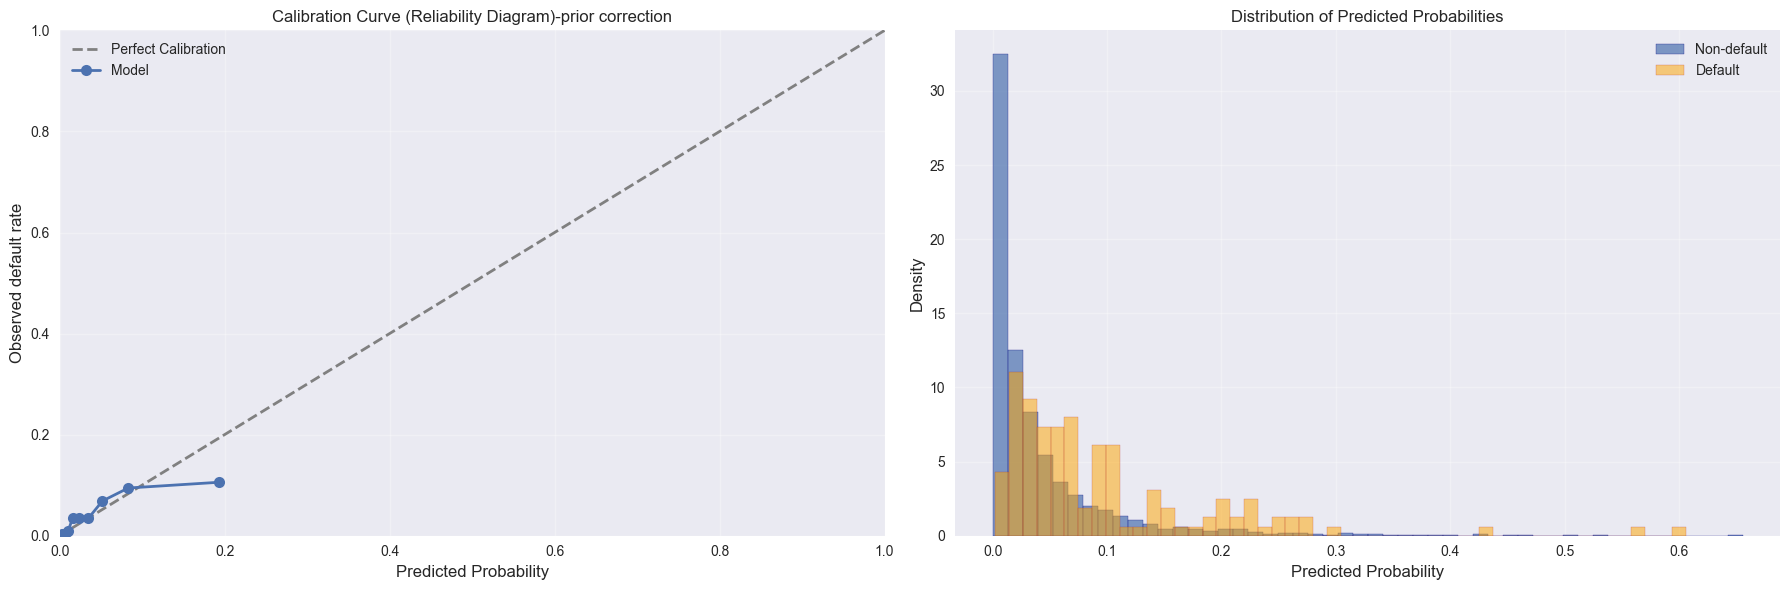

In [898]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

ax1.plot([0, 1], [0, 1], 'k--', color='gray', linewidth=2, label='Perfect Calibration')
ax1.plot(prob_pred_corr, prob_true_02, marker='o', 
         linewidth=2, markersize=8, label='Model')
ax1.set_xlabel('Predicted Probability', fontsize=12)
ax1.set_ylabel('Observed default rate', fontsize=12)
ax1.set_title('Calibration Curve (Reliability Diagram)-prior correction', fontsize=12)
ax1.legend(fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim([0, 1])
ax1.set_ylim([0, 1])

ax2.hist(y_corrected_2024[y_2024 == 0], bins=50, alpha=0.7, edgecolor='navy', label='Non-default', density=True)
ax2.hist(y_corrected_2024[y_2024 == 1], bins=50, alpha=0.5, color='orange', edgecolor='firebrick', label='Default', density=True)
ax2.set_xlabel('Predicted Probability', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('Distribution of Predicted Probabilities', fontsize=12)
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('calibration_prior_correction.png', dpi=300, bbox_inches='tight')
plt.show()

In [841]:
X_2024_cal, X_2024_valid, y_corrected24_cal, y_corrected24_valid, y_2024_cal, y_2024_valid = train_test_split(
    X_2024, y_corrected_2024, y_2024, test_size=0.30, random_state=42, stratify=y_2024
)


In [842]:
platt = LogisticRegression(solver='lbfgs')
platt.fit(y_corrected24_cal.reshape(-1,1), y_2024_cal)
y_platt24_valid = platt.predict_proba(y_corrected24_valid.reshape(-1,1))[:, 1]

In [851]:
prob_true_03, prob_pred_platt = calibration_curve(y_2024_valid, y_platt24_valid, n_bins=10, strategy='quantile')
   

In [853]:
ece_platt = np.mean(np.abs(prob_true_03 - prob_pred_platt))
print(f"  ECE: {ece_platt:.4f}")

  ECE: 0.0218


In [855]:
brier_platt = brier_score_loss(y_2024_valid, y_platt24_valid)
print(f"  Brier: {brier_platt:.4f}")

  Brier: 0.0363


In [857]:
auc_2024_platt = roc_auc_score(y_2024_valid, y_platt24_valid)

print(f"\nROC-AUC (discrimination): {auc_2024_platt:.4f}")


ROC-AUC (discrimination): 0.7208


In [861]:
eps = 1e-12
y_corrected24_calclip = np.clip(y_corrected24_cal, eps, 1 - eps)
y_corrected24_validclip = np.clip(y_corrected24_valid, eps, 1 - eps)

logity_corrected24_calclip = np.log(y_corrected24_calclip  / (1 - y_corrected24_calclip ))
logity_corrected24_validclip = np.log(y_corrected24_validclip / (1 - y_corrected24_validclip))

In [872]:
platt04 = LogisticRegression(solver='lbfgs')
platt04.fit(logity_corrected24_calclip.reshape(-1,1), y_2024_cal)

y_platt24_valid04 = platt.predict_proba(logity_corrected24_validclip.reshape(-1,1))[:,1]

In [874]:
prob_true_04, prob_pred_platt04 = calibration_curve(y_2024_valid, y_platt24_valid04, n_bins=10, strategy='quantile')

In [876]:
ece_platt04 = np.mean(np.abs(prob_true_04 - prob_pred_platt04))
print(f"  ECE: {ece_platt:.4f}")

  ECE: 0.0218


In [878]:
brier_platt04 = brier_score_loss(y_2024_valid, y_platt24_valid04)
print(f"  Brier: {brier_platt:.4f}")

  Brier: 0.0363


In [880]:
auc_2024_platt04 = roc_auc_score(y_2024_valid, y_platt24_valid04)

print(f"\nROC-AUC (discrimination): {auc_2024_platt:.4f}")


ROC-AUC (discrimination): 0.7208


In [882]:
print("Platt coef, intercept:", platt.coef_, platt.intercept_)

Platt coef, intercept: [[3.9647080611]] [-3.4172510438]


In [884]:
print("Platt coef, intercept:", platt04.coef_, platt04.intercept_)

Platt coef, intercept: [[0.778387109]] [-0.664020028]


In [886]:
print("mean prior-corr pred (val):", y_corrected24_valid.mean())
print("mean platt pred (val):", y_platt24_valid.mean())


mean prior-corr pred (val): 0.04095161939135918
mean platt pred (val): 0.0384031235484323


In [888]:
print("mean prior-corr pred (val):", y_corrected24_valid.mean())
print("mean platt pred (val):", y_platt24_valid04.mean())


mean prior-corr pred (val): 0.04095161939135918
mean platt pred (val): 0.00010787502534543068


In [890]:
np.corrcoef(y_corrected24_valid, y_platt24_valid)[0,1]

0.9648702711529966

In [892]:
np.corrcoef(y_corrected24_valid, y_platt24_valid04)[0,1]

0.4960740570983378

In [942]:
from scipy.stats import chi2_contingency

In [960]:
class RatingBand:

    def __init__(self, initial_bins = 15, min_bins = 7, min_defaults_pct = 0.05, verbose = True):
        self.initial_bins = initial_bins
        self.min_bins = min_bins
        self.min_defaults_pct = min_defaults_pct
        self.verbose = verbose
        self.bin_edges = None
        self.band_statistic_df = None
        self.df_with_bins = None

    def _print(self, *args, **kwargs):
        if self.verbose:
            print(*args, **kwargs)

    def form_rating_bands(self, corrected_PD, actual_default):
        
        # corrected_PD: corrected, predicted probability of default, numerical values
        # actual_default: actual realized defaults, 0/1 binary values, to create default rates

        df = pd.DataFrame({
            'pred_PD': corrected_PD,
            'defaults': actual_default
        }).dropna()

       
        df = df.sort_values('pred_PD').reset_index(drop=True)

        total_defaults = df['defaults'].sum()
        total_population = len(df)
        min_defaults = max(int(total_defaults * self.min_defaults_pct), 1)

        self._print(f"Total population: {total_population}")
        self._print(f"Total defaults: {int(total_defaults)}")
        self._print(f"Min defaults per bin: {min_defaults} ")

        df['_bin'] = pd.qcut(df['pred_PD'], q=self.initial_bins, duplicates='drop')
        #df['_bin'] = df['_bin'].apply(lambda iv: pd.Interval(iv.left, iv.right, closed='right'))
        
        df['_bin'] = df['_bin'].astype(object) 


        bin_statistics_df = self._calculate_bin_statistics(df)

        

        self._print(f"Initial bins:{len(bin_statistics_df)} ")

        iteration = 0
        
       
        
        while len(bin_statistics_df)>= self.min_bins:

            if self._check_monotonicity(bin_statistics_df):
            
                self._print("Monotonicity achieved")

                break

           

            merge_candidate = self. _find_violations_merge(bin_statistics_df)

            if merge_candidate is None:
                self._print('No violations. ')
                break
            
            merge_idx, _, bin1, bin2 = merge_candidate
            

 
            new_left = min(bin1.left, bin2.left)
            new_right = max(bin1.right, bin2.right)
            merged_bin = pd.Interval(new_left, new_right, closed='right')
        
            df.loc[df['_bin'] == bin1, '_bin'] = merged_bin
            df.loc[df['_bin'] == bin2, '_bin'] = merged_bin
            
            bin_statistics_df = self._calculate_bin_statistics(df)
            
            iteration += 1
            
        bin_statistics_df = self._calculate_bin_statistics(df)

        self.band_statistic_df = bin_statistics_df
        self.df_with_bins = df

        final_bins = bin_statistics_df.index.tolist()
        self.bin_edges = [-np.inf] + [b.right for b in final_bins]

        self._print(f"\nFinal number of bins: {len(bin_statistics_df)}")

        if self._check_final_constraints(bin_statistics_df, min_defaults):
            
            self._print("Minimum number of defaults per bin satisfied")

        else:
            self._print("Minimum number of defaults per bin NOT satisfied")

        return  bin_statistics_df, self.bin_edges 

        
    def _calculate_bin_statistics(self, df):

        bin_statistics = df.groupby('_bin').agg(
            PD_min=('pred_PD', 'min'),
            PD_max=('pred_PD', 'max'),
            PD_mean=('pred_PD', 'mean'),
            defaults=('defaults', 'sum'),
            total=('defaults', 'count'),
            actual_default_rate=('defaults', 'mean')
        )

       
        bin_statistics['non_defaults'] = bin_statistics['total'] - bin_statistics['defaults']

       
        bin_statistics = bin_statistics.sort_index()
        
        return bin_statistics

    def _check_monotonicity(self, bin_statistics):

        actual_default_rates = bin_statistics['actual_default_rate'].values

        actual_default_rates = np.array(actual_default_rates)

        diffs = np.diff(actual_default_rates)

        return np.all(diffs >= -1e-6) 

    def _find_violations_merge(self, bin_statistics):

        violations = []
        bins_index = bin_statistics.index.tolist()

        actual_default_rates = bin_statistics['actual_default_rate'].values

        for i in range(len(bins_index) - 1):
            bin1 = bins_index[i]
            bin2 = bins_index[i+1]

            actual_default_rate01 = bin_statistics.loc[bin1, 'actual_default_rate']
            actual_default_rate02 = bin_statistics.loc[bin2, 'actual_default_rate']
            diff = actual_default_rate02 - actual_default_rate01

            if  diff < -1e-6:

                bin1_defaults = bin_statistics.loc[bin1, 'defaults']
                bin1_non_defaults = bin_statistics.loc[bin1, 'non_defaults']
                bin2_defaults = bin_statistics.loc[bin2, 'defaults']
                bin2_non_defaults = bin_statistics.loc[bin2, 'non_defaults']
                
                chi2_stat = self._calculate_chi_square(
                    (bin1_non_defaults, bin1_defaults),
                    (bin2_non_defaults, bin2_defaults)
                    
                )
                violations.append((i, chi2_stat, bin1, bin2))

        if not violations:
            return None
                
        merge_candidate = min(violations, key=lambda x: x[1])

        return merge_candidate
        

    def _calculate_chi_square(self, bin1_counts, bin2_counts):


        bin1_non_defaults, bin1_defaults = bin1_counts
        bin2_non_defaults, bin2_defaults = bin2_counts
        
        observed = np.array([
            [bin1_non_defaults, bin2_non_defaults], 
            [bin1_defaults , bin2_defaults]])

        chi2, _, _, _ = chi2_contingency(observed)
        return chi2


    def _check_final_constraints(self, bin_statistics, min_defaults):

        constraint_met = True
        
        for idx, row in bin_statistics.iterrows():
            if row['defaults'] < min_defaults:

                constraint_met = False
                break
            
        return constraint_met



        

In [962]:
ratingbanding = RatingBand(
        initial_bins=15,
        min_bins=7,
        min_defaults_pct=0.05,
        verbose=True
    )
    
band_stats, edges = ratingbanding.form_rating_bands(y_corrected_2024, y_2024)

Total population: 3500
Total defaults: 135
Min defaults per bin: 6 
Initial bins:15 
Monotonicity achieved

Final number of bins: 10
Minimum number of defaults per bin NOT satisfied


In [980]:
class RatingBand:

    def __init__(self, initial_bins = 15, min_bins = 7, min_defaults_pct = 0.05, verbose = True):
        self.initial_bins = initial_bins
        self.min_bins = min_bins
        self.min_defaults_pct = min_defaults_pct
        self.verbose = verbose
        self.bin_edges = None
        self.band_statistic_df = None
        self.df_with_bins = None

    def _print(self, *args, **kwargs):
        if self.verbose:
            print(*args, **kwargs)

    def form_rating_bands(self, corrected_PD, actual_default):
        
        # corrected_PD: corrected, predicted probability of default, numerical values
        # actual_default: actual realized defaults, 0/1 binary values, to create default rates

        df = pd.DataFrame({
            'pred_PD': corrected_PD,
            'defaults': actual_default
        }).dropna()

       
        df = df.sort_values('pred_PD').reset_index(drop=True)

        total_defaults = df['defaults'].sum()
        total_population = len(df)
        min_defaults = max(round(total_defaults * self.min_defaults_pct), 1)

        self._print(f"Total population: {total_population}")
        self._print(f"Total defaults: {int(total_defaults)}")
        self._print(f"Min defaults per bin: {min_defaults} ")

        df['_bin'] = pd.qcut(df['pred_PD'], q=self.initial_bins, duplicates='drop')
        df['_bin'] = df['_bin'].astype(object) 


        bin_statistics_df = self._calculate_bin_statistics(df)

        

        self._print(f"Initial bins:{len(bin_statistics_df)} ")

        iteration_01 = 0

        while len(bin_statistics_df)> self.min_bins:

            if self._check_final_constraints(bin_statistics_df, min_defaults):
            
                self._print("Minimum number of defaults per bin satisfied")

                break

            merge_candidate = self._find_insufficience_merge(bin_statistics_df, min_defaults)

            if merge_candidate is None:
                self._print('No bins with less than minimum defaults number. ')
                break
            
            merge_idx, _, bin1, bin2 = merge_candidate
            

 
            new_left = min(bin1.left, bin2.left)
            new_right = max(bin1.right, bin2.right)
            merged_bin = pd.Interval(new_left, new_right, closed='right')
        
            df.loc[df['_bin'] == bin1, '_bin'] = merged_bin
            df.loc[df['_bin'] == bin2, '_bin'] = merged_bin
            
            bin_statistics_df = self._calculate_bin_statistics(df)
            
            iteration_01 += 1
            
        self._print(f'Bins remaining (first phase): {len(bin_statistics_df)}\n')

        iteration_02 = 0
        
        while len(bin_statistics_df)> self.min_bins:

            if self._check_monotonicity(bin_statistics_df):
            
                self._print("Monotonicity achieved")

                break


            merge_candidate = self._find_violations_merge(bin_statistics_df)

            if merge_candidate is None:
                self._print('No violations. ')
                break
            
            merge_idx, _, bin1, bin2 = merge_candidate

            
            new_left = min(bin1.left, bin2.left)
            new_right = max(bin1.right, bin2.right)
            merged_bin = pd.Interval(new_left, new_right, closed='right')
        
            df.loc[df['_bin'] == bin1, '_bin'] = merged_bin
            df.loc[df['_bin'] == bin2, '_bin'] = merged_bin
            
            bin_statistics_df = self._calculate_bin_statistics(df)
            
            iteration_02 += 1
            

        self._print(f'Bins remaining(second phase): {len(bin_statistics_df)}\n')
            
            
            
        bin_statistics_df = self._calculate_bin_statistics(df)

        self.band_statistic_df = bin_statistics_df
        self.df_with_bins = df

        final_bins = bin_statistics_df.index.tolist()
        self.bin_edges = [-np.inf] + [b.right for b in final_bins]

        self._print(f"\nFinal number of bins: {len(bin_statistics_df)}")

        if self._check_final_constraints(bin_statistics_df, min_defaults):
            
            self._print("Minimum number of defaults constrain: Pass")

        else:
            self._print("Minimum number of defaults constrain: FAIL")

        if self._check_monotonicity(bin_statistics_df):
            
            self._print("Monotonicity: Pass")

        else:
            self._print("Monotonicity: FAIL")

        return  bin_statistics_df, self.bin_edges 

        
    def _calculate_bin_statistics(self, df):

        bin_statistics = df.groupby('_bin').agg(
            PD_min=('pred_PD', 'min'),
            PD_max=('pred_PD', 'max'),
            PD_mean=('pred_PD', 'mean'),
            defaults=('defaults', 'sum'),
            total=('defaults', 'count'),
            actual_default_rate=('defaults', 'mean')
        )

       
        bin_statistics['non_defaults'] = bin_statistics['total'] - bin_statistics['defaults']

       
        bin_statistics = bin_statistics.sort_index()
        
        return bin_statistics

    def _check_monotonicity(self, bin_statistics):

        actual_default_rates = bin_statistics['actual_default_rate'].values

        actual_default_rates = np.array(actual_default_rates)

        diffs = np.diff(actual_default_rates)

        return np.all(diffs >= -1e-6) 

    def _find_insufficience_merge(self, bin_statistics, min_defaults):
       
        insufficient_bins = []
        bins_index = bin_statistics.index.tolist()

        for i, bin_index in enumerate(bins_index):
            if bin_statistics.loc[bin_index, 'defaults'] < min_defaults:
                insufficient_bins.append((i, bin_index))
        
        if not insufficient_bins:
            return None

        merge_candidates = []

        for index, bin_index in insufficient_bins:
            
          
            if index > 0:
                bin_left = bins_index[index - 1]
                chi2_left = self._calculate_chi_square(
                    (bin_statistics.loc[bin_left, 'non_defaults'], 
                     bin_statistics.loc[bin_left, 'defaults']),
                    (bin_statistics.loc[bin_index, 'non_defaults'],
                     bin_statistics.loc[bin_index, 'defaults'])
                )
                merge_candidates.append((index - 1, chi2_left, bin_left, bin_index))
        
            if index < len(bins_index) - 1:
                bin_right = bins_index[index + 1]
                chi2_right = self._calculate_chi_square(
                    (bin_statistics.loc[bin_index, 'non_defaults'],
                     bin_statistics.loc[bin_index, 'defaults']),
                    (bin_statistics.loc[bin_right, 'non_defaults'],
                     bin_statistics.loc[bin_right, 'defaults'])
                )
                merge_candidates.append((index, chi2_right, bin_index, bin_right))
        
        if not merge_candidates:
            return None

        merge_candidate = min(merge_candidates, key=lambda x: x[1])
        
        return merge_candidate

    def _find_violations_merge(self, bin_statistics):

        violations = []
        bins_index = bin_statistics.index.tolist()

        actual_default_rates = bin_statistics['actual_default_rate'].values

        for i in range(len(bins_index) - 1):
            bin1 = bins_index[i]
            bin2 = bins_index[i+1]

            actual_default_rate01 = bin_statistics.loc[bin1, 'actual_default_rate']
            actual_default_rate02 = bin_statistics.loc[bin2, 'actual_default_rate']
            diff = actual_default_rate02 - actual_default_rate01

            if  diff < -1e-6:

                bin1_defaults = bin_statistics.loc[bin1, 'defaults']
                bin1_non_defaults = bin_statistics.loc[bin1, 'non_defaults']
                bin2_defaults = bin_statistics.loc[bin2, 'defaults']
                bin2_non_defaults = bin_statistics.loc[bin2, 'non_defaults']
                
                chi2_stat = self._calculate_chi_square(
                    (bin1_non_defaults, bin1_defaults),
                    (bin2_non_defaults, bin2_defaults)
                    
                )
                violations.append((i, chi2_stat, bin1, bin2))

        if not violations:
            return None
                
        merge_candidate = min(violations, key=lambda x: x[1])

        return merge_candidate
        

    def _calculate_chi_square(self, bin1_counts, bin2_counts):


        bin1_non_defaults, bin1_defaults = bin1_counts
        bin2_non_defaults, bin2_defaults = bin2_counts
        
        observed = np.array([
            [bin1_non_defaults, bin2_non_defaults], 
            [bin1_defaults , bin2_defaults]])

        if observed.sum() == 0:
            return np.inf
        if (observed.sum(axis=0) == 0).any() or (observed.sum(axis=1) == 0).any():
            return 0
        
        try:
            chi2, _, _, _ = chi2_contingency(observed)
            return chi2
        except:
            return 0.0

       


    def _check_final_constraints(self, bin_statistics, min_defaults):

        constraint_met = True
        
        for idx, row in bin_statistics.iterrows():
            if row['defaults'] < min_defaults:

                constraint_met = False
                break
            
        return constraint_met



        

In [982]:
ratingbanding = RatingBand(
        initial_bins=15,
        min_bins=7,
        min_defaults_pct=0.05,
        verbose=True
    )
    
band_stats, edges = ratingbanding.form_rating_bands(y_corrected_2024, y_2024)

Total population: 3500
Total defaults: 135
Min defaults per bin: 7 
Initial bins:15 
Minimum number of defaults per bin satisfied
Bins remaining (first phase): 9

Bins remaining(second phase): 7


Final number of bins: 7
Minimum number of defaults constrain: Pass
Monotonicity: FAIL


In [984]:
ratingbanding = RatingBand(
        initial_bins=15,
        min_bins= 6,
        min_defaults_pct=0.05,
        verbose=True
    )
    
band_stats, edges = ratingbanding.form_rating_bands(y_corrected_2024, y_2024)

Total population: 3500
Total defaults: 135
Min defaults per bin: 7 
Initial bins:15 
Minimum number of defaults per bin satisfied
Bins remaining (first phase): 9

Bins remaining(second phase): 6


Final number of bins: 6
Minimum number of defaults constrain: Pass
Monotonicity: Pass


In [1032]:
class RatingBand:

    def __init__(self, initial_bins = 15, min_bins = 7, min_defaults_pct = 0.05, verbose = True):
        self.initial_bins = initial_bins
        self.min_bins = min_bins
        self.min_defaults_pct = min_defaults_pct
        self.verbose = verbose
        self.bin_edges = None
        self.band_statistic_df = None
        self.df_with_bins = None

    def _print(self, *args, **kwargs):
        if self.verbose:
            print(*args, **kwargs)

    def form_rating_bands(self, corrected_PD, actual_default):
        
        # corrected_PD: corrected, predicted probability of default, numerical values
        # actual_default: actual realized defaults, 0/1 binary values, to create default rates

        df = pd.DataFrame({
            'pred_PD': corrected_PD,
            'defaults': actual_default
        }).dropna()

       
        df = df.sort_values('pred_PD').reset_index(drop=True)

        total_defaults = df['defaults'].sum()
        total_population = len(df)
        min_defaults = max(round(total_defaults * self.min_defaults_pct), 1)

        self._print(f"Total population: {total_population}")
        self._print(f"Total defaults: {int(total_defaults)}")
        self._print(f"Min defaults per bin: {min_defaults} ")

        df['_bin'] = pd.qcut(df['pred_PD'], q=self.initial_bins, duplicates='drop')
        df['_bin'] = df['_bin'].astype(object) 


        bin_statistics_df = self._calculate_bin_statistics(df)

        

        self._print(f"Initial bins:{len(bin_statistics_df)} ")

        iteration_01 = 0

        while len(bin_statistics_df)> self.min_bins:

            if self._check_final_constraints(bin_statistics_df, min_defaults):
            
                self._print("Minimum number of defaults per bin satisfied")

                break

            merge_candidate = self._find_insufficience_merge(bin_statistics_df, min_defaults)

            if merge_candidate is None:
                self._print('No bins with less than minimum defaults number. ')
                break
            
            merge_idx, _, bin1, bin2 = merge_candidate
            

 
            new_left = min(bin1.left, bin2.left)
            new_right = max(bin1.right, bin2.right)
            merged_bin = pd.Interval(new_left, new_right, closed='right')
        
            df.loc[df['_bin'] == bin1, '_bin'] = merged_bin
            df.loc[df['_bin'] == bin2, '_bin'] = merged_bin
            
            bin_statistics_df = self._calculate_bin_statistics(df)
            
            iteration_01 += 1
            
        self._print(f'Bins remaining (first phase): {len(bin_statistics_df)}\n')

        iteration_02 = 0
        
        while len(bin_statistics_df)> self.min_bins:

            if self._check_monotonicity(bin_statistics_df):
            
                self._print("Monotonicity achieved")

                break


            merge_candidate = self._find_violations_merge(bin_statistics_df)

            if merge_candidate is None:
                self._print('No violations. ')
                break
            
            merge_idx, _, bin1, bin2 = merge_candidate

            
            new_left = min(bin1.left, bin2.left)
            new_right = max(bin1.right, bin2.right)
            merged_bin = pd.Interval(new_left, new_right, closed='right')
        
            df.loc[df['_bin'] == bin1, '_bin'] = merged_bin
            df.loc[df['_bin'] == bin2, '_bin'] = merged_bin
            
            bin_statistics_df = self._calculate_bin_statistics(df)
            
            iteration_02 += 1
            

        self._print(f'Bins remaining(second phase): {len(bin_statistics_df)}\n')
            
            
            
        bin_statistics_df = self._calculate_bin_statistics(df)

        self.band_statistic_df = bin_statistics_df
        self.df_with_bins = df

        final_bins = bin_statistics_df.index.tolist()
        self.bin_edges = [-np.inf] + [b.right for b in final_bins]

        self._print(f"\nFinal number of bins: {len(bin_statistics_df)}")

        if self._check_final_constraints(bin_statistics_df, min_defaults):
            
            self._print("Minimum number of defaults constrain: Pass")

        else:
            self._print("Minimum number of defaults constrain: FAIL")

        if self._check_monotonicity(bin_statistics_df):
            
            self._print("Monotonicity: Pass")

        else:
            self._print("Monotonicity: FAIL")

        return  self.band_statistic_df, self.bin_edges,  self.df_with_bins  

        
    def _calculate_bin_statistics(self, df):

        bin_statistics = df.groupby('_bin').agg(
            PD_min=('pred_PD', 'min'),
            PD_max=('pred_PD', 'max'),
            PD_mean=('pred_PD', 'mean'),
            defaults=('defaults', 'sum'),
            total=('defaults', 'count'),
            actual_default_rate=('defaults', 'mean')
        )

       
        bin_statistics['non_defaults'] = bin_statistics['total'] - bin_statistics['defaults']

       
        bin_statistics = bin_statistics.sort_index()
        
        return bin_statistics

    def _check_monotonicity(self, bin_statistics):

        actual_default_rates = bin_statistics['actual_default_rate'].values

        actual_default_rates = np.array(actual_default_rates)

        diffs = np.diff(actual_default_rates)

        return np.all(diffs >= -1e-6) 

    def _find_insufficience_merge(self, bin_statistics, min_defaults):
       
        insufficient_bins = []
        bins_index = bin_statistics.index.tolist()

        for i, bin_index in enumerate(bins_index):
            if bin_statistics.loc[bin_index, 'defaults'] < min_defaults:
                insufficient_bins.append((i, bin_index))
        
        if not insufficient_bins:
            return None

        merge_candidates = []

        for index, bin_index in insufficient_bins:
            
          
            if index > 0:
                bin_left = bins_index[index - 1]
                chi2_left = self._calculate_chi_square(
                    (bin_statistics.loc[bin_left, 'non_defaults'], 
                     bin_statistics.loc[bin_left, 'defaults']),
                    (bin_statistics.loc[bin_index, 'non_defaults'],
                     bin_statistics.loc[bin_index, 'defaults'])
                )
                merge_candidates.append((index - 1, chi2_left, bin_left, bin_index))
        
            if index < len(bins_index) - 1:
                bin_right = bins_index[index + 1]
                chi2_right = self._calculate_chi_square(
                    (bin_statistics.loc[bin_index, 'non_defaults'],
                     bin_statistics.loc[bin_index, 'defaults']),
                    (bin_statistics.loc[bin_right, 'non_defaults'],
                     bin_statistics.loc[bin_right, 'defaults'])
                )
                merge_candidates.append((index, chi2_right, bin_index, bin_right))
        
        if not merge_candidates:
            return None

        merge_candidate = min(merge_candidates, key=lambda x: x[1])
        
        return merge_candidate

    def _find_violations_merge(self, bin_statistics):

        violations = []
        bins_index = bin_statistics.index.tolist()

        actual_default_rates = bin_statistics['actual_default_rate'].values

        for i in range(len(bins_index) - 1):
            bin1 = bins_index[i]
            bin2 = bins_index[i+1]

            actual_default_rate01 = bin_statistics.loc[bin1, 'actual_default_rate']
            actual_default_rate02 = bin_statistics.loc[bin2, 'actual_default_rate']
            diff = actual_default_rate02 - actual_default_rate01

            if  diff < -1e-6:

                bin1_defaults = bin_statistics.loc[bin1, 'defaults']
                bin1_non_defaults = bin_statistics.loc[bin1, 'non_defaults']
                bin2_defaults = bin_statistics.loc[bin2, 'defaults']
                bin2_non_defaults = bin_statistics.loc[bin2, 'non_defaults']
                
                chi2_stat = self._calculate_chi_square(
                    (bin1_non_defaults, bin1_defaults),
                    (bin2_non_defaults, bin2_defaults)
                    
                )
                violations.append((i, chi2_stat, bin1, bin2))

        if not violations:
            return None
                
        merge_candidate = min(violations, key=lambda x: x[1])

        return merge_candidate
        

    def _calculate_chi_square(self, bin1_counts, bin2_counts):


        bin1_non_defaults, bin1_defaults = bin1_counts
        bin2_non_defaults, bin2_defaults = bin2_counts
        
        observed = np.array([
            [bin1_non_defaults, bin2_non_defaults], 
            [bin1_defaults , bin2_defaults]])

        if observed.sum() == 0:
            return np.inf
        if (observed.sum(axis=0) == 0).any() or (observed.sum(axis=1) == 0).any():
            return 0
        
        try:
            chi2, _, _, _ = chi2_contingency(observed)
            return chi2
        except:
            return 0.0

       


    def _check_final_constraints(self, bin_statistics, min_defaults):

        constraint_met = True
        
        for idx, row in bin_statistics.iterrows():
            if row['defaults'] < min_defaults:

                constraint_met = False
                break
            
        return constraint_met


    def rating_table(self):

        if self.band_statistic_df is None:
            print("No bands created yet")
            return

        export_df = self.band_statistic_df.copy().reset_index()

        total_accounts = export_df['total'].sum()
        total_defaults = export_df['defaults'].sum()
        
        rating_table = pd.DataFrame({
            'Grade': [f'Band {i+1}' for i in range(len(export_df))],
            'PD_Range': export_df['_bin'].apply(
                lambda x: f"({x.left:.5f}, {x.right:.5f}]"
            ),
            'Total': export_df['total'].astype(int),
            'Pct_of_Total': (export_df['total'] / total_accounts * 100).round(2),
            'Number_of_Defaults': export_df['defaults'].astype(int),
            'Calibrated_PD_Mean': (export_df['PD_mean'] * 100).round(3),
            'Actual_Default_Rate': (export_df['actual_default_rate'] * 100).round(3)
        })

        return rating_table

In [1034]:
ratingbanding = RatingBand(
        initial_bins=15,
        min_bins= 6,
        min_defaults_pct=0.05,
        verbose=False
    )
    
band_stats, edges, original_df = ratingbanding.form_rating_bands(y_corrected_2024, y_2024)

In [1036]:
rating_table = ratingbanding.rating_table()
print(rating_table)


    Grade             PD_Range  Total  Pct_of_Total  Number_of_Defaults  \
0  Band 1  (-0.00100, 0.01690]   1633         46.66                  10   
1  Band 2   (0.01690, 0.03660]    700         20.00                  26   
2  Band 3   (0.03660, 0.04710]    233          6.66                  12   
3  Band 4   (0.04710, 0.09010]    467         13.34                  33   
4  Band 5   (0.09010, 0.14100]    233          6.66                  21   
5  Band 6   (0.14100, 0.65600]    234          6.69                  33   

   Calibrated_PD_Mean  Actual_Default_Rate  
0               0.614                0.612  
1               2.588                3.714  
2               4.179                5.150  
3               6.548                7.066  
4              11.020                9.013  
5              22.924               14.103  


In [1118]:
band_stats.head(6)

,PD_min,PD_max,PD_mean,defaults,total,actual_default_rate,non_defaults
_bin,,,,,,,
"(-0.001, 0.0169]",3.335571e-20,0.016876,0.006136,10,1633,0.006124,1623
"(0.0169, 0.0366]",1.687964e-02,0.036500,0.025883,26,700,0.037143,674
"(0.0366, 0.0471]",3.663172e-02,0.047040,0.041788,12,233,0.051502,221
"(0.0471, 0.0901]",4.706578e-02,0.090087,0.065480,33,467,0.070664,434
"(0.0901, 0.141]",9.012386e-02,0.140388,0.110205,21,233,0.090129,212
"(0.141, 0.656]",1.407126e-01,0.655517,0.229237,33,234,0.141026,201


In [992]:
def plot_monotonicity(bin_stats):
    x = bin_stats["Grade"]
    y = bin_stats["Actual_Default_Rate"]

    plt.figure(figsize=(8,4))
    plt.plot(x, y, marker="o")
    plt.title("Monotonicity Check: Actual Default Rate by Rating Grade")
    plt.xlabel("Rating Grade")
    plt.ylabel("Actual Default Rate")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

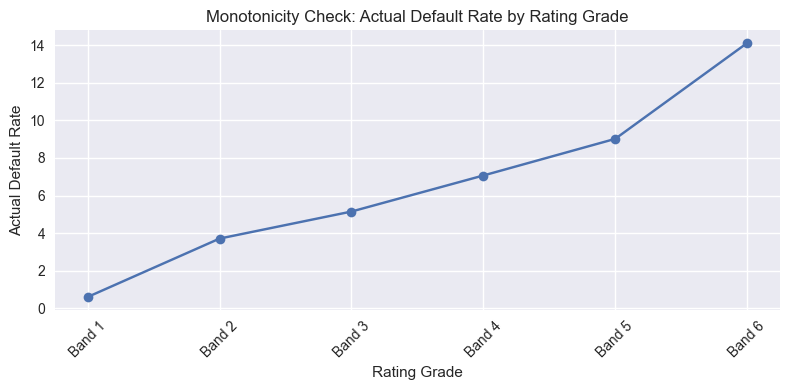

In [994]:
plot_monotonicity(rating_table)

In [996]:
def plot_predicted_pd(bin_stats):
    x = bin_stats["Grade"]
    y = bin_stats["Calibrated_PD_Mean"]

    plt.figure(figsize=(8,4))
    plt.plot(x, y, marker="o")
    plt.title("Predicted PD (Mean) by Rating Grade")
    plt.xlabel("Rating Grade")
    plt.ylabel("Predicted PD (mean)")
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

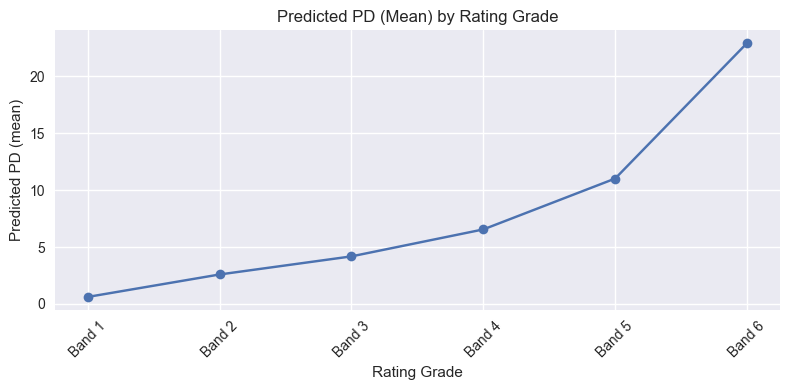

In [998]:
plot_predicted_pd(rating_table)

In [1047]:
def plot_rating_analysis(bin_stats):
     
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    
     
    x = bin_stats["Grade"]
    y_actual = bin_stats["Actual_Default_Rate"]
    ax1.plot(x, y_actual, marker="o", linewidth=2, markersize=8, color='steelblue')
    ax1.set_title("Monotonicity Check: Actual Default Rate by Rating Grade", fontsize=12, fontweight='bold')
    ax1.set_xlabel("Rating Grade", fontsize=11)
    ax1.set_ylabel("Actual Default Rate", fontsize=11)
    ax1.grid(True, alpha=0.3)
    ax1.tick_params(axis='x', rotation=45)
    
    
    y_predicted = bin_stats["Calibrated_PD_Mean"]
    ax2.plot(x, y_predicted, marker="o", linewidth=2, markersize=8, color='darkorange')
    ax2.set_title("Predicted PD (Mean) by Rating Grade", fontsize=12, fontweight='bold')
    ax2.set_xlabel("Rating Grade", fontsize=11)
    ax2.set_ylabel("Predicted PD (mean)", fontsize=11)
    ax2.grid(True, alpha=0.3)
    ax2.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

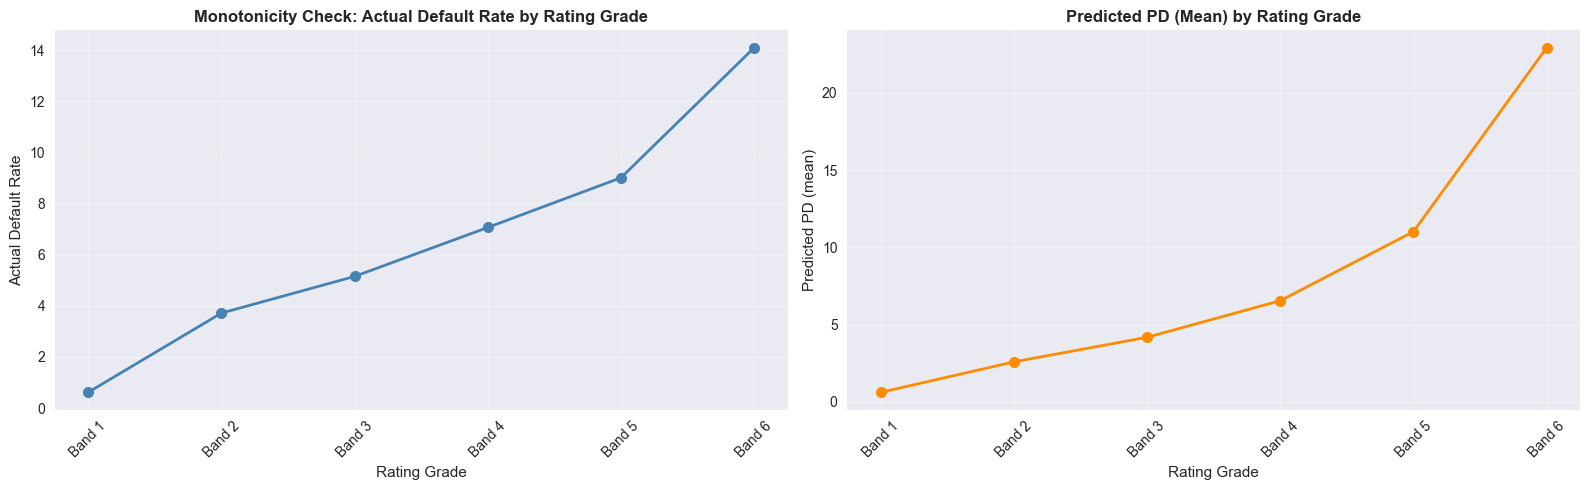

In [1049]:
plot_rating_analysis(rating_table)

In [1028]:
def plot_bin_composition(bin_stats):
    x = bin_stats["Grade"]
    total = bin_stats["Total"]
    defaults = bin_stats["Number_of_Defaults"]

    plt.figure(figsize=(8,4))
    plt.bar(x, total, alpha=0.6, color='steelblue',edgecolor='gray',label="Total")
    plt.bar(x, defaults, alpha=0.8, color='darkorange', edgecolor='firebrick',label="Number of Defaults")
    plt.title("Bin Composition")
    plt.xlabel("Rating Grade")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

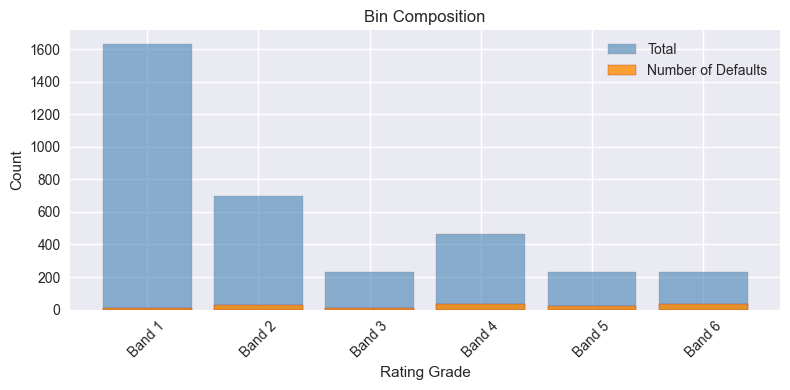

In [1030]:
plot_bin_composition(rating_table)

In [1038]:
def plot_lift_curve(df):
    df_sorted = df.sort_values("pred_PD")
    df_sorted["cum_defaults"] = df_sorted["defaults"].cumsum()
    df_sorted["cum_total"] = df_sorted["defaults"].sum()
    df_sorted["lift"] = df_sorted["cum_defaults"] / df_sorted["cum_total"]

    plt.figure(figsize=(8,4))
    plt.plot(df_sorted["pred_PD"], df_sorted["lift"], marker=".")
    plt.title("Lift Curve")
    plt.xlabel("Predicted PD")
    plt.ylabel("Cumulative Share of Defaults")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

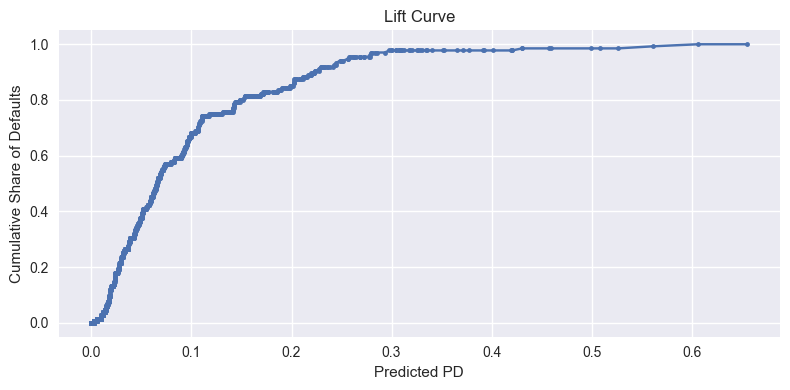

In [1040]:
plot_lift_curve(original_df)

In [1042]:
def plot_calibration(bin_stats):
    x = bin_stats["Calibrated_PD_Mean"]
    y = bin_stats["Actual_Default_Rate"]

    plt.figure(figsize=(6,6))
    plt.scatter(x, y)
    plt.plot([0, max(x)], [0, max(x)], linestyle="--") 
    plt.title("Calibration Plot")
    plt.xlabel("Predicted PD (mean)")
    plt.ylabel("Actual Default Rate")
    plt.grid(True)
    plt.tight_layout()
    plt.show()

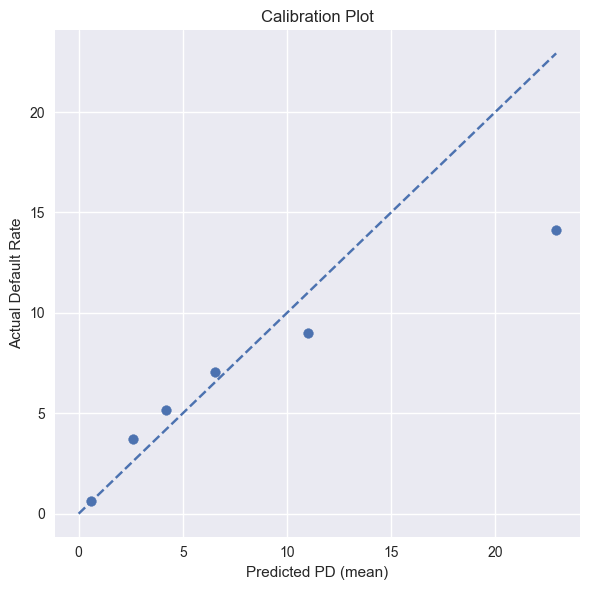

In [1044]:
plot_calibration(rating_table)

In [1848]:
print(rating_table)

    Grade             PD_Range  Total  Pct_of_Total  Number_of_Defaults  \
0  Band 1  (-0.00100, 0.01690]   1633         46.66                  10   
1  Band 2   (0.01690, 0.03660]    700         20.00                  26   
2  Band 3   (0.03660, 0.04710]    233          6.66                  12   
3  Band 4   (0.04710, 0.09010]    467         13.34                  33   
4  Band 5   (0.09010, 0.14100]    233          6.66                  21   
5  Band 6   (0.14100, 0.65600]    234          6.69                  33   

   Calibrated_PD_Mean  Actual_Default_Rate  
0               0.614                0.612  
1               2.588                3.714  
2               4.179                5.150  
3               6.548                7.066  
4              11.020                9.013  
5              22.924               14.103  


In [ ]:
# dataframe : rating_table: columns: 'Grade','PD_Range', 'Total', 'Number_of_Defaults', 'Calibrated_PD_Mean', 'Actual_Defaut_Rate', 
# dataframe :  band_stats: columns 'PD_min', 'PD_max', 'actual_default_rate',

In [1860]:
from scipy import stats
from scipy.stats import binomtest, chi2, norm

In [1870]:

def binomial_test_by_band(df, CI_method = 'wilson'):
    results = []

    for index, row in df.iterrows():
        predicted_PD = row['Calibrated_PD_Mean'] / 100
        actual_PD = row['Actual_Default_Rate'] / 100
        
        n_obs = row['Total']
        n_defaults = row['Number_of_Defaults']

        test_result = binomtest(
            n_defaults,
            n_obs,
            predicted_PD,
            alternative = 'two-sided'
        )

        p_value = test_result.pvalue

        if CI_method == 'wilson':
            CI_lower, CI_upper = wilson_score_interval(n_defaults, n_obs)
            
        elif CI_method == 'clopper-pearson':
            CI_lower, CI_upper = clopper_pearson_interval(n_defaults, n_obs)

        predicted_in_CI = (CI_lower <= predicted_PD <= CI_upper)

        results.append({
            'Band': row['Grade'],
            'PD_Range' : row['PD_Range'],
            'N_Obs': n_obs,
            'N_Defaults': n_defaults,
            'Calibrated_PD_Mean' : predicted_PD,
            'Actual_Default_Rate' : actual_PD,
            'Difference': actual_PD - predicted_PD,
            'Relative_Diff_%': np.nan if predicted_PD == 0 else ((actual_PD - predicted_PD) / predicted_PD * 100),
            'CI_Lower' : CI_lower,
            'CI_Upper': CI_upper,
            'CI_Width': CI_upper - CI_lower,
            'Predicted_in_CI' : 'Yes' if predicted_in_CI else 'No',
            'P_value': p_value,
            'Significant_5%' : 'Yes' if p_value < 0.05 else 'No'

        })

    df_results = pd.DataFrame(results)

    return df_results

def wilson_score_interval(n_defaults, n_obs, alpha = 0.05):
    z = stats.norm.ppf(1 - alpha/2)
    p_hat = n_defaults / n_obs

    denominator = 1 + z**2 / n_obs
    center = (p_hat + z**2 / (2 * n_obs)) / denominator
    margin = z * np.sqrt((p_hat * (1 - p_hat) / n_obs + z**2 / (4 * n_obs**2))) / denominator
    
    return (max(0, center - margin), min(1, center + margin))
    
def clopper_pearson_interval(n_defaults, n_obs, alpha = 0.05):
    lower = stats.beta.ppf(alpha/2, n_defaults, n_obs - n_defaults + 1) if n_defaults > 0 else 0
    upper = stats.beta.ppf(1 - alpha/2, n_defaults + 1, n_obs - n_defaults) if n_defaults < n_obs else 1
    
    return (lower, upper)

In [1872]:
binomial_results_wilson = binomial_test_by_band(rating_table, CI_method='wilson')

In [1876]:
print(binomial_results_wilson)

     Band             PD_Range  N_Obs  N_Defaults  Calibrated_PD_Mean  \
0  Band 1  (-0.00100, 0.01690]   1633          10             0.00614   
1  Band 2   (0.01690, 0.03660]    700          26             0.02588   
2  Band 3   (0.03660, 0.04710]    233          12             0.04179   
3  Band 4   (0.04710, 0.09010]    467          33             0.06548   
4  Band 5   (0.09010, 0.14100]    233          21             0.11020   
5  Band 6   (0.14100, 0.65600]    234          33             0.22924   

   Actual_Default_Rate  Difference  Relative_Diff_%  CI_Lower  CI_Upper  \
0              0.00612    -0.00002        -0.325733  0.003330  0.011236   
1              0.03714     0.01126        43.508501  0.025471  0.053867   
2              0.05150     0.00971        23.235224  0.029704  0.087850   
3              0.07066     0.00518         7.910812  0.050756  0.097577   
4              0.09013    -0.02007       -18.212341  0.059705  0.133848   
5              0.14103    -0.08821    

In [1878]:
binomial_results_clopper = binomial_test_by_band(rating_table, CI_method='clopper-pearson')

In [1880]:
print(binomial_results_clopper)

     Band             PD_Range  N_Obs  N_Defaults  Calibrated_PD_Mean  \
0  Band 1  (-0.00100, 0.01690]   1633          10             0.00614   
1  Band 2   (0.01690, 0.03660]    700          26             0.02588   
2  Band 3   (0.03660, 0.04710]    233          12             0.04179   
3  Band 4   (0.04710, 0.09010]    467          33             0.06548   
4  Band 5   (0.09010, 0.14100]    233          21             0.11020   
5  Band 6   (0.14100, 0.65600]    234          33             0.22924   

   Actual_Default_Rate  Difference  Relative_Diff_%  CI_Lower  CI_Upper  \
0              0.00612    -0.00002        -0.325733  0.002940  0.011233   
1              0.03714     0.01126        43.508501  0.024404  0.053951   
2              0.05150     0.00971        23.235224  0.026892  0.088235   
3              0.07066     0.00518         7.910812  0.049138  0.097810   
4              0.09013    -0.02007       -18.212341  0.056659  0.134470   
5              0.14103    -0.08821    

In [1898]:
def chi_square_test(df):
    predicted_PD = df['Calibrated_PD_Mean'].values
    actual_PD = df['Actual_Default_Rate'].values

    n_obs = df['Total'].values
    n_defaults_actual = df['Number_of_Defaults'].values

    n_defaults_predicted = (n_obs * predicted_PD).astype(int)
    n_nondefaults_actual = n_obs - n_defaults_actual
    n_nondefaults_predicted = n_obs - n_defaults_predicted

    epsilon = 1e-10

    variance = n_obs * predicted_PD * (1 - predicted_PD)
    variance_safe = np.where(variance > 0, variance, epsilon)

    HL_stats = np.sum((n_defaults_actual - n_defaults_predicted)**2 / variance_safe)
    degree_freedom_HL = len(df) - 2
    pvalue_HL = 1 - stats.chi2.cdf(HL_stats, degree_freedom_HL) if degree_freedom_HL > 0 else np.nan

    chi2_pearson = (np.sum((n_defaults_actual - n_defaults_predicted)**2 / n_defaults_predicted) + np.sum((n_nondefaults_actual - n_nondefaults_predicted)**2 / n_nondefaults_predicted))

    degree_freedom_pearson = len(df) - 1
    pvalue_pearson = 1 - stats.chi2.cdf(chi2_pearson, degree_freedom_pearson)

    chi2_gof = np.sum((n_defaults_actual - n_defaults_predicted)**2 / n_defaults_predicted)
    degree_freedom_gof = len(df) - 1
    pvalue_gof = 1 - stats.chi2.cdf(chi2_gof, degree_freedom_gof)

    results = {
        'hosmer_lemeshow ': {
            'chi2_statistic': HL_stats,
            'p_value': pvalue_HL,
            'degrees_of_freedom': degree_freedom_HL
            
        },
        'pearson chi_square (Contingency Table: Defaults + Non-Defaults)': {
            'chi2_statistic': chi2_pearson,
            'p_value': pvalue_pearson,
            'degrees_of_freedom': degree_freedom_pearson
            
        },
        'goodness_of_fit (Defaults Only)': {
            'chi2_statistic': chi2_gof,
            'p_value': pvalue_gof,
            'degrees_of_freedom': degree_freedom_gof
         
        }

    }

    return results

In [1900]:
chi_square_results = chi_square_test(rating_table)

In [1902]:
print(chi_square_results)

{'hosmer_lemeshow ': {'chi2_statistic': 4.8155999000000256e+17, 'p_value': 0.0, 'degrees_of_freedom': 4}, 'pearson chi_square (Contingency Table: Defaults + Non-Defaults)': {'chi2_statistic': 101.13640594300341, 'p_value': 0.0, 'degrees_of_freedom': 5}, 'goodness_of_fit (Defaults Only)': {'chi2_statistic': 14505.352118326722, 'p_value': 0.0, 'degrees_of_freedom': 5}}


In [1944]:
def chi_square_test(df):
    predicted_PD = df['Calibrated_PD_Mean'] / 100
    predicted_PD = predicted_PD.values
    actual_PD = df['Actual_Default_Rate'] / 100
    actual_PD = actual_PD.values

    n_obs = df['Total'].values
    n_defaults_actual = df['Number_of_Defaults'].values

    n_defaults_predicted = (n_obs * predicted_PD)
    n_nondefaults_actual = n_obs - n_defaults_actual
    n_nondefaults_predicted = n_obs - n_defaults_predicted

    

    chi2_pearson = (np.sum((n_defaults_actual - n_defaults_predicted)**2 / n_defaults_predicted) + np.sum((n_nondefaults_actual - n_nondefaults_predicted)**2 / n_nondefaults_predicted))

    degree_freedom_pearson = len(df) - 1
    pvalue_pearson = 1 - stats.chi2.cdf(chi2_pearson, degree_freedom_pearson)

    

    results = {
            'pearson chi_square (Contingency Table: Defaults + Non-Defaults)': {
            'chi2_statistic': chi2_pearson,
            'p_value': pvalue_pearson,
            'degrees_of_freedom': degree_freedom_pearson
            
        }
        
    }

    return results

In [1946]:
chi_square_pearson = chi_square_test(rating_table)

In [1948]:
print(chi_square_pearson)

{'pearson chi_square (Contingency Table: Defaults + Non-Defaults)': {'chi2_statistic': 15.539370139285007, 'p_value': 0.00828997256879549, 'degrees_of_freedom': 5}}


In [1950]:
def traffic_light_OE (df):
    results_OE = []

    for index, row in df.iterrows():
        predicted_PD = row['Calibrated_PD_Mean'] / 100
       
        n_obs = row['Total']
        n_defaults_actual = row['Number_of_Defaults']
        n_defaults_predicted = n_obs * predicted_PD

        OE_ratio = n_defaults_actual / n_defaults_predicted

        if 0.8 <= OE_ratio <= 1.2:
            traffic_light = 'Green'
        elif 0.5 <= OE_ratio < 0.8 or 1.2 < OE_ratio <= 1.5:
            traffic_light = 'Amber'
        elif OE_ratio < 0.5 or OE_ratio > 1.5:
            traffic_light = 'Red'

        results_OE.append({
            'Band': row['Grade'],
            'O/E ratio' : OE_ratio,
            'Traffic Light': traffic_light
        })
    return pd.DataFrame(results_OE)



In [1928]:
def traffic_light_wilson(binomial_wilson):
    results_wilson = []
    for index, row in binomial_wilson.iterrows():

        pvalue_wilson = row['P_value']

        if pvalue_wilson >= 0.05:
            traffic_light = 'Green'
        elif 0.01 <= pvalue_wilson < 0.05:
            traffic_light = 'Amber'
        else:
            traffic_light = 'Red'

        results_wilson.append({
            'Band': row['Band'],
            'P_value_wilson' : pvalue_wilson,
            'Traffic Light': traffic_light
        })   

    return pd.DataFrame(results_wilson)



In [1930]:
wilson_light = traffic_light_wilson(binomial_results_wilson)

In [1932]:
print(wilson_light)

     Band  P_value_wilson Traffic Light
0  Band 1        1.000000         Green
1  Band 2        0.072388         Green
2  Band 3        0.412801         Green
3  Band 4        0.639486         Green
4  Band 5        0.401722         Green
5  Band 6        0.001030           Red


In [1962]:
def combine_traffic_lights(oe_df, pval_df):
    df = oe_df.merge(pval_df, on='Band')

    def final_light(row):
        if 'Red' in [row['OE_light'], row['Traffic Light']]:
            return 'Red'
        elif 'Amber' in [row['OE_light'], row['Traffic Light']]:
            return 'Amber'
        else:
            return 'Green'

    df['Final_Traffic_Light'] = df.apply(final_light, axis=1)
    return df

In [1964]:
combine_light = combine_traffic_lights(OE_light, wilson_light)

In [1966]:
print(combine_light)

     Band  OE_ratio OE_light  P_value_wilson Traffic Light Final_Traffic_Light
0  Band 1  0.997345    Green        1.000000         Green               Green
1  Band 2  1.435195    Amber        0.072388         Green               Amber
2  Band 3  1.232404    Amber        0.412801         Green               Amber
3  Band 4  1.079166    Green        0.639486         Green               Green
4  Band 5  0.817865    Green        0.401722         Green               Green
5  Band 6  0.615188    Amber        0.001030           Red                 Red


In [1952]:
OE_results = traffic_light_OE(rating_table)

In [1954]:
print(OE_results)

     Band  O/E ratio Traffic Light
0  Band 1   0.997345         Green
1  Band 2   1.435195         Amber
2  Band 3   1.232404         Amber
3  Band 4   1.079166         Green
4  Band 5   0.817865         Green
5  Band 6   0.615188         Amber


In [1956]:
def oe_traffic_light(df):
    rows = []

    for _, row in df.iterrows():
        predicted_PD = row['Calibrated_PD_Mean'] / 100
        n_obs = row['Total']
        n_defaults = row['Number_of_Defaults']

        if predicted_PD <= 0:
            oe = np.nan
            light = 'Red'
        else:
            oe = n_defaults / (n_obs * predicted_PD)

            if 0.8 <= oe <= 1.2:
                light = 'Green'
            elif 0.5 <= oe < 0.8 or 1.2 < oe <= 1.5:
                light = 'Amber'
            else:
                light = 'Red'

        rows.append({
            'Band': row['Grade'],
            'OE_ratio': oe,
            'OE_light': light
        })

    return pd.DataFrame(rows)

In [1958]:
OE_light = oe_traffic_light(rating_table)

In [1960]:
print(OE_light)

     Band  OE_ratio OE_light
0  Band 1  0.997345    Green
1  Band 2  1.435195    Amber
2  Band 3  1.232404    Amber
3  Band 4  1.079166    Green
4  Band 5  0.817865    Green
5  Band 6  0.615188    Amber


In [ ]:
'lgd', 'ead'

In [1068]:
df_2023['lgd'].describe()

count    3500.000000
mean        0.453516
std         0.151127
min         0.050000
25%         0.349890
50%         0.453375
75%         0.557918
max         0.950000
Name: lgd, dtype: float64

In [1070]:
df_2024['lgd'].describe()

count    3500.000000
mean        0.450385
std         0.148080
min         0.050000
25%         0.349908
50%         0.448031
75%         0.549864
max         0.950000
Name: lgd, dtype: float64

In [1248]:
LGD_data = df_2024['lgd']

In [1250]:
from scipy import stats

In [1258]:
from scipy.stats import kstest, anderson

In [1330]:
from scipy.stats import rankdata

In [1264]:
skew_LGD = stats.skew(LGD_data)
skew_LGD

0.02475978621771307

In [1266]:
kurtosis_LGD = stats.kurtosis(LGD_data)
kurtosis_LGD

-0.06568949509366284

In [1252]:
alpha, beta, loc, scale = stats.beta.fit(LGD_data, floc = 0, fscale = 1)

In [1254]:
print(alpha)

4.425693635284175


In [1256]:
print(beta)

5.415938743853487


In [1260]:
ks_stat, p_value = stats.kstest(LGD_data, 'beta', args = (alpha, beta, 0, 1))

In [1262]:
print(p_value)

0.02475583910746504


In [ ]:
# p value < 0.05
# consider that parametric core + empirical residuals

In [1344]:
LGD_params = stats.beta.fit(LGD_data, floc = 0, fscale = 1)
x = np.linspace(0, 1, 100)
beta_pdf = stats.beta.pdf(x, *LGD_params)

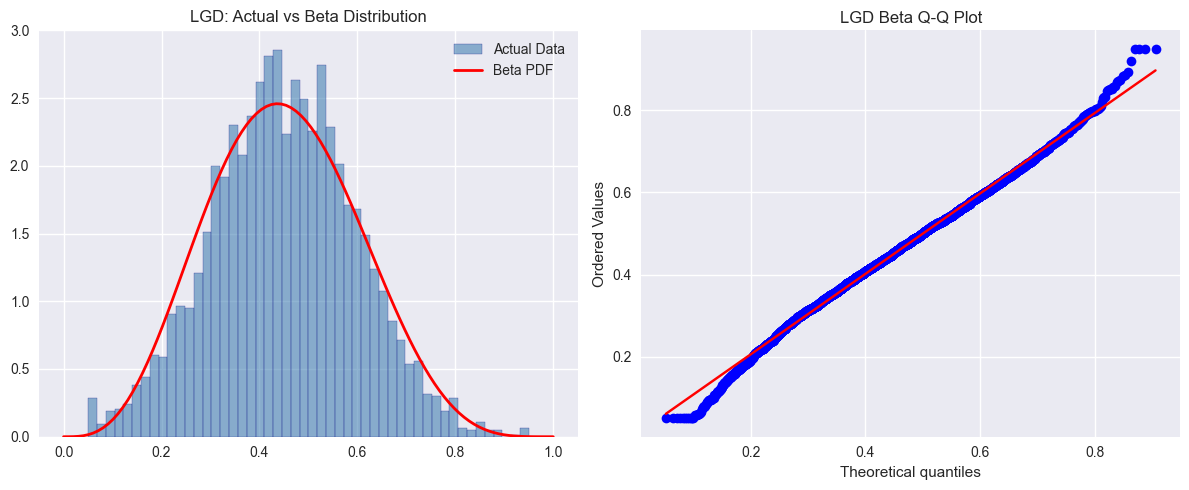

In [1430]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(LGD_data, bins=50, density=True, alpha=0.6, color='steelblue', edgecolor= 'navy', label='Actual Data')
axes[0].plot(x, beta_pdf, 'r-',lw=2, label='Beta PDF')
axes[0].set_title('LGD: Actual vs Beta Distribution')
axes[0].legend()

stats.probplot(LGD_data, dist=stats.beta(alpha, beta), plot=axes[1])
axes[1].set_title('LGD Beta Q-Q Plot')

plt.tight_layout()
plt.show()

In [1350]:
LGD_ranks = rankdata(LGD_data)/len(LGD_data) 
LGD_quantiles  = stats.beta.ppf(LGD_ranks, alpha, beta)

In [1362]:
LGD_sorted = np.sort(LGD_data)
for i, val in enumerate(LGD_sorted):
    p = (i +0.5)/len(LGD_data)
    LGD_fitted02 = stats.beta.ppf(p, alpha, beta)
#PPF = percent point function = inverse CDF

In [1366]:
from statsmodels.distributions.empirical_distribution import ECDF

In [1368]:
Ecdf_historical = ECDF(LGD_sorted)

In [1370]:
Ecdf_parametric = ECDF(base_percentiles)

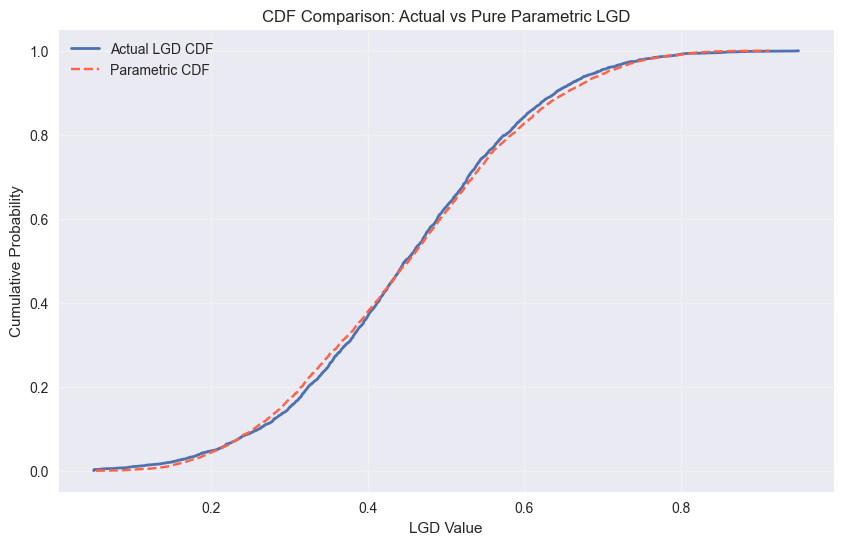

In [1402]:
plt.figure(figsize=(10, 6))
plt.plot(Ecdf_historical.x, Ecdf_historical.y, label='Actual LGD CDF', linewidth=2)
plt.plot(Ecdf_parametric.x, Ecdf_parametric.y, label='Parametric CDF', color='tomato', linestyle="--")
plt.xlabel('LGD Value')
plt.ylabel('Cumulative Probability')
plt.title('CDF Comparison: Actual vs Pure Parametric LGD')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [1304]:
LGD_base = stats.beta.rvs(alpha, beta, size = 5000)

In [1320]:
LGD_base_sorted = np.sort(LGD_base)
percentiles = np.linspace(0, 100, len(LGD_sorted))
base_percentiles = np.percentile(LGD_base_sorted, percentiles)

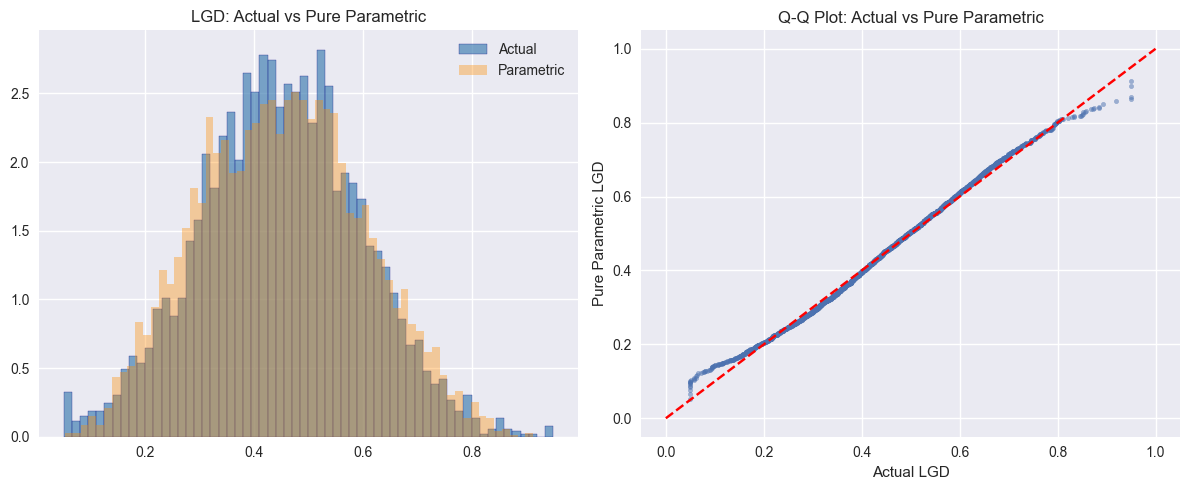

In [1406]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].hist(LGD_data, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor = 'navy',label='Actual')
axes[0].hist(LGD_base, bins=60, density=True, alpha=0.36, color='darkorange', label='Parametric')
axes[0].set_title('LGD: Actual vs Pure Parametric')

axes[1].scatter(LGD_sorted, base_percentiles, alpha=0.5, s=10)
axes[1].plot([0, 1], [0, 1], 'r--', label='Perfect fit')
axes[1].set_xlabel('Actual LGD')
axes[1].set_ylabel('Pure Parametric LGD')
axes[1].set_title('Q-Q Plot: Actual vs Pure Parametric')

axes[0].legend()


plt.tight_layout()
plt.show()

In [ ]:
#alpha, beta, loc, scale = stats.beta.fit(LGD_data, floc = 0, fscale = 1)
#LGD_params = stats.beta.fit(LGD_data, floc = 0, fscale = 1)
#LGD_sorted = np.sort(LGD_data)

#percentiles = np.linspace(0, 100, len(LGD_sorted))
#base_percentiles = np.percentile(LGD_base_sorted, percentiles)
#PPF = percent point function = inverse CDF

In [1410]:
def LGD_inverse_CDF_hybrid(data, u_lower = 0.075, u_upper = 0.925, n_simulations = 10000):
    rng = np.random.default_rng(42)
    u = rng.uniform(0, 1, n_simulations)
    LGD_simulations = np.empty_like(u)

    mask_low = u <= u_lower
    if mask_low.any():
        LGD_simulations[mask_low] = np.quantile(data, u[mask_low], interpolation="linear")
        
    mask_high = u >= u_upper
    if mask_high.any():
        LGD_simulations[mask_high] = np.quantile(data, u[mask_high], interpolation="linear")
        
    mask_mid = (~mask_low) & (~mask_high)
    if mask_mid.any():
        LGD_simulations[mask_mid] = stats.beta.ppf(u[mask_mid], alpha, beta)
  
    return LGD_simulations

In [1412]:
LGD_simulations = LGD_inverse_CDF_hybrid(
        data = LGD_sorted,
        u_lower = 0.075,
        u_upper = 0.925,
        n_simulations = 10000
    )

In [1414]:
print(LGD_simulations.mean(), LGD_simulations.min(), LGD_simulations.max())

0.44717726884031733 0.05 0.95


In [1420]:
percentiles = np.linspace(0, 100, len(LGD_sorted))
base_percentiles = np.percentile(LGD_base_sorted, percentiles)
simulated_percentiles = np.percentile(LGD_simulations, percentiles)

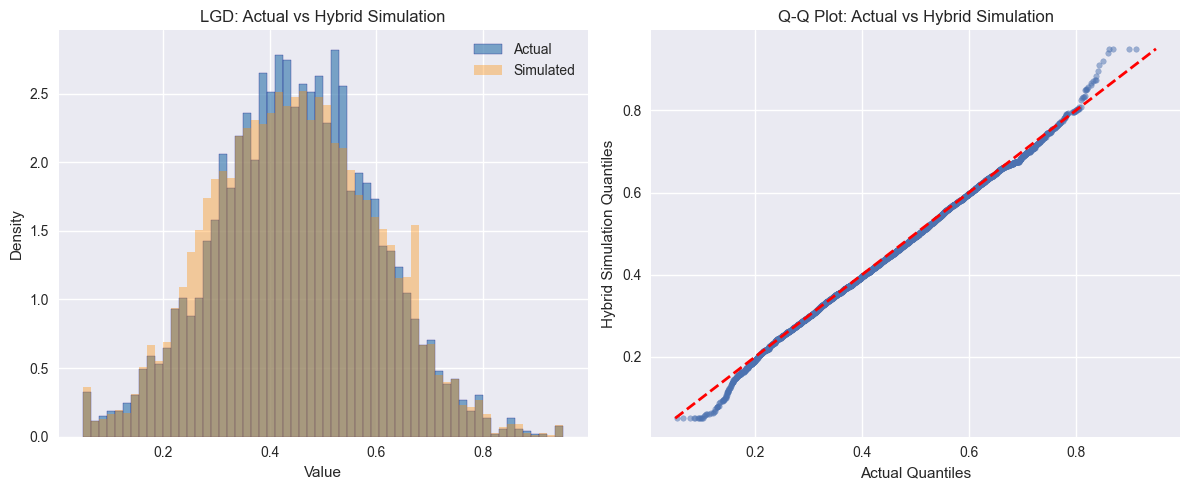

In [1428]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(LGD_data, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor = 'navy',label='Actual')
axes[0].hist(LGD_simulations, bins=60, density=True, alpha=0.36, color='darkorange', label='Simulated')
axes[0].set_title('LGD: Actual vs Hybrid Simulation')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].legend()

sorted_simulations = np.sort(LGD_simulations)

step = max(1, len(LGD_sorted) // 100)
        
axes[1].scatter(base_percentiles, simulated_percentiles, alpha=0.5, s=16)
min_val = min(base_percentiles.min(), simulated_percentiles.min())
max_val = max(base_percentiles.max(), simulated_percentiles.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Quantiles')
axes[1].set_ylabel('Hybrid Simulation Quantiles')
axes[1].set_title('Q-Q Plot: Actual vs Hybrid Simulation')






plt.tight_layout()
plt.show()

In [1489]:
percentiles = np.linspace(0, 100, len(LGD_sorted))
actual_percentiles = np.percentile(LGD_sorted, percentiles)
simulated_percentiles = np.percentile(LGD_simulations, percentiles)

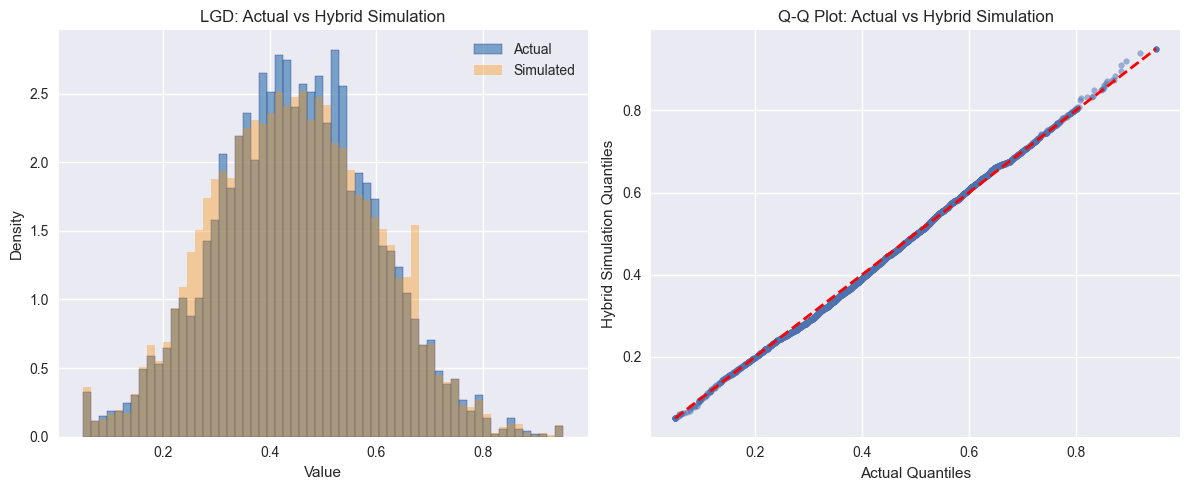

In [1491]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(LGD_data, bins=60, density=True, alpha=0.7, color='steelblue', edgecolor = 'navy',label='Actual')
axes[0].hist(LGD_simulations, bins=60, density=True, alpha=0.36, color='darkorange', label='Simulated')
axes[0].set_title('LGD: Actual vs Hybrid Simulation')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].legend()

#sorted_simulations = np.sort(LGD_simulations)

#step = max(1, len(LGD_sorted) // 100)
        
axes[1].scatter(actual_percentiles, simulated_percentiles, alpha=0.5, s=16)
min_val = min(actual_percentiles.min(), simulated_percentiles.min())
max_val = max(actual_percentiles.max(), simulated_percentiles.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Quantiles')
axes[1].set_ylabel('Hybrid Simulation Quantiles')
axes[1].set_title('Q-Q Plot: Actual vs Hybrid Simulation')






plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Higher-tail Q–Q')

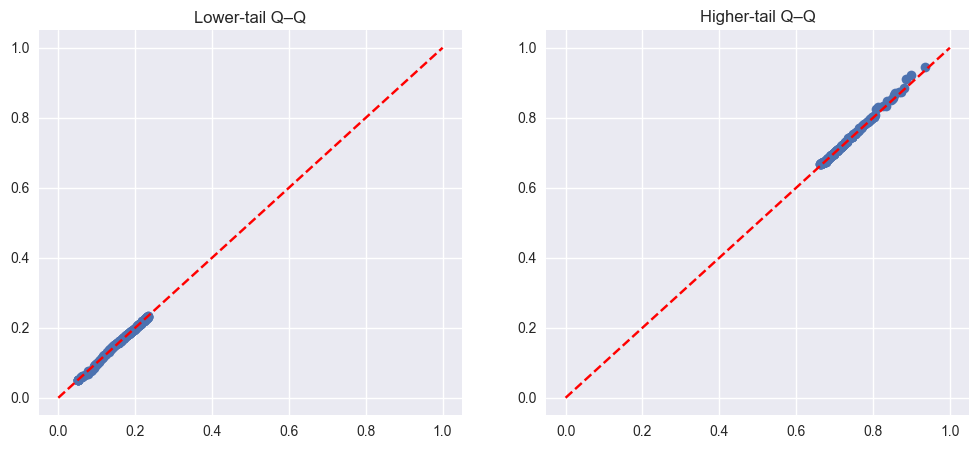

In [1432]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

p_lower = np.linspace(0.001, 0.075, 200)
axes[0].plot(np.quantile(LGD_sorted, p_lower), np.quantile(sorted_simulations, p_lower), 'o')
axes[0].plot([0,1], [0,1], 'r--')
axes[0].set_title("Lower-tail Q–Q")

p_higher = np.linspace(0.925, 0.999, 200)
axes[1].plot(np.quantile(LGD_sorted, p_higher), np.quantile(sorted_simulations, p_higher), 'o')
axes[1].plot([0,1], [0,1], 'r--')
axes[1].set_title("Higher-tail Q–Q")



In [1434]:
from scipy.special import logit, expit

In [1438]:
def maturity_effect(LGD_sim, horizon, gamma = 0.035):
    z = logit(np.clip(LGD_sim, 1e-06, 1 - 1e-06))
    delta = gamma * np.log1p(horizon)
    z_t = z + delta
    LGD_sim_t = expit(z_t)
    return LGD_sim_t

In [1442]:
def lifetime_LGD (LGD_sim, horizons = 5, gamma = 0.035):
    LGD_horizon = {}
    
    for h in range(1, horizons + 1):
        if h == 1:
            LGD_horizon[h] = LGD_sim
        else:
            LGD_horizon[h] = maturity_effect(LGD_sim, horizon = h, gamma = gamma)
    return LGD_horizon
            

In [1444]:
LGD_lifetime = lifetime_LGD (LGD_simulations, horizons = 5, gamma = 0.035)

In [1446]:
for h, LGD in LGD_lifetime.items():
    print(h, LGD.mean())

1 0.44717726884031733
2 0.4558036835288339
3 0.4580667204853592
4 0.4598231371139486
5 0.461258895981825


In [1454]:
print(LGD_lifetime)

{1: array([0.5686716922, 0.4212639016, 0.6197463597, ..., 0.2955785486,
       0.3942408698, 0.4383802279]), 2: array([0.578077226 , 0.4306656901, 0.6287652171, ..., 0.3036470192,
       0.4034600029, 0.4478683974]), 3: array([0.5805311139, 0.4331362085, 0.6311124255, ..., 0.3057802365,
       0.4058857169, 0.4503595379]), 4: array([0.5824317649, 0.4350547899, 0.6329288044, ..., 0.3074406484,
       0.4077704214, 0.4522935387]), 5: array([0.5839828967, 0.4366238331, 0.6344100993, ..., 0.3088010178,
       0.4093123565, 0.4538748052])}


In [1473]:
def lifetime_LGD_long (LGD_sim, horizons = 5, gamma = 0.035):
    LGD_horizon = {}
    
    for h in range(1, horizons + 1):
        if h == 1:
            LGD_horizon[h] = LGD_sim
        else:
            LGD_horizon[h] = maturity_effect(LGD_sim, horizon = h, gamma = gamma)

    LGD_long = pd.DataFrame(LGD_horizon).stack().reset_index()
    LGD_long.columns = ['index', 'horizon', 'LGD']
    #LGD_long = LGD_long.sort_values('horizon').reset_index(drop=True)
    return LGD_long

In [1475]:
LGD_long = lifetime_LGD_long(LGD_simulations, horizons = 5, gamma = 0.035)

In [1477]:
LGD_long.head()

,index,horizon,LGD
0,0,1,0.568672
1,0,2,0.578077
2,0,3,0.580531
3,0,4,0.582432
4,0,5,0.583983


In [1479]:
LGD_long.tail()

,index,horizon,LGD
49995,9999,1,0.438380
49996,9999,2,0.447868
49997,9999,3,0.450360
49998,9999,4,0.452294
49999,9999,5,0.453875


In [1671]:
LGD_disp = (
    LGD_long
    .groupby("horizon")["LGD"]
    .agg(std="std", p95=lambda x: np.quantile(x, 0.95))
)

In [1673]:
print(LGD_disp)

              std       p95
horizon                    
1        0.152373  0.693083
2        0.152882  0.701201
3        0.153003  0.703307
4        0.153094  0.704934
5        0.153166  0.706259


In [1675]:
LGD_disp_05 = (
    LGD_long
    .groupby("horizon")["LGD"]
    .agg(std="std", p05=lambda x: np.quantile(x, 0.05))
)

In [1677]:
print(LGD_disp_05)

              std       p05
horizon                    
1        0.152373  0.204484
2        0.152882  0.210810
3        0.153003  0.212490
4        0.153094  0.213800
5        0.153166  0.214875


In [1072]:
df_2023['ead'].describe()

count    3.500000e+03
mean     1.925161e+06
std      3.038560e+06
min      2.111715e+04
25%      5.288423e+05
50%      1.060765e+06
75%      2.196397e+06
max      8.971203e+07
Name: ead, dtype: float64

In [1074]:
df_2024['ead'].describe()

count    3.500000e+03
mean     1.895880e+06
std      2.761872e+06
min      1.786281e+04
25%      4.732113e+05
50%      1.033688e+06
75%      2.241704e+06
max      3.721187e+07
Name: ead, dtype: float64

In [1268]:
EAD_data = df_2024['ead']

In [1286]:
from scipy.stats import kendalltau, spearmanr
from scipy.stats import norm, lognorm

In [1272]:
pearson_corr, pearson_p = stats.pearsonr(LGD_data, EAD_data)

In [1276]:
spearman_corr, spearman_p = spearmanr(LGD_data, EAD_data)

In [1278]:
kendall_corr, kendall_p = kendalltau(LGD_data, EAD_data)

In [1280]:
print(pearson_corr)

-0.008568289386694034


In [1282]:
print(spearman_corr)

-0.004062326305559497


In [ ]:
# abstract value of spearman_corr < 0.1 , skip copula (negligible correlation)

In [1448]:
df_2024_renew.groupby("rating_band")[["PD_12m", "lgd"]].mean().corr(method="spearman")

,PD_12m,lgd
PD_12m,1.000000,-0.314286
lgd,-0.314286,1.000000


In [1723]:
df_2024_renew.groupby("rating_band")[["PD_12m", "ead"]].mean().corr(method="spearman")

,PD_12m,ead
PD_12m,1.000000,0.028571
ead,0.028571,1.000000


In [1481]:
shape, loc, scale = stats.lognorm.fit(EAD_data, floc = 0)
print(shape)
print(scale)

1.1330469353947306
1017651.4046162078


In [ ]:
# shape: std. of log(EAD)
# scale: expectation of mu
# log(EAD) ~ N(log(scale), shape^2)

In [1507]:
EAD_simulation = stats.lognorm.rvs(s=shape, loc=0, scale=scale, size = 10000)

In [ ]:
# loc: horizontal shift

In [1485]:
log_EAD = np.log(EAD_data)
shapiro_stat, shapiro_p =stats.shapiro(log_EAD)
print(shapiro_p)

0.29375449460902175


In [ ]:
# shapiro-wilk test for lognormality
# p_value > 0.05 log-normal distribution likely, parametric

In [1543]:
ks_stat, p_value = stats.ks_2samp(EAD_data, EAD_simulation)
print(p_value)

0.7836924681455695


In [1501]:
EAD_data.describe()

count    3.500000e+03
mean     1.895880e+06
std      2.761872e+06
min      1.786281e+04
25%      4.732113e+05
50%      1.033688e+06
75%      2.241704e+06
max      3.721187e+07
Name: ead, dtype: float64

In [1513]:
pd.Series(EAD_simulation).describe()

count    1.000000e+04
mean     1.982295e+06
std      3.751550e+06
min      2.728580e+04
25%      4.647747e+05
50%      1.013055e+06
75%      2.168628e+06
max      1.223869e+08
dtype: float64

In [1527]:
EAD_sim_sorted = np.sort(EAD_simulation)
EAD_sorted = np.sort(EAD_data)
EAD_percentiles = np.linspace(1, 99, 1000)
EAD_actual_percentiles = np.percentile(EAD_data, EAD_percentiles)
EAD_sim_percentiles = np.percentile(EAD_simulation, EAD_percentiles)

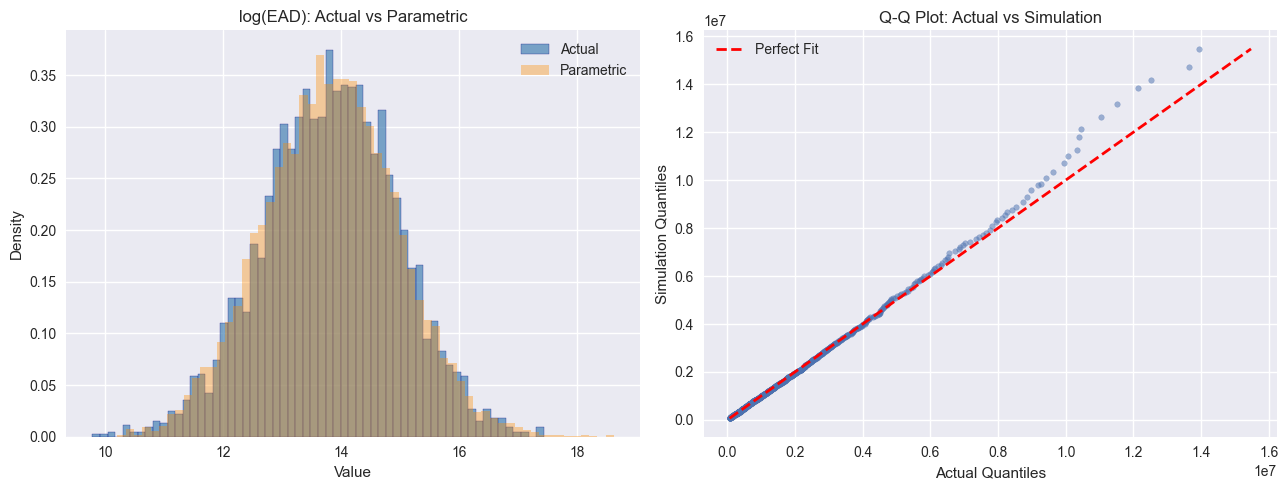

In [1541]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(np.log(EAD_data), bins=60, density=True, alpha=0.7, color='steelblue', edgecolor = 'navy',label='Actual')
axes[0].hist(np.log(EAD_simulation), bins=60, density=True, alpha=0.36, color='darkorange', label='Parametric')
axes[0].set_title('log(EAD): Actual vs Parametric')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Density')
axes[0].legend()


        
axes[1].scatter(EAD_actual_percentiles, EAD_sim_percentiles, alpha=0.5, s=16)
min_val = min(EAD_actual_percentiles.min(), EAD_sim_percentiles.min())
max_val = max(EAD_actual_percentiles.max(), EAD_sim_percentiles.max())
axes[1].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Fit')
axes[1].set_xlabel('Actual Quantiles')
axes[1].set_ylabel('Simulation Quantiles')
axes[1].set_title('Q-Q Plot: Actual vs Simulation')
axes[1].legend()





plt.tight_layout()
plt.show()

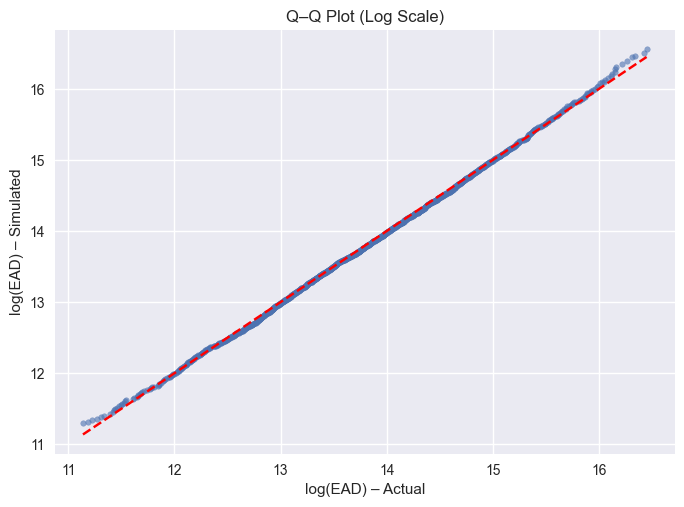

In [1561]:
percentiles02 = np.linspace(1, 99, 1000)

q_actual = np.percentile(np.log(EAD_data), percentiles02)
q_sim    = np.percentile(np.log(EAD_simulation), percentiles02)

plt.scatter(q_actual, q_sim, s=16, alpha=0.6)
plt.plot([q_actual.min(), q_actual.max()],
         [q_actual.min(), q_actual.max()],
         'r--')
plt.xlabel('log(EAD) – Actual')
plt.ylabel('log(EAD) – Simulated')
plt.title('Q–Q Plot (Log Scale)')
plt.show()

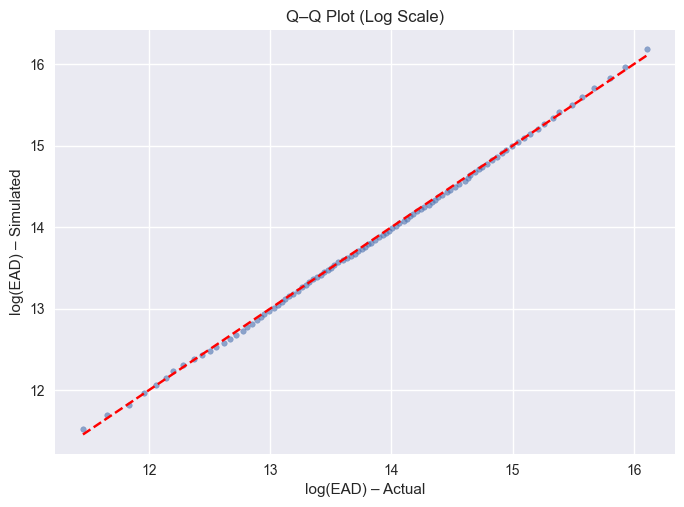

In [1559]:
percentiles02 = np.linspace(2, 98, 98)

q_actual = np.percentile(np.log(EAD_data), percentiles02)
q_sim    = np.percentile(np.log(EAD_simulation), percentiles02)

plt.scatter(q_actual, q_sim, s=16, alpha=0.6)
plt.plot([q_actual.min(), q_actual.max()],
         [q_actual.min(), q_actual.max()],
         'r--')
plt.xlabel('log(EAD) – Actual')
plt.ylabel('log(EAD) – Simulated')
plt.title('Q–Q Plot (Log Scale)')
plt.show()

In [1569]:
df_2024_renew['log_EAD'] = np.log(df_2024_renew['ead'])
rating_means = (
    df_2024_renew.groupby('rating_band')['log_EAD']
    .mean()
)

In [1571]:
print(rating_means)

rating_band
(-9.99999999666443e-11, 0.01687638315]    13.836482
(0.01687638315, 0.03649970447]            13.885815
(0.03649970447, 0.04704047889]            13.803881
(0.04704047889, 0.09008669949]            13.794645
(0.09008669949, 0.1403881688]             13.751281
(0.1403881688, 0.655516867]               13.837737
Name: log_EAD, dtype: float64


In [1573]:
print(df_2024_renew.columns.tolist())

['firm_id', 'year', 'total_assets', 'debt_assets', 'roa', 'current_ratio', 'interest_coverage', 'revenue_growth', 'volatility', 'pd', 'default', 'lgd', 'ead', 'PD_12m', 'ECL_12m', 'rating_band', 'ECL_Rate', 'log_EAD']


In [1575]:
df_EAD_cal = df_2024_renew.copy()

In [1728]:
class EADprojections:

    def __init__(self, df, horizon = 5, sim_size = 1000, seed = 42):
        self.horizon = horizon
        self.df_ECL = df.copy()
        self.sim_size = sim_size
        self.rng = np.random.default_rng(seed)

    def _residuals_bootstrapped(self):
        
       
        log_EAD = self.df_ECL['log_EAD']

        #shape, loc, scale = stats.lognorm.fit(EAD_data, floc = 0)

        #EAD_simulation = stats.lognorm.rvs(s=shape, loc=0, scale=scale, size = 10000)

        residuals = log_EAD - log_EAD.mean()

        return residuals.values
    
    def _grades_maps(self):

        df_Grades = self.df_ECL.copy()

        def map_grade(interval):
            upper = interval.right
            if upper <= 0.017:
                return 'BB'
            elif upper <= 0.037:
                return 'B'
            elif upper <= 0.048:
                return 'B'
            elif upper <= 0.091:
                return 'B'
            elif upper <= 0.141: 
                return 'CCC/C'
            else:
                return 'CCC/C'

       
        df_Grades['SP_Grades'] = df_Grades['rating_band'].apply(map_grade)

        return df_Grades
    
    def _transition_matrix(self):

        Grades = ['BB', 'B', 'CCC/C', 'D']

        data = [
            [0.9152, 0.0725, 0.0058, 0.0065],
            [0.0512, 0.8605, 0.0548, 0.0335],
            [0.0047, 0.1555, 0.5317, 0.3081],
            [0.0000, 0.0000, 0.0000, 1.0000]
        ]

        SP_matrix_1Y = pd.DataFrame(data, index=Grades, columns=Grades)

        

        return Grades, SP_matrix_1Y
    
    def _rating_specific_drift(self):
        
        df = self._grades_maps()

        rating_means = (
            df.groupby('SP_Grades')['log_EAD']
            .mean()
        )

        rating_ref = 'BB'

        drift_ref = rating_means[rating_ref]

        drift_series = rating_means - drift_ref

        drift_map = drift_series.to_dict()
        #print(drift_map)

        return drift_map
    
    def _per_rating_simulation(self, initial_rating):

        df = self._grades_maps()
        EAD_data = df['ead']
        log_EAD = df['log_EAD']

        grades, transition_matrix = self._transition_matrix()

        grade_index = {g: i for i, g in enumerate(grades)}

        P = transition_matrix.loc[grades, grades].values

        drift_map = self._rating_specific_drift()
        drift_array = np.array([drift_map.get(g, 0.0) for g in grades])

        residulals = self._residuals_bootstrapped()
        
        EAD_mean = EAD_data.mean()
        amort_factor = np.array([1.0, 0.8, 0.6, 0.4, 0.2])
        EAD_base = EAD_mean * amort_factor
        log_EAD_base = np.log(EAD_base)

        rating_evolv = np.full((self.sim_size, self.horizon), grade_index[initial_rating])
       

        for h in range(1, self.horizon): 
            prev = rating_evolv[:, h-1]
            not_defaulted = (prev != 3)
            if not_defaulted.any():
                for g in range(len(grades)):
                    mask = (prev == g)
                    if mask.any():
                        rating_evolv[mask, h] = self.rng.choice(
                            len(grades),
                            size = mask.sum(),
                            p = P[g]
                        )
            rating_evolv[~not_defaulted, h] = 3

        drift_rating = drift_array[rating_evolv]

        epsilon = self.rng.choice(residulals, size = (self.sim_size, self.horizon))
                    

        log_EAD_result = log_EAD_base + drift_rating + epsilon
                    

        EAD_result = np.exp(log_EAD_result)
        EAD_result[rating_evolv == grade_index['D']] = 0.0

         

        EAD_rating = (
            df.groupby('SP_Grades')['ead']
            .sum()
        )

        weights_EAD = EAD_rating / df['ead'].sum()  

        return EAD_result, rating_evolv, weights_EAD

    def _EAD_summary(self, EAD):

        summary = {
            'mean': EAD.mean(axis = 0),
            'p05': np.quantile(EAD, 0.05, axis = 0),
            'p50': np.quantile(EAD, 0.50, axis = 0),
            'p95': np.quantile(EAD, 0.95, axis = 0),
        }
        return pd.DataFrame(summary, index = range(1, self.horizon +1 ))

#dataframe: df_EAD_cal: 'ead', 'rating_band', 'log_EAD'


In [1663]:
EADprojection = EADprojections(df=df_EAD_cal , horizon = 5, sim_size = 1000, seed = 42)

In [1665]:
EAD_result, rating_evolv, weights_EAD = EADprojection._per_rating_simulation(initial_rating = 'BB')

In [1667]:
df_bb = EADprojection._EAD_summary(EAD_result)

In [1669]:
print(weights_EAD)
print(df_bb)

SP_Grades
B        0.403834
BB       0.463355
CCC/C    0.132811
Name: ead, dtype: float64
           mean            p05           p50           p95
1  3.539707e+06  270542.803138  1.846039e+06  1.145059e+07
2  2.669475e+06  220807.251058  1.615288e+06  8.993322e+06
3  2.167391e+06  127273.332389  1.123809e+06  7.659632e+06
4  1.400873e+06   67733.474326  7.457185e+05  4.677942e+06
5  6.936465e+05       0.000000  3.467974e+05  2.407419e+06


In [1679]:
EAD_result, rating_evolv, weights_EAD = EADprojection._per_rating_simulation(initial_rating = 'B')

In [1681]:
df_b = EADprojection._EAD_summary(EAD_result)

In [1683]:
print(df_b)

           mean            p05           p50           p95
1  3.509639e+06  317073.814543  1.981933e+06  1.240534e+07
2  2.790983e+06  130783.464069  1.526238e+06  9.083520e+06
3  1.788357e+06       0.000000  9.885029e+05  6.392462e+06
4  1.205995e+06       0.000000  6.171372e+05  4.833713e+06
5  5.542098e+05       0.000000  2.816620e+05  2.005757e+06


In [1693]:
EAD_result, rating_evolv, weights_EAD = EADprojection._per_rating_simulation(initial_rating = 'CCC/C')

In [1695]:
df_c = EADprojection._EAD_summary(EAD_result)

In [1697]:
print(df_c)

           mean            p05           p50           p95
1  3.523346e+06  289227.916162  1.960448e+06  1.236141e+07
2  1.763507e+06       0.000000  6.673162e+05  7.256910e+06
3  9.843393e+05       0.000000  0.000000e+00  4.380213e+06
4  4.678786e+05       0.000000  0.000000e+00  2.419989e+06
5  2.492249e+05       0.000000  0.000000e+00  1.157442e+06


In [1730]:
EADcalculation = EADprojections(df=df_EAD_cal , horizon = 5, sim_size = 5000, seed = 42)

In [1732]:
EAD_result_bb, rating_evolv, weights_EAD = EADcalculation._per_rating_simulation(initial_rating = 'BB')

In [1734]:
EAD_result_b, rating_evolv, weights_EAD = EADcalculation._per_rating_simulation(initial_rating = 'B')

In [1736]:
EAD_result_c, rating_evolv, weights_EAD = EADcalculation._per_rating_simulation(initial_rating = 'CCC/C')

In [1738]:
EAD_result_bb.shape

(5000, 5)

In [1740]:
EAD_result_b.shape

(5000, 5)

In [1742]:
EAD_result_c.shape

(5000, 5)

In [1699]:
class EADprojections:

    def __init__(self, df, horizon = 5, sim_size = 1000, seed = 42):
        self.horizon = horizon
        self.df_ECL = df.copy()
        self.sim_size = sim_size
        self.rng = np.random.default_rng(seed)

    def _residuals_bootstrapped(self):
        
       
        log_EAD = self.df_ECL['log_EAD']

        #shape, loc, scale = stats.lognorm.fit(EAD_data, floc = 0)

        #EAD_simulation = stats.lognorm.rvs(s=shape, loc=0, scale=scale, size = 10000)

        residuals = log_EAD - log_EAD.mean()

        return residuals.values
    
    def _grades_maps(self):

        df_Grades = self.df_ECL.copy()

        def map_grade(interval):
            upper = interval.right
            if upper <= 0.017:
                return 'BB'
            elif upper <= 0.037:
                return 'B'
            elif upper <= 0.048:
                return 'B'
            elif upper <= 0.091:
                return 'B'
            elif upper <= 0.141: 
                return 'CCC/C'
            else:
                return 'CCC/C'

       
        df_Grades['SP_Grades'] = df_Grades['rating_band'].apply(map_grade)

        return df_Grades
    
    def _transition_matrix(self):

        Grades = ['BB', 'B', 'CCC/C', 'D']

        data = [
            [0.9152, 0.0725, 0.0058, 0.0065],
            [0.0512, 0.8605, 0.0548, 0.0335],
            [0.0047, 0.1555, 0.5317, 0.3081],
            [0.0000, 0.0000, 0.0000, 1.0000]
        ]

        SP_matrix_1Y = pd.DataFrame(data, index=Grades, columns=Grades)

        

        return Grades, SP_matrix_1Y
    
    def _rating_specific_drift(self):
        
        df = self._grades_maps()

        rating_means = (
            df.groupby('SP_Grades')['log_EAD']
            .mean()
        )

        rating_ref = 'BB'

        drift_ref = rating_means[rating_ref]

        drift_series = rating_means - drift_ref

        drift_map = drift_series.to_dict()
        #print(drift_map)

        return drift_map
    
    def _per_rating_simulation(self, initial_rating):

        df = self._grades_maps()
        EAD_data = df['ead']
        log_EAD = df['log_EAD']

        grades, transition_matrix = self._transition_matrix()

        grade_index = {g: i for i, g in enumerate(grades)}

        P = transition_matrix.loc[grades, grades].values

        drift_map = self._rating_specific_drift()
        drift_array = np.array([drift_map.get(g, 0.0) for g in grades])

        residulals = self._residuals_bootstrapped()
        
        EAD_mean = EAD_data.mean()
        amort_factor = np.array([1.0, 1.0, 1.0, 1.0, 1.0])
        EAD_base = EAD_mean * amort_factor
        log_EAD_base = np.log(EAD_base)

        rating_evolv = np.full((self.sim_size, self.horizon), grade_index[initial_rating])
       

        for h in range(1, self.horizon): 
            prev = rating_evolv[:, h-1]
            not_defaulted = (prev != 3)
            if not_defaulted.any():
                for g in range(len(grades)):
                    mask = (prev == g)
                    if mask.any():
                        rating_evolv[mask, h] = self.rng.choice(
                            len(grades),
                            size = mask.sum(),
                            p = P[g]
                        )
            rating_evolv[~not_defaulted, h] = 3

        drift_rating = drift_array[rating_evolv]

        epsilon = self.rng.choice(residulals, size = (self.sim_size, self.horizon))
                    

        log_EAD_result = log_EAD_base + drift_rating + epsilon
                    

        EAD_result = np.exp(log_EAD_result)
        EAD_result[rating_evolv == grade_index['D']] = 0.0

         

        EAD_rating = (
            df.groupby('SP_Grades')['ead']
            .sum()
        )

        weights_EAD = EAD_rating / df['ead'].sum()  

        return EAD_result, rating_evolv, weights_EAD

    def _EAD_summary(self, EAD):

        summary = {
            'mean': EAD.mean(axis = 0),
            'p05': np.quantile(EAD, 0.05, axis = 0),
            'p50': np.quantile(EAD, 0.50, axis = 0),
            'p95': np.quantile(EAD, 0.95, axis = 0),
        }
        return pd.DataFrame(summary, index = range(1, self.horizon +1 ))

#dataframe: df_EAD_cal: 'ead', 'rating_band', 'log_EAD'


In [1703]:
EADprojection_no_amor = EADprojections(df=df_EAD_cal , horizon = 5, sim_size = 1000, seed = 42)

In [1705]:
EAD_result_no, rating_evolv_no, weights_EAD_no = EADprojection_no_amor._per_rating_simulation(initial_rating = 'BB')

In [1707]:
df_bb_no = EADprojection_no_amor._EAD_summary(EAD_result_no)

In [1709]:
print(df_bb_no)

           mean            p05           p50           p95
1  3.539707e+06  270542.803138  1.846039e+06  1.145059e+07
2  3.336844e+06  276009.063822  2.019109e+06  1.124165e+07
3  3.612318e+06  212122.220649  1.873015e+06  1.276605e+07
4  3.502183e+06  169333.685815  1.864296e+06  1.169486e+07
5  3.468232e+06       0.000000  1.733987e+06  1.203710e+07


In [1711]:
EAD_result_no, rating_evolv_no, weights_EAD_no = EADprojection_no_amor._per_rating_simulation(initial_rating = 'B')

In [1713]:
df_b_no = EADprojection_no_amor._EAD_summary(EAD_result_no)

In [1715]:
print(df_b_no)

           mean            p05           p50           p95
1  3.509639e+06  317073.814543  1.981933e+06  1.240534e+07
2  3.488728e+06  163479.330087  1.907797e+06  1.135440e+07
3  2.980595e+06       0.000000  1.647505e+06  1.065410e+07
4  3.014986e+06       0.000000  1.542843e+06  1.208428e+07
5  2.771049e+06       0.000000  1.408310e+06  1.002879e+07


In [1717]:
EAD_result_no, rating_evolv_no, weights_EAD_no = EADprojection_no_amor._per_rating_simulation(initial_rating = 'CCC/C')

In [1719]:
df_c_no = EADprojection_no_amor._EAD_summary(EAD_result_no)

In [1721]:
print(df_c_no)

           mean           p05           p50           p95
1  3.423164e+06  284124.48009  1.803617e+06  1.098451e+07
2  2.520441e+06       0.00000  9.303152e+05  9.580132e+06
3  1.745958e+06       0.00000  1.718728e+05  7.169700e+06
4  1.414552e+06       0.00000  0.000000e+00  6.601076e+06
5  1.211290e+06       0.00000  0.000000e+00  5.909855e+06


In [1086]:
print(df_2024.columns.tolist())

['firm_id', 'year', 'total_assets', 'debt_assets', 'roa', 'current_ratio', 'interest_coverage', 'revenue_growth', 'volatility', 'pd', 'default', 'lgd', 'ead']


In [1088]:
print(len(y_corrected_2024))

3500


In [1092]:
y_corrected_2024.shape

(3500,)

In [1094]:
df_2024_renew = df_2024.copy()

In [1096]:
df_2024_renew['PD_12m'] = np.asarray(y_corrected_2024).ravel()

In [1098]:
df_2024_renew['ECL_12m'] = df_2024_renew['PD_12m'] * df_2024_renew['lgd'] * df_2024_renew['ead']

In [1100]:
df_2024_renew['ECL_12m'].describe()

count    3.500000e+03
mean     3.571326e+04
std      1.467916e+05
min      2.270376e-14
25%      1.728972e+03
50%      7.880653e+03
75%      2.828449e+04
max      6.435221e+06
Name: ECL_12m, dtype: float64

In [1102]:
portfolio_ECL_12m = df_2024_renew['ECL_12m'].sum()

In [1108]:
print(round(portfolio_ECL_12m, 2))

124996401.84


In [1122]:
bins_ECL = [
    band_stats['PD_min'].iloc[0],    
    *band_stats['PD_max'].values     
]

In [1130]:
print(bins_ECL)

[3.335570606525107e-20, 0.016876383151061155, 0.036499704468687284, 0.04704047888977136, 0.09008669949144739, 0.14038816880147814, 0.6555168669556971]


In [1132]:
df_2024_renew['rating_band'] = pd.cut(df_2024_renew['PD_12m'], 
                            bins=bins_ECL,
                            include_lowest=True,
                            precision=10
                            )

In [1134]:
ECL_by_band = df_2024_renew.groupby('rating_band')['ECL_12m'].sum()

In [1136]:
print(ECL_by_band)

rating_band
(-9.99999999666443e-11, 0.01687638315]    8.476092e+06
(0.01687638315, 0.03649970447]            1.654142e+07
(0.03649970447, 0.04704047889]            7.869701e+06
(0.04704047889, 0.09008669949]            2.395802e+07
(0.09008669949, 0.1403881688]             2.101696e+07
(0.1403881688, 0.655516867]               4.713420e+07
Name: ECL_12m, dtype: float64


In [1116]:
df_2024_renew['PD_12m'].describe()

count    3.500000e+03
mean     4.222087e-02
std      6.286149e-02
min      3.335571e-20
25%      6.193743e-03
50%      1.951705e-02
75%      5.061777e-02
max      6.555169e-01
Name: PD_12m, dtype: float64

In [1142]:
ECL_per_exposure = df_2024_renew.groupby('rating_band')['ECL_12m'].sum() / df_2024_renew.groupby('rating_band')['ead'].sum()

In [1144]:
print(ECL_per_exposure)

rating_band
(-9.99999999666443e-11, 0.01687638315]    0.002757
(0.01687638315, 0.03649970447]            0.011676
(0.03649970447, 0.04704047889]            0.018137
(0.04704047889, 0.09008669949]            0.028899
(0.09008669949, 0.1403881688]             0.047692
(0.1403881688, 0.655516867]               0.106978
dtype: float64


In [1152]:
df_2024_renew['ECL_Rate'] = df_2024_renew['ECL_12m'] / df_2024_renew['ead']

ECL_rate_by_band = df_2024_renew.groupby('rating_band')['ECL_Rate'].mean()

In [1154]:
print(ECL_rate_by_band)

rating_band
(-9.99999999666443e-11, 0.01687638315]    0.002784
(0.01687638315, 0.03649970447]            0.011569
(0.03649970447, 0.04704047889]            0.018920
(0.04704047889, 0.09008669949]            0.029069
(0.09008669949, 0.1403881688]             0.049286
(0.1403881688, 0.655516867]               0.102785
Name: ECL_Rate, dtype: float64


In [1158]:
df_2024_renew['rating_band'].describe()

count                                       3500
unique                                         6
top       (-9.99999999666443e-11, 0.01687638315]
freq                                        1633
Name: rating_band, dtype: object

In [1163]:
df_2024_renew.index

Index([3500, 3501, 3502, 3503, 3504, 3505, 3506, 3507, 3508, 3509,
       ...
       6990, 6991, 6992, 6993, 6994, 6995, 6996, 6997, 6998, 6999],
      dtype='int64', length=3500)

In [1886]:
LGD_by_band = df_2024_renew.groupby('rating_band')['lgd'].mean()

In [1888]:
EAD_by_band = df_2024_renew.groupby('rating_band')['ead'].sum()

In [1890]:
print(LGD_by_band)

rating_band
(-9.99999999666443e-11, 0.01687638315]    0.455416
(0.01687638315, 0.03649970447]            0.446712
(0.03649970447, 0.04704047889]            0.452309
(0.04704047889, 0.09008669949]            0.440824
(0.09008669949, 0.1403881688]             0.446854
(0.1403881688, 0.655516867]               0.446952
Name: lgd, dtype: float64


In [1892]:
print(EAD_by_band)

rating_band
(-9.99999999666443e-11, 0.01687638315]    3.074631e+09
(0.01687638315, 0.03649970447]            1.416740e+09
(0.03649970447, 0.04704047889]            4.338994e+08
(0.04704047889, 0.09008669949]            8.290327e+08
(0.09008669949, 0.1403881688]             4.406799e+08
(0.1403881688, 0.655516867]               4.405972e+08
Name: ead, dtype: float64


In [1220]:
class lifetimePDprojection:
    # three methods of lifetime PD projection 
    # compounding annual rate, no sourcing transition rates
    # matrix powering, based on 1-year transition matrix from S&P global corporate rating grades
    # using all horizon transition matrices from S&P, 1,2,3,5 years, and then using scalar factor to calibrate

    def __init__(self, df_2024_renew, horizon=5):
        
        self.horizon = horizon

        self.df_2024_renew = df_2024_renew.copy()

    def _SP_grades_map(self, df):
       
        df_Grades = df.copy()


        def map_grade(interval):
            upper = interval.right
            if upper <= 0.017:
                return 'BB'
            elif upper <= 0.037:
                return 'B'
            elif upper <= 0.048:
                return 'B'
            elif upper <= 0.091:
                return 'B'
            elif upper <= 0.141: 
                return 'CCC/C'
            else:
                return 'CCC/C'

       
        df_Grades['SP_Grades'] = df_Grades['rating_band'].apply(map_grade)

        return df_Grades

    def _CAR_PD(self):
        df_CAR = self._SP_grades_map(self.df_2024_renew)

        CAR_PD_projection = []

        PD_annual = df_CAR['PD_12m'].values.astype(float)
        PD_annual = np.array(PD_annual)

        Grades = df_CAR['SP_Grades'].values

        for t in range(1, self.horizon + 1):
            if t == 1:
                marginal_PD = PD_annual
                
            else: 
                marginal_PD = PD_annual * (1-PD_annual) ** (t - 1)
                

            CAR_PD_projection.append({
                'Horizon': t,
                'Grades' : Grades,
                'PD_annual': PD_annual,
                'Marginal_PD': marginal_PD

            })

        return pd.DataFrame(CAR_PD_projection)

    def _transition_matrix_multiyears(self):

        Grades = ['BB', 'B', 'CCC/C', 'D']

        data = [
            [0.9152, 0.0725, 0.0058, 0.0065],
            [0.0512, 0.8605, 0.0548, 0.0335],
            [0.0047, 0.1555, 0.5317, 0.3081],
            [0.0000, 0.0000, 0.0000, 1.0000]
        ]

        SP_matrix_1Y = pd.DataFrame(data, index=Grades, columns=Grades)

        P_1Y = SP_matrix_1Y.values

        cumPD = []

        for t in range(1, self.horizon + 1):
            P_t = np.linalg.matrix_power(P_1Y, t)
            Defaults = P_t[:-1, -1]
            cumPD.append(Defaults)

        cumPD_multiyears = pd.DataFrame(
            cumPD, 
            index = range(1, self.horizon + 1), 
            columns = ['BB', 'B', 'CCC/C']
        )

        return cumPD_multiyears

    def _Matrix_Powering_PD(self):

        cumPD_df = self._transition_matrix_multiyears()

        df = self._SP_grades_map(self.df_2024_renew)

        PD_internal = df['PD_12m'].values.astype(float)
        PD_internal = np.array(PD_internal)

        Grades = df['SP_Grades'].values

        Matrix_Powering_PD = pd.DataFrame({
                'PD_internal': PD_internal,
                'Grades': Grades
        })

        epsilon = 1e-12    

        for t in range(1, self.horizon + 1):
            cumPD_dict = cumPD_df.loc[t].to_dict()

            Matrix_Powering_PD[f'cumPD_{t}Y'] = (
                Matrix_Powering_PD['Grades']
                .map(cumPD_dict)
                .astype(float)
                .clip(0, 1 - epsilon)
            )
        
            
            
        Matrix_Powering_PD['scalar']= np.log(1 - Matrix_Powering_PD['PD_internal'] + epsilon) / \
                                        np.log(1 - Matrix_Powering_PD['cumPD_1Y'] + epsilon)
        
        for t in range(1, self.horizon + 1):
            Matrix_Powering_PD[f'cumPD_{t}Y_adjusted'] = \
                1 - (1 - Matrix_Powering_PD[f'cumPD_{t}Y']) **  Matrix_Powering_PD['scalar']

            if t == 1:
               Matrix_Powering_PD[f'marginalPD_{t}Y'] = Matrix_Powering_PD[f'cumPD_1Y_adjusted']
                
            else: 
                survival_t_minus = (1 - Matrix_Powering_PD[f'cumPD_{t-1}Y_adjusted'] ).replace(0, epsilon)
                Matrix_Powering_PD[f'marginalPD_{t}Y'] = \
                    ( Matrix_Powering_PD[f'cumPD_{t}Y_adjusted'] - Matrix_Powering_PD[f'cumPD_{t-1}Y_adjusted'] ) / survival_t_minus
                    

        return Matrix_Powering_PD

    def _SP_rating_5years(self):

        data = {
        1: {'BB': 0.0056, 'B': 0.0293, 'CCC/C': 0.2612},
        2: {'BB': 0.0177, 'B': 0.0698, 'CCC/C': 0.3579},
        3: {'BB': 0.0318, 'B': 0.1060, 'CCC/C': 0.4107},
        5: {'BB': 0.0600, 'B': 0.1637, 'CCC/C': 0.4818}
    }

        SP_rating_df = pd.DataFrame(data).T

        log_survival_4Y = np.log(1 - SP_rating_df.loc[3]) + \
            (np.log(1 - SP_rating_df.loc[5])- np.log(1 - SP_rating_df.loc[3]))* ((4-3)/(5-3))

        cumPD_4Y = 1 - np.exp (log_survival_4Y)

        SP_rating_df.loc[4] = cumPD_4Y

        SP_rating_df = SP_rating_df.sort_index()
        SP_rating_df.index.name = 'Horizon'

        return SP_rating_df


    def _SP_rates_based_PD(self):

        SP_rating_df = self._SP_rating_5years()
        df = self._SP_grades_map(self.df_2024_renew)

        PD_internal = df['PD_12m'].values.astype(float)
        PD_internal = np.array(PD_internal)

        Grades = df['SP_Grades'].values

        epsilon = 1e-12
        n_rows = len(PD_internal)

        SP_rates_PD = pd.DataFrame({
                'PD_internal': PD_internal,
                'Grades': Grades
        })

        cumPD_dict = {grade: SP_rating_df[grade].values for grade in SP_rating_df.columns}

        cumPD_array = np.zeros((n_rows, self.horizon))
        for i, grade in enumerate(Grades):
            if grade in SP_rating_df.columns:
                for t in range(self.horizon):
                    horizon = t + 1
                    if horizon in SP_rating_df.index:
                        cumPD_array[i, t] = SP_rating_df.loc[horizon, grade]


                


        cumPD_array = np.clip(cumPD_array, 0, 1 - epsilon)

        for t in range(self.horizon):
            SP_rates_PD[f'cumPD_{t+1}Y'] = cumPD_array[:, t]

        SP_PD_1Y = cumPD_array[:, 0]
        scalar = PD_internal / (SP_PD_1Y + epsilon)

        scalar_reshaped = scalar.reshape(-1, 1)

        cumPD_adjusted = np.minimum(1.0, cumPD_array * scalar_reshaped)


        for t in range(self.horizon):
            SP_rates_PD[f'cumPD_{t+1}Y_adjusted'] = cumPD_adjusted[:, t]


        SP_rates_PD['marginalPD_1Y'] = cumPD_adjusted[:, 0]

        for t in range(1, self.horizon):
            survival_t_minus = np.maximum(1 - cumPD_adjusted[:, t-1], epsilon)
            marginalPD = (cumPD_adjusted[:, t]- cumPD_adjusted[:,t-1])/ \
                survival_t_minus
            SP_rates_PD[f'marginalPD_{t+1}Y']= marginalPD

        return SP_rates_PD

    def _CAR_PD_long(self):

        CAR_PD_results = self._CAR_PD()
        CAR_PD_long = []

        n_lens = len(self.df_2024_renew)

        for _, row in CAR_PD_results.iterrows():
            horizon = row['Horizon']
            for i in range(n_lens):
                CAR_PD_long.append({
                    'Id': i,
                    'Horizon': horizon,
                    'Grades': row['Grades'][i],
                    'PD_annual': row['PD_annual'][i],
                    'Marginal_PD': row['Marginal_PD'][i]
                })

        return pd.DataFrame(CAR_PD_long)

    def _Matrix_Powering_PD_long(self):

        Matrix_Powering_PD_results = self._Matrix_Powering_PD()
        Matrix_Powering_PD_long = []

        n_lens = len(self.df_2024_renew)

        for i in range(n_lens):
            base_info = {
                    'Id' : i,
                    'PD_internal': Matrix_Powering_PD_results.loc[i, 'PD_internal'],
                    'Grades': Matrix_Powering_PD_results.loc[i, 'Grades']

            }

            for t in range(1, self.horizon + 1):
                Matrix_Powering_PD_long.append({
                    **base_info,
                    'Horizon': t,
                    'cumPD' : Matrix_Powering_PD_results.loc[i, f'cumPD_{t}Y'],
                    'cumPD_adjusted' : Matrix_Powering_PD_results.loc[i, f'cumPD_{t}Y_adjusted'],
                    'Marginal_PD': Matrix_Powering_PD_results.loc[i, f'marginalPD_{t}Y']
                })
        return pd.DataFrame(Matrix_Powering_PD_long)

    def _SP_rates_PD_long(self):

        SP_rates_PD_results = self._SP_rates_based_PD()
        SP_rates_PD_long = []

        n_lens = len(self.df_2024_renew)

        for i in range(n_lens):
            base_info = {
                    'Id': i,
                    'PD_internal':SP_rates_PD_results.loc[i,'PD_internal'],
                    'Grades': SP_rates_PD_results.loc[i,'Grades']

            }

            for t in range(1, self.horizon + 1):
                SP_rates_PD_long.append({
                    **base_info,
                    'Horizon': t,
                    'cumPD': SP_rates_PD_results.loc[i,f'cumPD_{t}Y'],
                    'cumPD_adjusted' : SP_rates_PD_results.loc[i, f'cumPD_{t}Y_adjusted'],
                    'Marginal_PD':  SP_rates_PD_results.loc[i, f'marginalPD_{t}Y']
                })
        return pd.DataFrame(SP_rates_PD_long)

In [1222]:
PDprojection = lifetimePDprojection(df_2024_renew, horizon = 5)

In [1185]:
CAR_PD_projection = PDprojection._CAR_PD_long()


In [1187]:
CAR_PD_projection.head

<bound method NDFrame.head of          Id  Horizon Grades  PD_annual  Marginal_PD
0         0        1      B   0.088827     0.088827
1         1        1     BB   0.002256     0.002256
2         2        1      B   0.019585     0.019585
3         3        1     BB   0.000063     0.000063
4         4        1      B   0.061565     0.061565
...     ...      ...    ...        ...          ...
17495  3495        5  CCC/C   0.110083     0.069043
17496  3496        5  CCC/C   0.106908     0.068013
17497  3497        5     BB   0.008143     0.007881
17498  3498        5     BB   0.004091     0.004024
17499  3499        5      B   0.049595     0.040464

[17500 rows x 5 columns]>

In [1206]:
CAR_PD_projection.describe()

,Id,Horizon,PD_annual,Marginal_PD
count,17500.000000,17500.000000,1.750000e+04,1.750000e+04
mean,1749.500000,3.000000,4.222087e-02,3.311095e-02
std,1010.391799,1.414254,6.285430e-02,4.215911e-02
min,0.000000,1.000000,3.335571e-20,3.335571e-20
25%,874.750000,2.000000,6.193743e-03,6.120973e-03
50%,1749.500000,3.000000,1.951705e-02,1.874803e-02
75%,2624.250000,4.000000,5.061777e-02,4.562109e-02
max,3499.000000,5.000000,6.555169e-01,6.555169e-01


In [1189]:
Matrix_Powering_PD = PDprojection._Matrix_Powering_PD_long()

In [1193]:
Matrix_Powering_PD.head

<bound method NDFrame.head of          Id  PD_internal Grades  Horizon     cumPD  cumPD_adjusted  \
0         0     0.088827      B        1  0.033500        0.088827   
1         0     0.088827      B        2  0.079543        0.202504   
2         0     0.088827      B        3  0.128949        0.314009   
3         0     0.088827      B        4  0.177480        0.413391   
4         0     0.088827      B        5  0.223345        0.498443   
...     ...          ...    ...      ...       ...             ...   
17495  3499     0.049595      B        1  0.033500        0.049595   
17496  3499     0.049595      B        2  0.079543        0.116386   
17497  3499     0.049595      B        3  0.128949        0.186243   
17498  3499     0.049595      B        4  0.177480        0.252989   
17499  3499     0.049595      B        5  0.223345        0.314311   

       Marginal_PD  
0         0.088827  
1         0.124759  
2         0.139818  
3         0.144874  
4         0.144988  
...

In [1195]:
Matrix_Powering_PD.describe()

,Id,PD_internal,Horizon,cumPD,cumPD_adjusted,Marginal_PD
count,17500.000000,1.750000e+04,17500.000000,17500.000000,1.750000e+04,1.750000e+04
mean,1749.500000,4.222087e-02,3.000000,0.138087,1.184969e-01,4.464077e-02
std,1010.391799,6.285430e-02,1.414254,0.174069,1.331592e-01,4.743813e-02
min,0.000000,3.335571e-20,1.000000,0.006500,-1.046496e-11,-3.098855e-12
25%,874.750000,6.193743e-03,2.000000,0.030286,1.887088e-02,1.099975e-02
50%,1749.500000,1.951705e-02,3.000000,0.065962,6.978859e-02,3.241225e-02
75%,2624.250000,5.061777e-02,4.000000,0.177480,1.744765e-01,6.317938e-02
max,3499.000000,6.555169e-01,5.000000,0.672816,9.605490e-01,6.555169e-01


In [1204]:
print(Matrix_Powering_PD['Grades'].describe())

count     17500
unique        3
top          BB
freq       8165
Name: Grades, dtype: object


In [1224]:
SP_rates_PD = PDprojection._SP_rates_PD_long()

In [1226]:
SP_rates_PD.head

<bound method NDFrame.head of          Id  PD_internal Grades  Horizon     cumPD  cumPD_adjusted  \
0         0     0.088827      B        1  0.029300        0.088827   
1         0     0.088827      B        2  0.069800        0.211609   
2         0     0.088827      B        3  0.106000        0.321354   
3         0     0.088827      B        4  0.135331        0.410276   
4         0     0.088827      B        5  0.163700        0.496280   
...     ...          ...    ...      ...       ...             ...   
17495  3499     0.049595      B        1  0.029300        0.049595   
17496  3499     0.049595      B        2  0.069800        0.118148   
17497  3499     0.049595      B        3  0.106000        0.179423   
17498  3499     0.049595      B        4  0.135331        0.229071   
17499  3499     0.049595      B        5  0.163700        0.277089   

       Marginal_PD  
0         0.088827  
1         0.134751  
2         0.139202  
3         0.131028  
4         0.145838  
...

In [1228]:
SP_rates_PD.describe()

,Id,PD_internal,Horizon,cumPD,cumPD_adjusted,Marginal_PD
count,17500.000000,1.750000e+04,17500.000000,17500.000000,1.750000e+04,17500.000000
mean,1749.500000,4.222087e-02,3.000000,0.107641,1.078858e-01,0.038122
std,1010.391799,6.285430e-02,1.414254,0.123760,1.149623e-01,0.044972
min,0.000000,3.335571e-20,1.000000,0.005600,3.335571e-20,0.000000
25%,874.750000,6.193743e-03,2.000000,0.029300,2.101236e-02,0.011798
50%,1749.500000,1.951705e-02,3.000000,0.060000,7.365338e-02,0.027055
75%,2624.250000,5.061777e-02,4.000000,0.135331,1.576525e-01,0.047461
max,3499.000000,6.555169e-01,5.000000,0.481800,1.000000e+00,1.000000


In [1231]:
print(CAR_PD_projection.groupby('Horizon')['Marginal_PD'].describe())

          count      mean       std           min       25%       50%  \
Horizon                                                                 
1        3500.0  0.042221  0.062861  3.335571e-20  0.006194  0.019517   
2        3500.0  0.036488  0.045667  3.335571e-20  0.006155  0.019136   
3        3500.0  0.032150  0.035564  3.335571e-20  0.006117  0.018763   
4        3500.0  0.028734  0.028908  3.335571e-20  0.006079  0.018396   
5        3500.0  0.025963  0.024204  3.335571e-20  0.006042  0.018021   

              75%       max  
Horizon                      
1        0.050618  0.655517  
2        0.048056  0.250000  
3        0.045623  0.148147  
4        0.043278  0.105469  
5        0.040806  0.081920  


In [1233]:
print(Matrix_Powering_PD.groupby('Horizon')['Marginal_PD'].describe())

          count      mean       std           min       25%       50%  \
Horizon                                                                 
1        3500.0  0.042221  0.062861 -1.000089e-12  0.006194  0.019517   
2        3500.0  0.045897  0.051960 -1.577183e-12  0.009750  0.027840   
3        3500.0  0.046035  0.043653 -2.139178e-12  0.013202  0.033198   
4        3500.0  0.045064  0.038223 -2.649658e-12  0.016327  0.037635   
5        3500.0  0.043986  0.035021 -3.098855e-12  0.019067  0.037253   

              75%       max  
Horizon                      
1        0.050618  0.655517  
2        0.070678  0.555425  
3        0.067549  0.448116  
4        0.063414  0.352453  
5        0.059690  0.279181  


In [1235]:
print(SP_rates_PD.groupby('Horizon')['Marginal_PD'].describe())

          count      mean       std           min       25%       50%  \
Horizon                                                                 
1        3500.0  0.042221  0.062861  3.335571e-20  0.006194  0.019517   
2        3500.0  0.041581  0.041907  7.207215e-20  0.013466  0.031736   
3        3500.0  0.038177  0.039711  8.398490e-20  0.015906  0.029735   
4        3500.0  0.033867  0.036016  0.000000e+00  0.015433  0.026041   
5        3500.0  0.034764  0.038402  0.000000e+00  0.014981  0.025967   

              75%       max  
Horizon                      
1        0.050618  0.655517  
2        0.057648  0.704481  
3        0.048597  1.000000  
4        0.042500  1.000000  
5        0.043170  1.000000  


In [1237]:
class lifetimePDprojection:
    # three methods of lifetime PD projection 
    # compounding annual rate, no sourcing transition rates
    # matrix powering, based on 1-year transition matrix from S&P global corporate rating grades
    # using all horizon transition matrices from S&P, 1,2,3,5 years, and then using scalar factor to calibrate

    def __init__(self, df_2024_renew, horizon=5):
        
        self.horizon = horizon

        self.df_2024_renew = df_2024_renew.copy()

    def _SP_grades_map(self, df):
       
        df_Grades = df.copy()


        def map_grade(interval):
            upper = interval.right
            if upper <= 0.017:
                return 'BB'
            elif upper <= 0.037:
                return 'B'
            elif upper <= 0.048:
                return 'B'
            elif upper <= 0.091:
                return 'B'
            elif upper <= 0.141: 
                return 'CCC/C'
            else:
                return 'CCC/C'

       
        df_Grades['SP_Grades'] = df_Grades['rating_band'].apply(map_grade)

        return df_Grades

    def _CAR_PD(self):
        df_CAR = self._SP_grades_map(self.df_2024_renew)

        CAR_PD_projection = []

        PD_annual = df_CAR['PD_12m'].values.astype(float)
        PD_annual = np.array(PD_annual)

        Grades = df_CAR['SP_Grades'].values

        for t in range(1, self.horizon + 1):
            if t == 1:
                marginal_PD = PD_annual
                
            else: 
                marginal_PD = PD_annual * (1-PD_annual) ** (t - 1)
                

            CAR_PD_projection.append({
                'Horizon': t,
                'Grades' : Grades,
                'PD_annual': PD_annual,
                'Marginal_PD': marginal_PD

            })

        return pd.DataFrame(CAR_PD_projection)

    def _transition_matrix_multiyears(self):

        Grades = ['BB', 'B', 'CCC/C', 'D']

        data = [
            [0.9152, 0.0725, 0.0058, 0.0065],
            [0.0512, 0.8605, 0.0548, 0.0335],
            [0.0047, 0.1555, 0.5317, 0.3081],
            [0.0000, 0.0000, 0.0000, 1.0000]
        ]

        SP_matrix_1Y = pd.DataFrame(data, index=Grades, columns=Grades)

        P_1Y = SP_matrix_1Y.values

        cumPD = []

        for t in range(1, self.horizon + 1):
            P_t = np.linalg.matrix_power(P_1Y, t)
            Defaults = P_t[:-1, -1]
            cumPD.append(Defaults)

        cumPD_multiyears = pd.DataFrame(
            cumPD, 
            index = range(1, self.horizon + 1), 
            columns = ['BB', 'B', 'CCC/C']
        )

        return cumPD_multiyears

    def _Matrix_Powering_PD(self):

        cumPD_df = self._transition_matrix_multiyears()

        df = self._SP_grades_map(self.df_2024_renew)

        PD_internal = df['PD_12m'].values.astype(float)
        PD_internal = np.array(PD_internal)

        Grades = df['SP_Grades'].values

        Matrix_Powering_PD = pd.DataFrame({
                'PD_internal': PD_internal,
                'Grades': Grades
        })

        epsilon = 1e-12    

        for t in range(1, self.horizon + 1):
            cumPD_dict = cumPD_df.loc[t].to_dict()

            Matrix_Powering_PD[f'cumPD_{t}Y'] = (
                Matrix_Powering_PD['Grades']
                .map(cumPD_dict)
                .astype(float)
                .clip(0, 1 - epsilon)
            )
        
            
            
        Matrix_Powering_PD['scalar']= np.log(1 - Matrix_Powering_PD['PD_internal'] + epsilon) / \
                                        np.log(1 - Matrix_Powering_PD['cumPD_1Y'] + epsilon)
        
        for t in range(1, self.horizon + 1):
            Matrix_Powering_PD[f'cumPD_{t}Y_adjusted'] = \
                1 - (1 - Matrix_Powering_PD[f'cumPD_{t}Y']) **  Matrix_Powering_PD['scalar']

            if t == 1:
               Matrix_Powering_PD[f'marginalPD_{t}Y'] = Matrix_Powering_PD[f'cumPD_1Y_adjusted']
                
            else: 
                survival_t_minus = (1 - Matrix_Powering_PD[f'cumPD_{t-1}Y_adjusted'] ).replace(0, epsilon)
                Matrix_Powering_PD[f'marginalPD_{t}Y'] = \
                    ( Matrix_Powering_PD[f'cumPD_{t}Y_adjusted'] - Matrix_Powering_PD[f'cumPD_{t-1}Y_adjusted'] ) / survival_t_minus
                    

        return Matrix_Powering_PD

    def _SP_rating_5years(self):

        data = {
        1: {'BB': 0.0056, 'B': 0.0293, 'CCC/C': 0.2612},
        2: {'BB': 0.0177, 'B': 0.0698, 'CCC/C': 0.3579},
        3: {'BB': 0.0318, 'B': 0.1060, 'CCC/C': 0.4107},
        5: {'BB': 0.0600, 'B': 0.1637, 'CCC/C': 0.4818}
    }

        SP_rating_df = pd.DataFrame(data).T

        log_survival_4Y = np.log(1 - SP_rating_df.loc[3]) + \
            (np.log(1 - SP_rating_df.loc[5])- np.log(1 - SP_rating_df.loc[3]))* ((4-3)/(5-3))

        cumPD_4Y = 1 - np.exp (log_survival_4Y)

        SP_rating_df.loc[4] = cumPD_4Y

        SP_rating_df = SP_rating_df.sort_index()
        SP_rating_df.index.name = 'Horizon'

        return SP_rating_df


    def _SP_rates_based_PD(self):

        SP_rating_df = self._SP_rating_5years()
        df = self._SP_grades_map(self.df_2024_renew)

        PD_internal = df['PD_12m'].values.astype(float)
        PD_internal = np.array(PD_internal)

        Grades = df['SP_Grades'].values

        epsilon = 1e-12
        n_rows = len(PD_internal)

        SP_rates_PD = pd.DataFrame({
                'PD_internal': PD_internal,
                'Grades': Grades
        })

        

        cumPD_array = np.zeros((n_rows, self.horizon))
        for i, grade in enumerate(Grades):
            if grade in SP_rating_df.columns:
                for t in range(self.horizon):
                    horizon = t + 1
                    if horizon in SP_rating_df.index:
                        cumPD_array[i, t] = SP_rating_df.loc[horizon, grade]


                


        cumPD_array = np.clip(cumPD_array, 0, 1 - epsilon)

        for t in range(self.horizon):
            SP_rates_PD[f'cumPD_{t+1}Y'] = cumPD_array[:, t]

        SP_PD_1Y = cumPD_array[:, 0]
        scalar = np.log(1 - PD_internal + epsilon) / np.log(1 - SP_PD_1Y + epsilon)

        scalar_reshaped = scalar.reshape(-1, 1)

        cumPD_adjusted = 1 - np.power(1 - cumPD_array, scalar_reshaped)


        for t in range(self.horizon):
            SP_rates_PD[f'cumPD_{t+1}Y_adjusted'] = cumPD_adjusted[:, t]


        SP_rates_PD['marginalPD_1Y'] = cumPD_adjusted[:, 0]

        for t in range(1, self.horizon):
            survival_t_minus = np.maximum(1 - cumPD_adjusted[:, t-1], epsilon)
            marginalPD = (cumPD_adjusted[:, t]- cumPD_adjusted[:,t-1])/ \
                survival_t_minus
            SP_rates_PD[f'marginalPD_{t+1}Y']= marginalPD

        return SP_rates_PD

    def _CAR_PD_long(self):

        CAR_PD_results = self._CAR_PD()
        CAR_PD_long = []

        n_lens = len(self.df_2024_renew)

        for _, row in CAR_PD_results.iterrows():
            horizon = row['Horizon']
            for i in range(n_lens):
                CAR_PD_long.append({
                    'Id': i,
                    'Horizon': horizon,
                    'Grades': row['Grades'][i],
                    'PD_annual': row['PD_annual'][i],
                    'Marginal_PD': row['Marginal_PD'][i]
                })

        return pd.DataFrame(CAR_PD_long)

    def _Matrix_Powering_PD_long(self):

        Matrix_Powering_PD_results = self._Matrix_Powering_PD()
        Matrix_Powering_PD_long = []

        n_lens = len(self.df_2024_renew)

        for i in range(n_lens):
            base_info = {
                    'Id' : i,
                    'PD_internal': Matrix_Powering_PD_results.loc[i, 'PD_internal'],
                    'Grades': Matrix_Powering_PD_results.loc[i, 'Grades']

            }

            for t in range(1, self.horizon + 1):
                Matrix_Powering_PD_long.append({
                    **base_info,
                    'Horizon': t,
                    'cumPD' : Matrix_Powering_PD_results.loc[i, f'cumPD_{t}Y'],
                    'cumPD_adjusted' : Matrix_Powering_PD_results.loc[i, f'cumPD_{t}Y_adjusted'],
                    'Marginal_PD': Matrix_Powering_PD_results.loc[i, f'marginalPD_{t}Y']
                })
        return pd.DataFrame(Matrix_Powering_PD_long)

    def _SP_rates_PD_long(self):

        SP_rates_PD_results = self._SP_rates_based_PD()
        SP_rates_PD_long = []

        n_lens = len(self.df_2024_renew)

        for i in range(n_lens):
            base_info = {
                    'Id': i,
                    'PD_internal':SP_rates_PD_results.loc[i,'PD_internal'],
                    'Grades': SP_rates_PD_results.loc[i,'Grades']

            }

            for t in range(1, self.horizon + 1):
                SP_rates_PD_long.append({
                    **base_info,
                    'Horizon': t,
                    'cumPD': SP_rates_PD_results.loc[i,f'cumPD_{t}Y'],
                    'cumPD_adjusted' : SP_rates_PD_results.loc[i, f'cumPD_{t}Y_adjusted'],
                    'Marginal_PD':  SP_rates_PD_results.loc[i, f'marginalPD_{t}Y']
                })
        return pd.DataFrame(SP_rates_PD_long)

In [1239]:
PDprojection = lifetimePDprojection(df_2024_renew, horizon = 5)

In [1241]:
SP_rates_PD_02 = PDprojection._SP_rates_PD_long()

In [1243]:
SP_rates_PD_02.head

<bound method NDFrame.head of          Id  PD_internal Grades  Horizon     cumPD  cumPD_adjusted  \
0         0     0.088827      B        1  0.029300        0.088827   
1         0     0.088827      B        2  0.069800        0.202549   
2         0     0.088827      B        3  0.106000        0.295665   
3         0     0.088827      B        4  0.135331        0.365458   
4         0     0.088827      B        5  0.163700        0.428335   
...     ...          ...    ...      ...       ...             ...   
17495  3499     0.049595      B        1  0.029300        0.049595   
17496  3499     0.049595      B        2  0.069800        0.116413   
17497  3499     0.049595      B        3  0.106000        0.174415   
17498  3499     0.049595      B        4  0.135331        0.220205   
17499  3499     0.049595      B        5  0.163700        0.263456   

       Marginal_PD  
0         0.088827  
1         0.124809  
2         0.116767  
3         0.099091  
4         0.099091  
...

In [1245]:
print(SP_rates_PD_02.groupby('Horizon')['Marginal_PD'].describe())

          count      mean       std           min       25%       50%  \
Horizon                                                                 
1        3500.0  0.042221  0.062861 -1.000089e-12  0.006194  0.019517   
2        3500.0  0.041084  0.037355 -2.180256e-12  0.013454  0.031771   
3        3500.0  0.036428  0.029020 -2.574829e-12  0.015869  0.031221   
4        3500.0  0.031453  0.023560 -2.631895e-12  0.016218  0.027235   
5        3500.0  0.031453  0.023560 -2.632117e-12  0.016218  0.027235   

              75%       max  
Horizon                      
1        0.050618  0.655517  
2        0.058766  0.389726  
3        0.048864  0.260719  
4        0.041590  0.202532  
5        0.041590  0.202532  


In [1754]:
from scipy.stats import gaussian_kde
from scipy.stats import norm

In [ ]:
# ECL calculation
# LGD_long: 10000 simulation per year, column : horizon 1-5, column: LGD, column: index 0-9999, dataframe
# Matrix_Powering_PD: 3500 results per year, column: horizon 1-5, column: Marginal_PD, column: Id 0-3499, dataframe
# EAD:EAD_result_bb, EAD_result_b,EAD_result_c, 5000*5, array
# weights={'BB':0.403834, 'B':0.463355, 'CCC/C':0.132811}  
# no explicit weights in final ECL calculations. weights have baked into rating_sampling probabilities

In [1762]:


class lifetimeECL_calculation:

    def __init__(self, LGD_df, PD_df, EAD_bb, EAD_b, EAD_c, weights = None, discounted_rate = 0.05, sim_size = 10000, spearman_corr = -0.3143, seed = 42):
        self.discounted_rate = discounted_rate
        self.sim_size = sim_size
        self.rng = np.random.default_rng(seed)
        self.LGD_df = LGD_df.copy()
        self.PD_df = PD_df.copy()
        self.EAD_bb = EAD_bb.copy()
        self.EAD_b = EAD_b.copy()
        self.EAD_c = EAD_c.copy()
        self.spearman_corr = spearman_corr
        self.weights = weights

    def _resample_PD_LGD_paired(self):
        PD_data = self.PD_df[['Id', 'Horizon', 'Marginal_PD']].copy()
        PD_wide = PD_data.pivot(
            index = 'Id',
            columns = 'Horizon',
            values = 'Marginal_PD'
        )
        PD_wide = PD_wide.sort_index(axis = 1)
        PD_array = PD_wide.values

        PD_index = self.rng.choice(len(PD_array), self.sim_size, replace=True) 
        #1-dimensional arrays: (sim_size,)
        PD_resample = PD_array[PD_index]
       
        LGD_data = self.LGD_df
        LGD_wide = LGD_data.pivot(
            index = 'index',
            columns = 'horizon',
            values = 'LGD'
        )
        LGD_wide = LGD_wide.sort_index(axis = 1)
        LGD_array = LGD_wide.values

        PD_avg = PD_resample.mean(axis=1) 
        LGD_avg = LGD_array.mean(axis=1)                               
    
        pearson_corr = 2 * np.sin(np.pi * self.spearman_corr / 6)
    
     
        cov_matrix = [[1.0, pearson_corr], [pearson_corr, 1.0]]
        correlated_normals = self.rng.multivariate_normal(
                mean=[0, 0], 
                cov=cov_matrix, 
                size= self.sim_size
        )
        #(Z_PD, Z_LGD) ~ N (0, correlation matrix), Z_PD ~ N(0,1), Z_LGD ~ N(0,1)
     
        U_PD = norm.cdf(correlated_normals[:, 0])
        U_LGD = norm.cdf(correlated_normals[:, 1])

        PD_resampled_path = np.zeros((self.sim_size, 5))
        LGD_resampled_path = np.zeros((self.sim_size, 5))
    
        PD_sorted_idx = np.argsort(PD_avg)
        LGD_sorted_idx = np.argsort(LGD_avg)

        PD_map_idx = (U_PD * (len(PD_sorted_idx) - 1)).astype(int)
        LGD_map_idx = (U_LGD * (len(LGD_sorted_idx) - 1)).astype(int)
    
     
        PD_resampled_path = PD_resample[PD_sorted_idx[PD_map_idx]]
        LGD_resampled_path = LGD_array[LGD_sorted_idx[LGD_map_idx]]
    
        return PD_resampled_path, LGD_resampled_path

    def _resample_EAD(self):
          
        EAD_array = {
             'BB': self.EAD_bb,
             'B': self.EAD_b,
             'CCC/C': self.EAD_c
         }   

        Grades = list(self.weights.keys())  
        weight_rating = list(self.weights.values())

        rating_sampling = self.rng.choice(
             Grades,
             size = self.sim_size,
             p = weight_rating,
             replace = True
        )

        EAD_resampled = np.zeros((self.sim_size, 5))

        for grade in Grades:
            mask = (rating_sampling == grade)
            count = mask.sum()

            if count > 0:
                rating_array = EAD_array[grade]

                path_index = self.rng.choice(
                    len(rating_array), 
                    size = count, 
                    replace = True
                    )
                
                EAD_resampled[mask] = rating_array[path_index]
                # mask: 1D array of sim_size elements. each element is True or False.
                # object type: numpy.ndarray; data type(dtype): bool

        return EAD_resampled
    
    def _ECL_stat(self):

        PD_resampled_path, LGD_resampled_path =  self._resample_PD_LGD_paired()

        EAD_resampled = self._resample_EAD()

        ECL_per_horizon = PD_resampled_path * LGD_resampled_path * EAD_resampled

        discount_factor = 1 / ((1 + self.discounted_rate) ** np.arange(1, 6))
        lifetime_ECL = (ECL_per_horizon * discount_factor).sum(axis = 1)

        stats = {
            'mean': np.mean(lifetime_ECL),
            'std': np.std(lifetime_ECL),
            'CI_90': (np.percentile(lifetime_ECL, 5), np.percentile(lifetime_ECL, 95)),
            'CI_95': (np.percentile(lifetime_ECL, 2.5), np.percentile(lifetime_ECL, 97.5))
            }
          

        return stats, lifetime_ECL

    def plot_ecl_distribution(self, lifetime_ECL_dist):
     
        
    
        mean = np.mean(lifetime_ECL_dist)
        p95 = np.percentile(lifetime_ECL_dist, 95)
        median = np.median(lifetime_ECL_dist)

        plt.figure(figsize=(12, 7))
        sns.set_style("whitegrid")

    
        sns.histplot(lifetime_ECL_dist, bins=60, kde=True, color='steelblue', stat="density")

   
        plt.axvline(mean, color='firebrick', linestyle='--', linewidth=2, label=f'Mean (ECL): {mean:,.0f}')
        plt.axvline(p95, color='darkorange', linestyle='-', linewidth=2, label=f'p95 (Tail Risk): {p95:,.0f}')
        plt.axvline(median, color='navy', linestyle=':', linewidth=2, label=f'Median: {median:,.0f}')

   
        plt.title('Distribution of Simulated Lifetime Expected Credit Losses (10k Paths)', fontsize=15)
        plt.xlabel('Total Discounted Loss Amount', fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.legend(fontsize=11)
    
    
        skewness = (mean - median) / np.std(lifetime_ECL_dist)
        plt.text(p95, plt.gca().get_ylim()[1]*0.5, 
             f"Skewness: {skewness:.2f}\nTail Factor: {p95/mean:.2f}x", 
             bbox=dict(facecolor='white', alpha=0.5))

        plt.tight_layout()
        plt.show()
                






    
   

In [1764]:
lifetimeECL_cal = lifetimeECL_calculation(
    discounted_rate = 0.05,
    sim_size = 10000, 
    LGD_df = LGD_long, 
    PD_df = Matrix_Powering_PD, 
    EAD_bb = EAD_result_bb, 
    EAD_b = EAD_result_b, 
    EAD_c = EAD_result_c, 
    spearman_corr = -0.3143, 
    weights = {'BB':0.403834, 'B':0.463355, 'CCC/C':0.132811},
    seed = 42
)

In [1766]:
stats, dist = lifetimeECL_cal._ECL_stat()




In [1776]:
print(f"Expected Lifetime ECL: {stats['mean']:,.4f}")
print(f"Std of Lifetime ECL: {stats['std']:,.4f}")
print(f"90% CI of Lifetime ECL: {stats['CI_90']}")
print(f"95% CI of Lifetime ECL: {stats['CI_95']}")

Expected Lifetime ECL: 154,267.3279
Std of Lifetime ECL: 246,003.5594
90% CI of Lifetime ECL: (309.77563589384437, 566909.7891124131)
95% CI of Lifetime ECL: (0.00017576584257607947, 780644.2200423653)


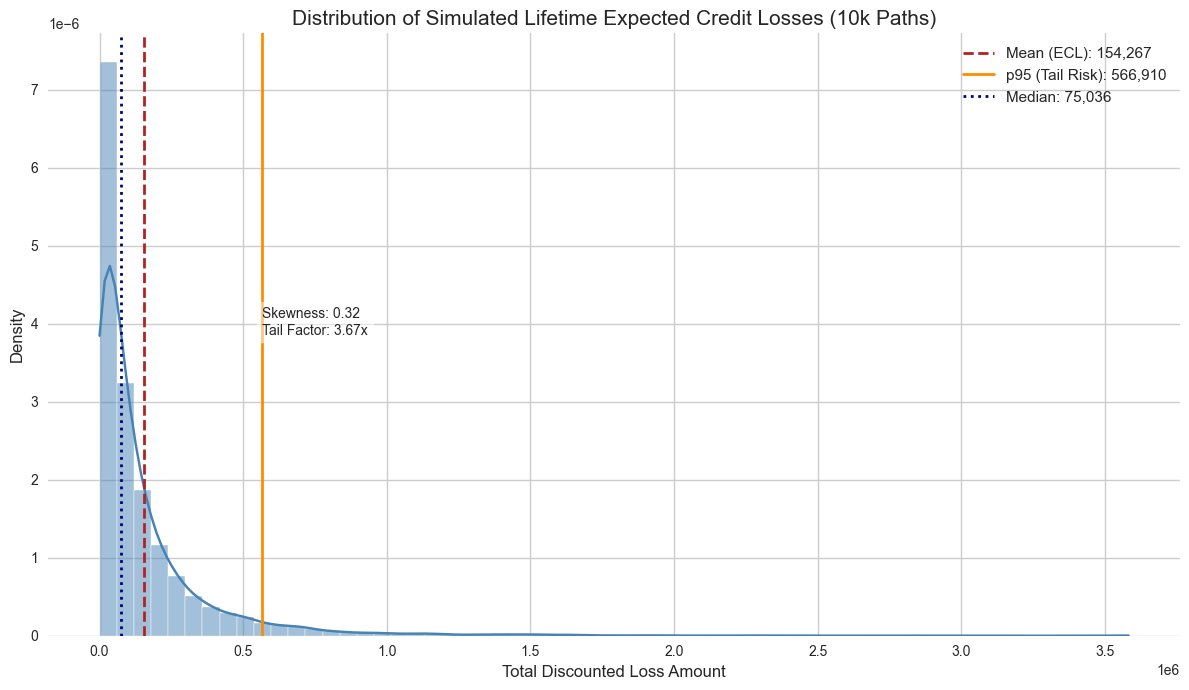

In [1770]:
lifetimeECL_cal.plot_ecl_distribution(dist)

In [1824]:
# ECL calculation
# LGD_long: 10000 simulation per year, column : horizon 1-5, column: LGD, column: index 0-9999, dataframe
# Matrix_Powering_PD: 3500 results per year, column: horizon 1-5, column: Marginal_PD, column: Id 0-3499, dataframe
# EAD:EAD_result_bb, EAD_result_b,EAD_result_c, 5000*5, array
# weights={'BB':0.403834, 'B':0.463355, 'CCC/C':0.132811}  
# no explicit weights in final ECL calculations. weights have baked into rating_sampling probabilities

class lifetimeECL_calculation:

    def __init__(self, LGD_df, PD_df, EAD_bb, EAD_b, EAD_c, discounted_rate = 0.05, sim_size = 10000, spearman_corr = -0.3143, weights = None, seed = 42):
        self.discounted_rate = discounted_rate
        self.sim_size = sim_size
        self.rng = np.random.default_rng(seed)
        self.LGD_df = LGD_df.copy()
        self.PD_df = PD_df.copy()
        self.EAD_bb = EAD_bb.copy()
        self.EAD_b = EAD_b.copy()
        self.EAD_c = EAD_c.copy()
        self.spearman_corr = spearman_corr
        self.weights = weights

    def _resample_PD_LGD_paired(self):
        PD_data = self.PD_df[['Id', 'Horizon', 'Marginal_PD']].copy()
        PD_wide = PD_data.pivot(
            index = 'Id',
            columns = 'Horizon',
            values = 'Marginal_PD'
        )
        PD_wide = PD_wide.sort_index(axis = 1)
        PD_array = PD_wide.values

        PD_index = self.rng.choice(len(PD_array), self.sim_size, replace=True) 
        #1-dimensional arrays: (sim_size,)
        PD_resample = PD_array[PD_index]
       
        LGD_data = self.LGD_df
        LGD_wide = LGD_data.pivot(
            index = 'index',
            columns = 'horizon',
            values = 'LGD'
        )
        LGD_wide = LGD_wide.sort_index(axis = 1)
        LGD_array = LGD_wide.values

        PD_avg = PD_resample.mean(axis=1) 
        LGD_avg = LGD_array.mean(axis=1)                               
    
        pearson_corr = 2 * np.sin(np.pi * self.spearman_corr / 6)
    
     
        cov_matrix = [[1.0, pearson_corr], [pearson_corr, 1.0]]
        correlated_normals = self.rng.multivariate_normal(
                mean=[0, 0], 
                cov=cov_matrix, 
                size= self.sim_size
        )
        #(Z_PD, Z_LGD) ~ N (0, correlation matrix), Z_PD ~ N(0,1), Z_LGD ~ N(0,1)
     
        U_PD = norm.cdf(correlated_normals[:, 0])
        U_LGD = norm.cdf(correlated_normals[:, 1])

        PD_resampled_path = np.zeros((self.sim_size, 5))
        LGD_resampled_path = np.zeros((self.sim_size, 5))
    
        PD_sorted_idx = np.argsort(PD_avg)
        LGD_sorted_idx = np.argsort(LGD_avg)

        PD_map_idx = (U_PD * (len(PD_sorted_idx) - 1)).astype(int)
        LGD_map_idx = (U_LGD * (len(LGD_sorted_idx) - 1)).astype(int)
    
     
        PD_resampled_path = PD_resample[PD_sorted_idx[PD_map_idx]]
        LGD_resampled_path = LGD_array[LGD_sorted_idx[LGD_map_idx]]
    
        return PD_resampled_path, LGD_resampled_path

    def _resample_EAD(self):
          
        EAD_array = {
             'BB': self.EAD_bb,
             'B': self.EAD_b,
             'CCC/C': self.EAD_c
         }   

        Grades = list(self.weights.keys())  
        weight_rating = list(self.weights.values())

        rating_sampling = self.rng.choice(
             Grades,
             size = self.sim_size,
             p = weight_rating,
             replace = True
        )

        EAD_resampled = np.zeros((self.sim_size, 5))

        for grade in Grades:
            mask = (rating_sampling == grade)
            count = mask.sum()

            if count > 0:
                rating_array = EAD_array[grade]

                path_index = self.rng.choice(
                    len(rating_array), 
                    size = count, 
                    replace = True
                    )
                
                EAD_resampled[mask] = rating_array[path_index]
                # mask: 1D array of sim_size elements. each element is True or False.
                # object type: numpy.ndarray; data type(dtype): bool

        return EAD_resampled
    
    def _ECL_stat(self):

        PD_resampled_path, LGD_resampled_path =  self._resample_PD_LGD_paired()

        EAD_resampled = self._resample_EAD()

        ECL_per_horizon = PD_resampled_path * LGD_resampled_path * EAD_resampled

        discount_factor = 1 / ((1 + self.discounted_rate) ** np.arange(1, 6))
        lifetime_ECL = (ECL_per_horizon * discount_factor).sum(axis = 1)

        stats = {
            'mean': np.mean(lifetime_ECL),
            'std': np.std(lifetime_ECL),
            'median': np.median(lifetime_ECL),
            'CI_90': (np.percentile(lifetime_ECL, 5), np.percentile(lifetime_ECL, 95)),
            'CI_95': (np.percentile(lifetime_ECL, 2.5), np.percentile(lifetime_ECL, 97.5))
            }
          

        return stats, lifetime_ECL

    def plot_ecl_distribution(self, lifetime_ECL_dist):
     
        
    
        mean = np.mean(lifetime_ECL_dist)
        p95 = np.percentile(lifetime_ECL_dist, 95)
        median = np.median(lifetime_ECL_dist)
        p5 = np.percentile(lifetime_ECL_dist, 5)

        plt.figure(figsize=(12, 7))
        sns.set_style("whitegrid")

    
        sns.histplot(lifetime_ECL_dist, bins=60, kde=True, color='steelblue', stat="density")

   
        plt.axvline(mean, color='firebrick', linestyle='--', linewidth=2, label=f'Mean (ECL): {mean:,.0f}')
        plt.axvline(p95, color='darkorange', linestyle='-', linewidth=2, label=f'p95 (Tail Risk): {p95:,.0f}')
        plt.axvline(median, color='navy', linestyle=':', linewidth=2, label=f'Median: {median:,.0f}')
        plt.axvline(p5, color='seagreen', linestyle='-.', linewidth=2, label=f'p5 (5th percentile): {p5:,.0f}')

        #plt.axvspan(p5, p95, alpha=0.2, color='slategray', label='90% Confidence Interval')
        
   
        plt.title('Distribution of Simulated Lifetime Expected Credit Losses (10k Paths)', fontsize=15)
        plt.xlabel('Discounted Lifetime ECL', fontsize=12)
        plt.ylabel('Density', fontsize=12)
        plt.legend(fontsize=11)
    
        
        skewness = (mean - median) / np.std(lifetime_ECL_dist)
        tail_factor = p95 / mean  
        
        stats_text = (f"Mean: ${mean:,.0f}\n"
                     f"Std: ${np.std(lifetime_ECL_dist):,.0f}\n"
                     f"Skewness: {skewness:.2f}\n"
                     f"Tail factor: {tail_factor:.2f}x\n"
                     f"90% CI: [${p5:,.0f}, ${p95:,.0f}]")
        
        plt.text(0.02, 0.98, stats_text, transform=plt.gca().transAxes,
                fontsize=10, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.6))
        plt.tight_layout()
        plt.show()
                






    
   

In [1826]:
lifetimeECL_cal = lifetimeECL_calculation(
    discounted_rate = 0.05,
    sim_size = 10000, 
    LGD_df = LGD_long, 
    PD_df = Matrix_Powering_PD, 
    EAD_bb = EAD_result_bb, 
    EAD_b = EAD_result_b, 
    EAD_c = EAD_result_c, 
    spearman_corr = -0.3143, 
    weights = {'BB':0.403834, 'B':0.463355, 'CCC/C':0.132811},
    seed = 42
)

In [1828]:
stats, dist = lifetimeECL_cal._ECL_stat()

In [1786]:
print(f"Expected Lifetime ECL: {stats['mean']:,.4f}")
print(f"Std of Lifetime ECL: {stats['std']:,.4f}")

print(f"90% Confidence Interval: [{stats['CI_90'][0]:,.2f}, "
      f"{stats['CI_90'][1]:,.2f}]")
print(f"95% Confidence Interval: [{stats['CI_95'][0]:,.2f}, "
      f"{stats['CI_95'][1]:,.2f}]")

Expected Lifetime ECL: 154,267.3279
Std of Lifetime ECL: 246,003.5594
90% Confidence Interval: [309.78, 566,909.79]
95% Confidence Interval: [0.00, 780,644.22]


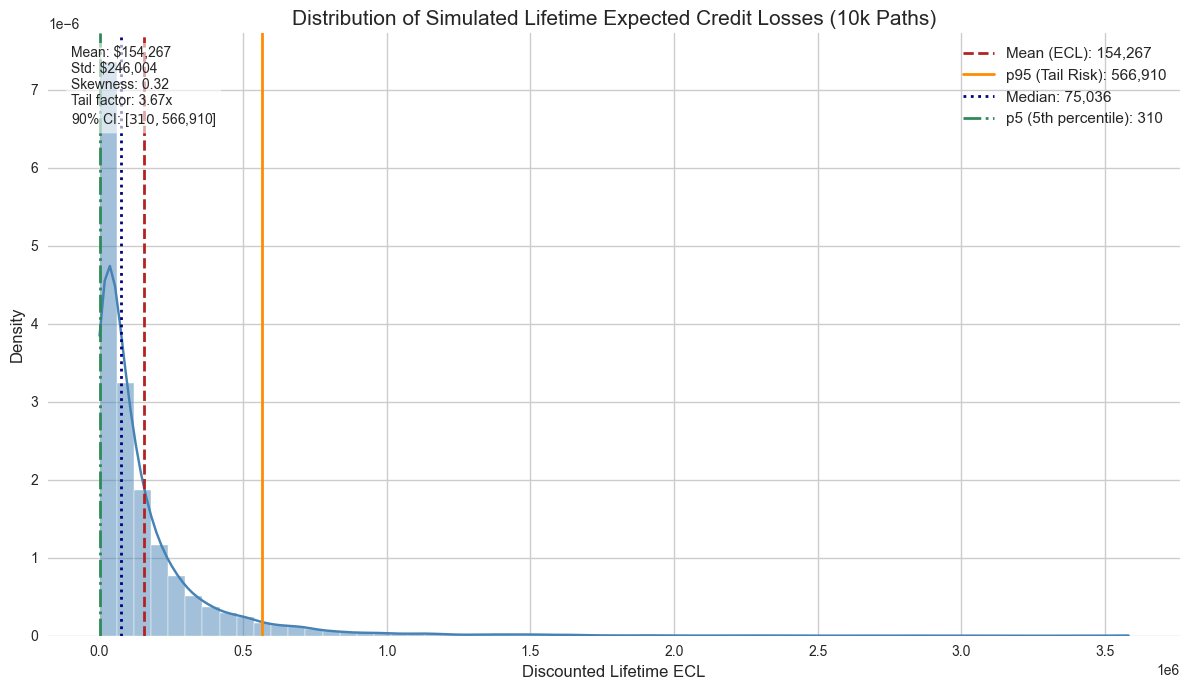

In [1830]:
lifetimeECL_cal.plot_ecl_distribution(dist)